# Classical Brain Tumour Classification Models

This notebook implements and evaluates:

- HOG and GLCM features with Support Vector Machine;
- HOG and GLCM features with Random Forest.

Five-fold stratified cross-validation will be performed using the fixed fold assignments created from the Training partition.

In [3]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\kwsta\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import (
    hog,
    graycomatrix,
    graycoprops,
)


# ============================================================
# Project paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "processed_data_cropped"


REPEATED_CV_DIR = (
    PROJECT_ROOT
    / "repeated_cv"
)

SPLITS_DIR = (
    REPEATED_CV_DIR
    / "splits"
)

FEATURES_DIR = (
    REPEATED_CV_DIR
    / "features"
)

CLASSICAL_SVM_DIR = (
    REPEATED_CV_DIR
    / "classical_svm"
)

CLASSICAL_RF_DIR = (
    REPEATED_CV_DIR
    / "classical_rf"
)

SUMMARIES_DIR = (
    REPEATED_CV_DIR
    / "summaries"
)

LOGS_DIR = (
    REPEATED_CV_DIR
    / "logs"
)


for directory in (
    REPEATED_CV_DIR,
    SPLITS_DIR,
    FEATURES_DIR,
    CLASSICAL_SVM_DIR,
    CLASSICAL_RF_DIR,
    SUMMARIES_DIR,
    LOGS_DIR,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "Processed dataset exists:",
    DATA_DIR.exists(),
)

print(
    "Repeated CV directory:",
    REPEATED_CV_DIR,
)

assert DATA_DIR.exists(), (
    "Processed dataset was not found: "
    f"{DATA_DIR}"
)

print("\nPath setup PASSED.")

Project root: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification
Processed dataset exists: True
Repeated CV directory: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv

Path setup PASSED.


In [32]:
# ============================================================
# Step 3: Create 10 repeated stratified five-fold assignments
# ============================================================

from sklearn.model_selection import StratifiedKFold


# ------------------------------------------------------------
# Existing file used ONLY to obtain:
#   - relative_path
#   - class
#
# The old fold assignments are NOT reused.
# ------------------------------------------------------------

SOURCE_FOLDS_FILE = (
    PROJECT_ROOT
    / "splits"
    / "five_fold_cross_validation.csv"
)

REPEATED_FOLDS_FILE = (
    SPLITS_DIR
    / "repeated_stratified_5fold_assignments.csv"
)


# ------------------------------------------------------------
# Reproducible split configuration
# ------------------------------------------------------------

NUMBER_OF_REPEATS = 10
NUMBER_OF_OUTER_FOLDS = 5

BASE_SPLIT_SEED = 202600

SPLIT_SEEDS = {
    repeat_number: BASE_SPLIT_SEED + repeat_number
    for repeat_number in range(
        1,
        NUMBER_OF_REPEATS + 1,
    )
}


# ------------------------------------------------------------
# Load the original Training manifest
# ------------------------------------------------------------

source_df = pd.read_csv(
    SOURCE_FOLDS_FILE
)

required_columns = {
    "relative_path",
    "class",
}

missing_columns = (
    required_columns
    - set(source_df.columns)
)

assert not missing_columns, (
    "The original fold file is missing columns: "
    f"{missing_columns}"
)


# Keep only the information needed for new splitting.
training_df = (
    source_df[
        [
            "relative_path",
            "class",
        ]
    ]
    .copy()
    .sort_values(
        "relative_path"
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Basic Training-data validation
# ------------------------------------------------------------

assert len(training_df) == 5600, (
    "Expected 5,600 Training images, "
    f"but found {len(training_df)}."
)

assert (
    training_df["relative_path"]
    .nunique()
    == 5600
), "Duplicate Training image paths detected."

assert training_df[
    "relative_path"
].str.startswith(
    "Training/"
).all(), (
    "A non-Training image was found in the split source."
)


expected_class_counts = {
    "glioma": 1400,
    "meningioma": 1400,
    "notumor": 1400,
    "pituitary": 1400,
}

actual_class_counts = (
    training_df["class"]
    .value_counts()
    .to_dict()
)

assert actual_class_counts == expected_class_counts, (
    "Unexpected Training class counts:\n"
    f"{actual_class_counts}"
)


# ------------------------------------------------------------
# Numeric label mapping
# ------------------------------------------------------------

CLASS_TO_LABEL = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3,
}

training_df["label"] = (
    training_df["class"]
    .map(CLASS_TO_LABEL)
)

assert (
    training_df["label"]
    .notna()
    .all()
), "A class could not be mapped to a numeric label."


# ------------------------------------------------------------
# Generate the 10 repeated five-fold assignments
# ------------------------------------------------------------

repeated_assignment_frames = []

for repeat_number in range(
    1,
    NUMBER_OF_REPEATS + 1,
):

    split_seed = (
        SPLIT_SEEDS[
            repeat_number
        ]
    )

    outer_cv = StratifiedKFold(
        n_splits=NUMBER_OF_OUTER_FOLDS,
        shuffle=True,
        random_state=split_seed,
    )

    repeat_df = (
        training_df.copy()
    )

    repeat_df["repeat"] = (
        repeat_number
    )

    repeat_df["fold"] = 0

    repeat_df["split_seed"] = (
        split_seed
    )

    for fold_number, (
        _,
        validation_indices,
    ) in enumerate(
        outer_cv.split(
            training_df[
                "relative_path"
            ],
            training_df[
                "label"
            ],
        ),
        start=1,
    ):

        repeat_df.loc[
            validation_indices,
            "fold",
        ] = fold_number

    repeated_assignment_frames.append(
        repeat_df
    )


repeated_folds_df = pd.concat(
    repeated_assignment_frames,
    ignore_index=True,
)


# ------------------------------------------------------------
# Validate the complete repeated-CV structure
# ------------------------------------------------------------

assert len(repeated_folds_df) == 56000, (
    "Expected 56,000 assignment rows "
    "(5,600 images × 10 repeats)."
)

assert (
    repeated_folds_df["fold"]
    .between(1, 5)
    .all()
), "Invalid fold number detected."


# Every image must appear exactly once per repeat.
rows_per_repeat = (
    repeated_folds_df
    .groupby("repeat")
    .size()
)

assert (
    rows_per_repeat == 5600
).all(), (
    "At least one repeat does not "
    "contain exactly 5,600 images."
)


# Every fold must contain 1,120 images.
fold_sizes = (
    repeated_folds_df
    .groupby(
        [
            "repeat",
            "fold",
        ]
    )
    .size()
)

assert (
    fold_sizes == 1120
).all(), (
    "At least one outer validation fold "
    "does not contain exactly 1,120 images."
)


# Every fold must contain 280 images from each class.
fold_class_counts = (
    repeated_folds_df
    .groupby(
        [
            "repeat",
            "fold",
            "class",
        ]
    )
    .size()
)

assert (
    fold_class_counts == 280
).all(), (
    "At least one fold does not contain "
    "exactly 280 images from every class."
)


# ------------------------------------------------------------
# Save the master assignment file
# ------------------------------------------------------------

repeated_folds_df.to_csv(
    REPEATED_FOLDS_FILE,
    index=False,
)


print(
    "Repeated-CV assignment file:"
)

print(
    REPEATED_FOLDS_FILE
)

print(
    "\nShape:",
    repeated_folds_df.shape,
)

print(
    "\nSplit seeds:"
)

print(
    SPLIT_SEEDS
)

print(
    "\nRows per repeat:"
)

print(
    rows_per_repeat
)

print(
    "\nOuter-fold sizes:"
)

print(
    fold_sizes
)

print(
    "\nClass counts per fold:"
)

print(
    fold_class_counts
)

print(
    "\nStep 3 validation PASSED."
)

Repeated-CV assignment file:
c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\splits\repeated_stratified_5fold_assignments.csv

Shape: (56000, 6)

Split seeds:
{1: 202601, 2: 202602, 3: 202603, 4: 202604, 5: 202605, 6: 202606, 7: 202607, 8: 202608, 9: 202609, 10: 202610}

Rows per repeat:
repeat
1     5600
2     5600
3     5600
4     5600
5     5600
6     5600
7     5600
8     5600
9     5600
10    5600
dtype: int64

Outer-fold sizes:
repeat  fold
1       1       1120
        2       1120
        3       1120
        4       1120
        5       1120
2       1       1120
        2       1120
        3       1120
        4       1120
        5       1120
3       1       1120
        2       1120
        3       1120
        4       1120
        5       1120
4       1       1120
        2       1120
        3       1120
        4       1120
        5       1120
5       1       1120
        2       1120
        3       1120
        4       112

In [5]:
REPEATED_FOLDS_FILE = (
    PROJECT_ROOT
    / "repeated_cv"
    / "splits"
    / "repeated_stratified_5fold_assignments.csv"
)

assert REPEATED_FOLDS_FILE.exists(), (
    f"Repeated split file not found: {REPEATED_FOLDS_FILE}"
)

repeated_folds_df = pd.read_csv(
    REPEATED_FOLDS_FILE
)

assert len(repeated_folds_df) == 56000

print(
    "Loaded existing repeated split file:",
    REPEATED_FOLDS_FILE
)

print(
    "Shape:",
    repeated_folds_df.shape
)

print(
    "\nExisting repeated assignments loaded successfully."
)

Loaded existing repeated split file: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\splits\repeated_stratified_5fold_assignments.csv
Shape: (56000, 6)

Existing repeated assignments loaded successfully.


In [7]:
# ============================================================
# REPEATED-CV CONSTANTS
# ============================================================

NUMBER_OF_REPEATS = 10
NUMBER_OF_OUTER_FOLDS = 5

print(
    "Repeated-CV constants loaded:",
    NUMBER_OF_REPEATS,
    "repeats ×",
    NUMBER_OF_OUTER_FOLDS,
    "folds"
)

Repeated-CV constants loaded: 10 repeats × 5 folds


In [8]:
# ============================================================
# Step 4: Verify that all 10 repeated fold assignments differ
# ============================================================

# Create one fold-assignment vector per repeat.
repeat_fold_vectors = {}

for repeat_number in range(
    1,
    NUMBER_OF_REPEATS + 1,
):

    repeat_assignments = (
        repeated_folds_df[
            repeated_folds_df["repeat"]
            == repeat_number
        ]
        .sort_values("relative_path")
        ["fold"]
        .to_numpy()
    )

    repeat_fold_vectors[
        repeat_number
    ] = repeat_assignments


# ------------------------------------------------------------
# Compare every pair of repeats
# ------------------------------------------------------------

identical_repeat_pairs = []

for repeat_a in range(
    1,
    NUMBER_OF_REPEATS + 1,
):
    for repeat_b in range(
        repeat_a + 1,
        NUMBER_OF_REPEATS + 1,
    ):

        if np.array_equal(
            repeat_fold_vectors[repeat_a],
            repeat_fold_vectors[repeat_b],
        ):
            identical_repeat_pairs.append(
                (
                    repeat_a,
                    repeat_b,
                )
            )


assert not identical_repeat_pairs, (
    "Identical repeated-CV assignments detected: "
    f"{identical_repeat_pairs}"
)


# ------------------------------------------------------------
# Show how many images changed fold between consecutive repeats
# ------------------------------------------------------------

print(
    "Images assigned to a different fold "
    "between consecutive repeats:"
)

for repeat_number in range(
    1,
    NUMBER_OF_REPEATS,
):

    changed_fold_count = np.sum(
        repeat_fold_vectors[
            repeat_number
        ]
        != repeat_fold_vectors[
            repeat_number + 1
        ]
    )

    print(
        f"Repeat {repeat_number} -> "
        f"{repeat_number + 1}: "
        f"{changed_fold_count} / 5600"
    )


print(
    "\nAll 10 repeat assignment patterns are unique."
)

print(
    "Step 4 validation PASSED."
)

Images assigned to a different fold between consecutive repeats:
Repeat 1 -> 2: 4437 / 5600
Repeat 2 -> 3: 4466 / 5600
Repeat 3 -> 4: 4491 / 5600
Repeat 4 -> 5: 4460 / 5600
Repeat 5 -> 6: 4519 / 5600
Repeat 6 -> 7: 4502 / 5600
Repeat 7 -> 8: 4524 / 5600
Repeat 8 -> 9: 4472 / 5600
Repeat 9 -> 10: 4430 / 5600

All 10 repeat assignment patterns are unique.
Step 4 validation PASSED.


In [9]:
# ============================================================
# Step 6: Load and validate cached HOG + GLCM features
# ============================================================

ORIGINAL_FEATURES_FILE = (
    PROJECT_ROOT
    / "extracted_features"
    / "hog_glcm_training_features.npz"
)

assert ORIGINAL_FEATURES_FILE.exists(), (
    "Cached HOG-GLCM feature file was not found:\n"
    f"{ORIGINAL_FEATURES_FILE}"
)


# ------------------------------------------------------------
# Load the existing deterministic feature archive
# ------------------------------------------------------------

feature_archive = np.load(
    ORIGINAL_FEATURES_FILE,
    allow_pickle=True,
)

print(
    "Archive contents:",
    feature_archive.files,
)


cached_features = (
    feature_archive["features"]
)

cached_labels = (
    feature_archive["labels"]
)

cached_relative_paths = (
    feature_archive["relative_paths"]
    .astype(str)
)


# ------------------------------------------------------------
# Basic archive validation
# ------------------------------------------------------------

assert cached_features.shape == (
    5600,
    6102,
), (
    "Unexpected feature matrix shape: "
    f"{cached_features.shape}"
)

assert cached_features.dtype == np.float32, (
    "Expected float32 features, but found "
    f"{cached_features.dtype}"
)

assert len(cached_labels) == 5600

assert len(cached_relative_paths) == 5600

assert (
    len(np.unique(cached_relative_paths))
    == 5600
), "Duplicate paths found in cached features."

assert np.isfinite(
    cached_features
).all(), (
    "Non-finite values found in cached features."
)


# ------------------------------------------------------------
# Confirm that the cached images exactly match
# the 5,600 Training images used for repeated CV
# ------------------------------------------------------------

cached_path_set = set(
    cached_relative_paths.tolist()
)

repeated_cv_path_set = set(
    training_df["relative_path"]
    .astype(str)
    .tolist()
)

assert (
    cached_path_set
    == repeated_cv_path_set
), (
    "The cached feature archive and repeated-CV "
    "Training manifest do not contain the same images."
)


# ------------------------------------------------------------
# Align feature rows to the canonical Training manifest order
# ------------------------------------------------------------

path_to_feature_index = {
    path: index
    for index, path
    in enumerate(
        cached_relative_paths
    )
}

ordered_feature_indices = np.array(
    [
        path_to_feature_index[path]
        for path in training_df[
            "relative_path"
        ].astype(str)
    ],
    dtype=np.int64,
)

all_features = (
    cached_features[
        ordered_feature_indices
    ]
)

all_labels = (
    cached_labels[
        ordered_feature_indices
    ].astype(str)
)

all_relative_paths = (
    cached_relative_paths[
        ordered_feature_indices
    ]
)


# ------------------------------------------------------------
# Verify labels after path-based alignment
# ------------------------------------------------------------

expected_labels = (
    training_df["class"]
    .astype(str)
    .to_numpy()
)

assert np.array_equal(
    all_labels,
    expected_labels,
), (
    "Cached labels do not match the Training manifest "
    "after path alignment."
)

assert np.array_equal(
    all_relative_paths,
    training_df["relative_path"]
    .astype(str)
    .to_numpy(),
), (
    "Feature rows are not aligned with the canonical "
    "Training manifest."
)


print(
    "\nFeature matrix:",
    all_features.shape,
)

print(
    "Feature dtype:",
    all_features.dtype,
)

print(
    "Labels:",
    all_labels.shape,
)

print(
    "Unique image paths:",
    len(
        np.unique(
            all_relative_paths
        )
    ),
)

print(
    "All values finite:",
    np.isfinite(
        all_features
    ).all(),
)

print(
    "\nOld cached fold assignments are NOT being used."
)

print(
    "Step 6 validation PASSED."
)

Archive contents: ['features', 'labels', 'folds', 'relative_paths']


NameError: name 'training_df' is not defined

In [15]:
folds_df = pd.read_csv(FOLDS_FILE)

print("Fold file shape:", folds_df.shape)
print("Number of fold assignments", len(folds_df)) 
print("Fold file columns:", folds_df.columns)
print("Fold file head:\n", folds_df.head())


NameError: name 'FOLDS_FILE' is not defined

## Cross-validation fold assignments

The fold-assignment file contains 5,600 rows and three columns. Each row represents one image from the original Training partition.

- `relative_path` records the image location relative to the processed dataset folder.
- `class` records the correct class label: glioma, meningioma, pituitary or no tumour.
- `fold` identifies which of the five folds will be used as the validation fold for that image.

For example, an image assigned to fold 1 will be used for validation during the first cross-validation iteration. Images assigned to folds 2–5 will be used for training during that iteration. The process is repeated so that every image is used for validation exactly once and for training in the other four iterations.

In [16]:
# Verifying that class balance is maintained across folds

# Creating a frequency table to check the distribution of classes across folds
fold_distribution = pd.crosstab(folds_df['fold'], folds_df['class'])

fold_distribution["total"] = fold_distribution.sum(axis=1)
print("Fold distribution:\n", fold_distribution)

NameError: name 'folds_df' is not defined

In [17]:
# Check if all image paths exist

# Creating a new column in the DataFrame that contains the full image path by combining the DATA_DIR with the relative path from the CSV
folds_df["image_path"] = folds_df["relative_path"].apply(
    lambda relative_path: DATA_DIR / relative_path
)

# Checking if the image paths exist and collecting the missing ones
missing_paths = [
    image_path
    for image_path in folds_df["image_path"]
    if not image_path.exists()
]

print("Images checked:", len(folds_df))
print("Missing images:", len(missing_paths))
print("Fold file head:\n", folds_df.head())

NameError: name 'folds_df' is not defined

In [ ]:
# Loading a sample image to verify that the paths are correct and the images can be read

# Selecting a sample image path from the DataFrame
sample_path = folds_df.loc[0, "image_path"]

# Loading the sample image using OpenCV in grayscale mode
sample_image = cv2.imread(
    str(sample_path),
    cv2.IMREAD_GRAYSCALE
)

print("Sample path:", sample_path)
print("Image loaded:", sample_image is not None)
print("Image shape:", sample_image.shape)
print("Data type:", sample_image.dtype)
print("Minimum pixel value:", sample_image.min())
print("Maximum pixel value:", sample_image.max())

plt.imshow(sample_image, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
# Computing HOG features for the sample image
sample_hog_features = hog(
    sample_image,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    transform_sqrt=True,
    feature_vector=True
)

print("HOG feature shape:", sample_hog_features.shape)
print("Number of HOG features:", len(sample_hog_features))
print("Feature data type:", sample_hog_features.dtype)

HOG feature shape: (6084,)
Number of HOG features: 6084
Feature data type: float64


In [ ]:
# Testing GLCM feature extraction for the sample image

GLCM_LEVELS = 32

# Reducing the number of gray levels in the sample image to GLCM_LEVELS
sample_quantized_image = (sample_image / (256 / GLCM_LEVELS)).astype(np.uint8)

# Computing GLCM for the sample quantized image
sample_glcm = graycomatrix(
    sample_quantized_image,
    distances=[1, 2, 4],
    angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
    levels=GLCM_LEVELS,
    symmetric=True,
    normed=True
)

glcm_properties = [
    "contrast",
    "dissimilarity",
    "homogeneity",
    "energy",
    "correlation",
    "ASM"       
]

sample_glcm_features = []

# Computing GLCM properties for the sample image
for property_name in glcm_properties:
    property_values = graycoprops(sample_glcm, property_name)

    # Calculating the mean of the property values across angles for each distance
    mean_property_value = property_values.mean(axis=1)  # Mean across angles for each distance
    sample_glcm_features.extend(mean_property_value)
    
sample_glcm_features = np.array(sample_glcm_features)

# Printing the quantized pixel range
print("Quantized pixel range:",
    sample_quantized_image.min(),
    "to",
    sample_quantized_image.max())

# Printing the shape of the GLCM features
print("GLCM feature shape:",
    sample_glcm_features.shape)

Quantized pixel range: 0 to 30
GLCM feature shape: (18,)


In [27]:
# Combining HOG and GLCM features for the sample image

sample_combined_features = np.concatenate((sample_hog_features, sample_glcm_features))

print("HOG feature shape:", sample_hog_features.shape)
print("GLCM feature shape:", sample_glcm_features.shape)
print("Combined feature shape:", sample_combined_features.shape)

HOG feature shape: (6084,)
GLCM feature shape: (18,)
Combined feature shape: (6102,)


In [4]:
# Creating reusable functions for feature extraction

HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

GLCM_LEVELS = 32
GLCM_DISTANCES = [1, 2, 4]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]

GLCM_PROPERTIES = [
    "contrast",
    "dissimilarity",
    "homogeneity",
    "energy",
    "correlation",
    "ASM"
]

def extract_hog_features(image):
    """
    Extract HOG features from a grayscale image.

    Parameters:
    - image: Grayscale image (numpy array)

    Returns:
    - hog_features: 1D numpy array of HOG features
    """
    hog_features = hog(
        image,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True
    )
    
    return hog_features.astype(np.float32)

def extract_glcm_features(image):
    """
    Extract GLCM features from a grayscale image.

    Parameters:
    - image: Grayscale image (numpy array)

    Returns:
    - glcm_features: 1D numpy array of GLCM features
    """
    # Reducing the number of gray levels in the image to GLCM_LEVELS
    quantized_image = (image / (256 / GLCM_LEVELS)).astype(np.uint8)

    # Computing GLCM for the quantized image
    glcm = graycomatrix(
        quantized_image,
        distances=GLCM_DISTANCES,
        angles=GLCM_ANGLES,
        levels=GLCM_LEVELS,
        symmetric=True,
        normed=True
    )

    glcm_features = []

    # Computing GLCM properties for the image
    for property_name in GLCM_PROPERTIES:
        property_values = graycoprops(glcm, property_name)

        # Calculating the mean of the property values across angles for each distance
        mean_property_value = property_values.mean(axis=1)  # Mean across angles for each distance
        glcm_features.extend(mean_property_value)
    
    return np.array(glcm_features, dtype=np.float32)

def extract_combined_features(image):
    """
    Extract combined HOG and GLCM features from a grayscale image.

    Parameters:
    - image: Grayscale image (numpy array)

    Returns:
    - combined_features: 1D numpy array of combined HOG and GLCM features
    """
    hog_features = extract_hog_features(image)
    glcm_features = extract_glcm_features(image)
    
    combined_features = np.concatenate((hog_features, glcm_features))
    
    return combined_features

In [33]:
# Testing the reusable feature extraction functions on the sample image

test_hog_features = extract_hog_features(sample_image)
test_glcm_features = extract_glcm_features(sample_image)
test_combined_features = extract_combined_features(sample_image)

print("HOG shape:", test_hog_features.shape)
print("GLCM shape:", test_glcm_features.shape)
print("Combined shape:", test_combined_features.shape)

print("Combined data type:", test_combined_features.dtype)
print("All values finite:", np.isfinite(test_combined_features).all())

HOG shape: (6084,)
GLCM shape: (18,)
Combined shape: (6102,)
Combined data type: float32
All values finite: True


In [ ]:
# Extracting features for all images in the dataset

import time

number_of_images = len(folds_df)
number_of_features = len(extract_combined_features(sample_image))

all_features = np.empty((number_of_images, number_of_features), dtype=np.float32)

all_labels = folds_df["class"].to_numpy()
all_folds = folds_df["fold"].to_numpy()

start_time = time.perf_counter()

for position, (_, row) in enumerate(folds_df.iterrows()):
    image_path = row["image_path"]
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        raise ValueError(f"Image at {image_path} could not be loaded.")
    
    features = extract_combined_features(image)
    all_features[position] = extract_combined_features(image)
    
    if (position + 1) % 250 == 0:
        elapsed_time = time.perf_counter() - start_time
        print(f"Processed {position + 1}/{number_of_images} images in {elapsed_time:.2f} seconds.")


print("\nFeature extraction complete.")
print("Feature matrix shape:", all_features.shape)
print("Labels shape:", all_labels.shape)
print("Folds shape:", all_folds.shape)
print("Feature data type:", all_features.dtype)
print("All values finite:", np.isfinite(all_features).all())
print("Total time:", round(elapsed_time / 60, 2), "minutes")






In [37]:
# Saving the extracted features, labels, and folds to disk for later use

FEATURES_DIR = PROJECT_ROOT / "extracted_features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

TRAINING_FEATURES_FILE = (
    FEATURES_DIR
    / "hog_glcm_training_features.npz"
)

np.savez_compressed(
    TRAINING_FEATURES_FILE,
    features=all_features,
    labels=all_labels,
    folds=all_folds,
    relative_paths=folds_df["relative_path"].to_numpy()
)

print("Saved feature file:", TRAINING_FEATURES_FILE)
print("File exists:", TRAINING_FEATURES_FILE.exists())
print(
    "File size:",
    round(TRAINING_FEATURES_FILE.stat().st_size / (1024 ** 2), 2),
    "MB"
)

Saved feature file: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\extracted_features\hog_glcm_training_features.npz
File exists: True
File size: 105.39 MB


In [ ]:
# Creating a scikit-learn cross-validation split using the folds information

from sklearn.model_selection import PredefinedSplit

# The CSV uses fold numbers 1-5
# PredefinedSplit expects fold numbers to be 0-indexed, so we subtract 1 from the fold numbers in the DataFrame

predefined_cv_split = PredefinedSplit(test_fold = all_folds.astype(int) - 1)

print("Number of cross-validation splits:", predefined_cv_split.get_n_splits())

for fold_number, (train_indices, validation_indices) in enumerate(predefined_cv_split.split(), start = 1):
    print(f"Fold {fold_number}:")
    print(f"  Training indices: {len(train_indices)} samples")
    print(f"  Validation indices: {len(validation_indices)} samples")

In [40]:
# Creating an SVM pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_pipeline = Pipeline(
    steps=[
        ("feature_scaler", StandardScaler()),
        ("svm_classifier", SVC(kernel="rbf", C=1.0, gamma="scale"))
    ]
)
print(svm_pipeline)

Pipeline(steps=[('feature_scaler', StandardScaler()),
                ('svm_classifier', SVC())])


In [42]:
# Testing the SVM on fold 1

import time
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import clone

# Obtaining the first predefined cross-validation split (fold 1)
train_indices, validation_indices = next(predefined_cv_split.split())

X_train, X_val = all_features[train_indices], all_features[validation_indices]
y_train, y_val = all_labels[train_indices], all_labels[validation_indices]

# Creating an independent copy of the pipeline
fold_1_svm = clone(svm_pipeline)

start_time = time.perf_counter()

fold_1_svm.fit(X_train, y_train)

training_time = time.perf_counter() - start_time

validation_predictions = fold_1_svm.predict(X_val)

validation_accuracy = accuracy_score(y_val, validation_predictions)

validation_macro_f1 =  f1_score(y_val, validation_predictions, average="macro")


print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)
print("Training time:", round(training_time / 60, 2), "minutes")
print("Validation accuracy:", round(validation_accuracy, 4))
print("Validation macro F1-score:", round(validation_macro_f1, 4))


Training samples: (4480, 6102)
Validation samples: (1120, 6102)
Training time: 0.74 minutes
Validation accuracy: 0.8973
Validation macro F1-score: 0.8975


In [ ]:
# Evaluating the SVM using five-fold cross-validation

svm_fold_results = []

cross_validation_start_time = time.perf_counter()

for fold_number, (train_indices, validation_indices) in enumerate(
    predefined_cv_split.split(),
    start=1
):
    # Separating the training and validation data for the current fold
    X_train, X_val = (
        all_features[train_indices],
        all_features[validation_indices]
    )

    y_train, y_val = (
        all_labels[train_indices],
        all_labels[validation_indices]
    )

    # Creating an independent copy of the SVM pipeline
    fold_svm = clone(svm_pipeline)

    fold_start_time = time.perf_counter()

    # Training the SVM on the current training folds
    fold_svm.fit(X_train, y_train)

    fold_training_time = (
        time.perf_counter() - fold_start_time
    )

    # Making predictions on the current validation fold
    validation_predictions = fold_svm.predict(X_val)

    # Calculating the evaluation metrics
    validation_accuracy = accuracy_score(
        y_val,
        validation_predictions
    )

    validation_macro_f1 = f1_score(
        y_val,
        validation_predictions,
        average="macro"
    )

    # Saving the results for the current fold
    svm_fold_results.append(
        {
            "fold": fold_number,
            "accuracy": validation_accuracy,
            "macro_f1": validation_macro_f1,
            "training_time_minutes": fold_training_time / 60
        }
    )

    print(f"Fold {fold_number}:")
    print(
        "  Training time:",
        round(fold_training_time / 60, 2),
        "minutes"
    )
    print(
        "  Validation accuracy:",
        round(validation_accuracy, 4)
    )
    print(
        "  Validation macro F1-score:",
        round(validation_macro_f1, 4)
    )


total_cross_validation_time = (
    time.perf_counter() - cross_validation_start_time
)

# Converting the fold results into a DataFrame
svm_results_df = pd.DataFrame(svm_fold_results)

print("\nFive-fold cross-validation results:")
print(svm_results_df)

print(
    "\nMean validation accuracy:",
    round(svm_results_df["accuracy"].mean(), 4)
)

print(
    "Accuracy standard deviation:",
    round(svm_results_df["accuracy"].std(), 4)
)

print(
    "Mean validation macro F1-score:",
    round(svm_results_df["macro_f1"].mean(), 4)
)

print(
    "Macro F1-score standard deviation:",
    round(svm_results_df["macro_f1"].std(), 4)
)

print(
    "Total cross-validation time:",
    round(total_cross_validation_time / 60, 2),
    "minutes"
)

In [44]:
# Creating the Random Forest classifier

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators = 300, 
    random_state = 42, 
    n_jobs = -1

)

print(random_forest_model)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)


In [45]:
# Testing the Random Forest on fold 1

# Obtaining the first predefined cross-validation split
train_indices, validation_indices = next(
    predefined_cv_split.split()
)

X_train, X_val = (
    all_features[train_indices],
    all_features[validation_indices]
)

y_train, y_val = (
    all_labels[train_indices],
    all_labels[validation_indices]
)

# Creating an independent copy of the Random Forest model
fold_1_random_forest = clone(random_forest_model)

start_time = time.perf_counter()

# Training the Random Forest
fold_1_random_forest.fit(X_train, y_train)

training_time = time.perf_counter() - start_time

# Making predictions on the validation fold
validation_predictions = fold_1_random_forest.predict(X_val)

# Calculating the evaluation metrics
validation_accuracy = accuracy_score(
    y_val,
    validation_predictions
)

validation_macro_f1 = f1_score(
    y_val,
    validation_predictions,
    average="macro"
)

print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)
print(
    "Training time:",
    round(training_time / 60, 2),
    "minutes"
)
print(
    "Validation accuracy:",
    round(validation_accuracy, 4)
)
print(
    "Validation macro F1-score:",
    round(validation_macro_f1, 4)
)

Training samples: (4480, 6102)
Validation samples: (1120, 6102)
Training time: 0.17 minutes
Validation accuracy: 0.85
Validation macro F1-score: 0.8489


In [46]:
# Evaluating the Random Forest using five-fold cross-validation

random_forest_fold_results = []

cross_validation_start_time = time.perf_counter()

for fold_number, (train_indices, validation_indices) in enumerate(
    predefined_cv_split.split(),
    start=1
):
    # Separating the training and validation data
    X_train, X_val = (
        all_features[train_indices],
        all_features[validation_indices]
    )

    y_train, y_val = (
        all_labels[train_indices],
        all_labels[validation_indices]
    )

    # Creating an independent copy of the Random Forest
    fold_random_forest = clone(random_forest_model)

    fold_start_time = time.perf_counter()

    # Training the Random Forest
    fold_random_forest.fit(X_train, y_train)

    fold_training_time = (
        time.perf_counter() - fold_start_time
    )

    # Making predictions on the validation fold
    validation_predictions = (
        fold_random_forest.predict(X_val)
    )

    # Calculating the evaluation metrics
    validation_accuracy = accuracy_score(
        y_val,
        validation_predictions
    )

    validation_macro_f1 = f1_score(
        y_val,
        validation_predictions,
        average="macro"
    )

    # Saving the results for the current fold
    random_forest_fold_results.append(
        {
            "fold": fold_number,
            "accuracy": validation_accuracy,
            "macro_f1": validation_macro_f1,
            "training_time_minutes": fold_training_time / 60
        }
    )

    print(f"Fold {fold_number}:")
    print(
        "  Training time:",
        round(fold_training_time / 60, 2),
        "minutes"
    )
    print(
        "  Validation accuracy:",
        round(validation_accuracy, 4)
    )
    print(
        "  Validation macro F1-score:",
        round(validation_macro_f1, 4)
    )


total_cross_validation_time = (
    time.perf_counter() - cross_validation_start_time
)

# Converting the fold results into a DataFrame
random_forest_results_df = pd.DataFrame(
    random_forest_fold_results
)

print("\nFive-fold cross-validation results:")
print(random_forest_results_df)

print(
    "\nMean validation accuracy:",
    round(
        random_forest_results_df["accuracy"].mean(),
        4
    )
)

print(
    "Accuracy standard deviation:",
    round(
        random_forest_results_df["accuracy"].std(),
        4
    )
)

print(
    "Mean validation macro F1-score:",
    round(
        random_forest_results_df["macro_f1"].mean(),
        4
    )
)

print(
    "Macro F1-score standard deviation:",
    round(
        random_forest_results_df["macro_f1"].std(),
        4
    )
)

print(
    "Total cross-validation time:",
    round(total_cross_validation_time / 60, 2),
    "minutes"
)

Fold 1:
  Training time: 0.16 minutes
  Validation accuracy: 0.85
  Validation macro F1-score: 0.8489
Fold 2:
  Training time: 0.17 minutes
  Validation accuracy: 0.8393
  Validation macro F1-score: 0.8371
Fold 3:
  Training time: 0.17 minutes
  Validation accuracy: 0.8545
  Validation macro F1-score: 0.8532
Fold 4:
  Training time: 0.17 minutes
  Validation accuracy: 0.8402
  Validation macro F1-score: 0.839
Fold 5:
  Training time: 0.16 minutes
  Validation accuracy: 0.8518
  Validation macro F1-score: 0.8507

Five-fold cross-validation results:
   fold  accuracy  macro_f1  training_time_minutes
0     1  0.850000  0.848858               0.159363
1     2  0.839286  0.837076               0.169043
2     3  0.854464  0.853167               0.166779
3     4  0.840179  0.838954               0.165365
4     5  0.851786  0.850684               0.160632

Mean validation accuracy: 0.8471
Accuracy standard deviation: 0.007
Mean validation macro F1-score: 0.8457
Macro F1-score standard deviatio

## Nested cross-validation for SVM hyperparameter tuning

Nested cross-validation is used to select the SVM hyperparameters while obtaining a less biased estimate of model performance. The existing five predefined folds are used as the outer cross-validation loop. A separate inner cross-validation loop is performed using only the training data from each outer fold.

In [49]:
# Defining the inner cross-validation and SVM parameter grid

from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedKFold
)

svm_parameter_grid = {
    "svm_classifier__C": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0
    ],
    "svm_classifier__gamma": [
        "scale",
        0.00001,
        0.0001,
        0.001,
        0.01
    ]
}

print(
    "Number of SVM parameter combinations:",
    len(list(ParameterGrid(svm_parameter_grid)))
)

print(
    "Inner cross-validation folds:",
    inner_cv_split.get_n_splits()
)

Number of SVM parameter combinations: 25
Inner cross-validation folds: 3


In [7]:
# ============================================================
# Step 8: Nested SVM configuration
# ============================================================

from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedKFold,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# ------------------------------------------------------------
# Deterministic seed construction
# ------------------------------------------------------------

BASE_INNER_CV_SEED = 303000

def get_inner_cv_seed(
    repeat_number,
    fold_number,
):
    """
    Return a deterministic but different inner-CV seed
    for every outer repeat/fold.
    """

    return (
        BASE_INNER_CV_SEED
        + repeat_number * 100
        + fold_number
    )


def make_inner_cv(
    repeat_number,
    fold_number,
):
    """
    Create the 3-fold stratified inner CV used only
    inside the current outer-training set.
    """

    return StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=get_inner_cv_seed(
            repeat_number,
            fold_number,
        ),
    )


# ------------------------------------------------------------
# SVM pipeline
#
# StandardScaler remains INSIDE the pipeline so that scaling
# is fitted separately inside each inner-CV training split.
# ------------------------------------------------------------

svm_pipeline = Pipeline(
    steps=[
        (
            "feature_scaler",
            StandardScaler(),
        ),
        (
            "svm_classifier",
            SVC(
                kernel="rbf",
                probability=False,
            ),
        ),
    ]
)


# ------------------------------------------------------------
# Exact original SVM search space
# ------------------------------------------------------------

svm_parameter_grid = {
    "svm_classifier__C": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
    ],

    "svm_classifier__gamma": [
        "scale",
        0.00001,
        0.0001,
        0.001,
        0.01,
    ],
}


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

number_of_svm_candidates = len(
    list(
        ParameterGrid(
            svm_parameter_grid
        )
    )
)

test_inner_cv = make_inner_cv(
    repeat_number=1,
    fold_number=1,
)


assert number_of_svm_candidates == 25

assert (
    test_inner_cv.get_n_splits()
    == 3
)


print(
    "SVM parameter combinations:",
    number_of_svm_candidates,
)

print(
    "Inner CV folds:",
    test_inner_cv.get_n_splits(),
)

print(
    "Repeat 1 / Fold 1 inner seed:",
    get_inner_cv_seed(
        1,
        1,
    ),
)

print(
    "\nSVM pipeline:"
)

print(
    svm_pipeline
)

print(
    "\nStep 8 validation PASSED."
)

SVM parameter combinations: 25
Inner CV folds: 3
Repeat 1 / Fold 1 inner seed: 303101

SVM pipeline:
Pipeline(steps=[('feature_scaler', StandardScaler()),
                ('svm_classifier', SVC())])

Step 8 validation PASSED.


In [8]:
# ============================================================
# Step 9: Test nested SVM on ONE outer fold only
# Repeat 1, Fold 1
# ============================================================

import time

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)


TEST_REPEAT = 1
TEST_FOLD = 1


# ------------------------------------------------------------
# Get the fold assignments for Repeat 1
# ------------------------------------------------------------

repeat_assignments = (
    repeated_folds_df[
        repeated_folds_df["repeat"]
        == TEST_REPEAT
    ]
    .sort_values("relative_path")
    .reset_index(drop=True)
)


# Verify alignment with the feature matrix
assert np.array_equal(
    repeat_assignments["relative_path"]
    .astype(str)
    .to_numpy(),
    all_relative_paths,
)


# ------------------------------------------------------------
# Build outer training / validation indices
# ------------------------------------------------------------

outer_validation_mask = (
    repeat_assignments["fold"].to_numpy()
    == TEST_FOLD
)

outer_validation_indices = np.flatnonzero(
    outer_validation_mask
)

outer_training_indices = np.flatnonzero(
    ~outer_validation_mask
)


X_outer_train = all_features[
    outer_training_indices
]

X_outer_val = all_features[
    outer_validation_indices
]

y_outer_train = all_labels[
    outer_training_indices
]

y_outer_val = all_labels[
    outer_validation_indices
]


assert X_outer_train.shape == (
    4480,
    6102,
)

assert X_outer_val.shape == (
    1120,
    6102,
)


# ------------------------------------------------------------
# Create the INNER CV for this specific outer fold
# ------------------------------------------------------------

inner_cv = make_inner_cv(
    repeat_number=TEST_REPEAT,
    fold_number=TEST_FOLD,
)


# ------------------------------------------------------------
# Nested hyperparameter search
# ------------------------------------------------------------

svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_parameter_grid,
    scoring="f1_macro",
    cv=inner_cv,
    refit=True,
    n_jobs=2,
    verbose=1,
)


print(
    f"Testing Repeat {TEST_REPEAT}, "
    f"Fold {TEST_FOLD}"
)

print(
    "Outer training samples:",
    len(outer_training_indices),
)

print(
    "Outer validation samples:",
    len(outer_validation_indices),
)

print(
    "Inner CV seed:",
    get_inner_cv_seed(
        TEST_REPEAT,
        TEST_FOLD,
    ),
)


# ------------------------------------------------------------
# Search + automatic refit on all outer-training data
# ------------------------------------------------------------

search_start = time.perf_counter()

svm_search.fit(
    X_outer_train,
    y_outer_train,
)

search_and_refit_seconds = (
    time.perf_counter()
    - search_start
)


# ------------------------------------------------------------
# Outer-fold prediction
# ------------------------------------------------------------

prediction_start = time.perf_counter()

outer_predictions = svm_search.predict(
    X_outer_val
)

prediction_seconds = (
    time.perf_counter()
    - prediction_start
)


# ------------------------------------------------------------
# Outer-fold metrics
# ------------------------------------------------------------

outer_accuracy = accuracy_score(
    y_outer_val,
    outer_predictions,
)

outer_balanced_accuracy = (
    balanced_accuracy_score(
        y_outer_val,
        outer_predictions,
    )
)

outer_macro_precision = precision_score(
    y_outer_val,
    outer_predictions,
    average="macro",
    zero_division=0,
)

outer_macro_recall = recall_score(
    y_outer_val,
    outer_predictions,
    average="macro",
    zero_division=0,
)

outer_macro_f1 = f1_score(
    y_outer_val,
    outer_predictions,
    average="macro",
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(
    "\nBest parameters:"
)

print(
    svm_search.best_params_
)

print(
    "\nBest inner macro F1:",
    round(
        svm_search.best_score_,
        6,
    ),
)

print(
    "\nOuter accuracy:",
    round(
        outer_accuracy,
        6,
    ),
)

print(
    "Outer balanced accuracy:",
    round(
        outer_balanced_accuracy,
        6,
    ),
)

print(
    "Outer macro precision:",
    round(
        outer_macro_precision,
        6,
    ),
)

print(
    "Outer macro recall:",
    round(
        outer_macro_recall,
        6,
    ),
)

print(
    "Outer macro F1:",
    round(
        outer_macro_f1,
        6,
    ),
)

print(
    "\nSearch + refit time:",
    round(
        search_and_refit_seconds / 60,
        2,
    ),
    "minutes",
)

print(
    "GridSearchCV final refit time:",
    round(
        svm_search.refit_time_,
        2,
    ),
    "seconds",
)

print(
    "Prediction time:",
    round(
        prediction_seconds,
        2,
    ),
    "seconds",
)

print(
    "\nStep 9 single-fold test PASSED."
)

Testing Repeat 1, Fold 1
Outer training samples: 4480
Outer validation samples: 1120
Inner CV seed: 303101
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best parameters:
{'svm_classifier__C': 10.0, 'svm_classifier__gamma': 'scale'}

Best inner macro F1: 0.885261

Outer accuracy: 0.919643
Outer balanced accuracy: 0.919643
Outer macro precision: 0.920553
Outer macro recall: 0.919643
Outer macro F1: 0.919742

Search + refit time: 41.92 minutes
GridSearchCV final refit time: 47.89 seconds
Prediction time: 16.74 seconds

Step 9 single-fold test PASSED.


In [9]:
# ============================================================
# Step 10: Save completed SVM Repeat 1 / Fold 1
# ============================================================

import json

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)


# ------------------------------------------------------------
# Atomic-save helpers
# ------------------------------------------------------------

def save_json_atomic(
    data,
    destination,
):
    destination = Path(destination)

    temporary_path = destination.with_name(
        destination.name + ".tmp"
    )

    with temporary_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            data,
            file,
            indent=4,
            default=str,
        )

    temporary_path.replace(
        destination
    )


def save_dataframe_atomic(
    dataframe,
    destination,
    index=False,
):
    destination = Path(destination)

    temporary_path = destination.with_name(
        destination.name + ".tmp"
    )

    dataframe.to_csv(
        temporary_path,
        index=index,
    )

    temporary_path.replace(
        destination
    )


# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

repeat_number = TEST_REPEAT
fold_number = TEST_FOLD

fold_directory = (
    CLASSICAL_SVM_DIR
    / f"repeat_{repeat_number:02d}"
    / f"fold_{fold_number:02d}"
)

fold_directory.mkdir(
    parents=True,
    exist_ok=True,
)


METRICS_PATH = (
    fold_directory
    / "metrics.json"
)

CONFIG_PATH = (
    fold_directory
    / "fold_config.json"
)

PREDICTIONS_PATH = (
    fold_directory
    / "predictions.csv"
)

CONFUSION_MATRIX_PATH = (
    fold_directory
    / "confusion_matrix.csv"
)

CLASSIFICATION_REPORT_PATH = (
    fold_directory
    / "classification_report.csv"
)

SEARCH_RESULTS_PATH = (
    fold_directory
    / "search_results.csv"
)

COMPLETION_PATH = (
    fold_directory
    / "complete.json"
)


# ------------------------------------------------------------
# Fold metadata
# ------------------------------------------------------------

split_seed = int(
    repeat_assignments[
        "split_seed"
    ].iloc[0]
)

inner_cv_seed = (
    get_inner_cv_seed(
        repeat_number,
        fold_number,
    )
)

# SVC is deterministic here because probability=False.
# We still record a systematic model seed for consistency
# across the wider repeated-CV experiment.
model_seed = (
    404000
    + repeat_number * 100
    + fold_number
)


# ------------------------------------------------------------
# Prediction table
# ------------------------------------------------------------

validation_relative_paths = (
    repeat_assignments[
        "relative_path"
    ]
    .iloc[
        outer_validation_indices
    ]
    .astype(str)
    .to_numpy()
)


predictions_df = pd.DataFrame(
    {
        "relative_path":
            validation_relative_paths,

        "true_label":
            y_outer_val,

        "predicted_label":
            outer_predictions,
    }
)

predictions_df["correct"] = (
    predictions_df[
        "true_label"
    ]
    == predictions_df[
        "predicted_label"
    ]
)


assert len(
    predictions_df
) == 1120


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary",
]

fold_confusion_matrix = (
    confusion_matrix(
        y_outer_val,
        outer_predictions,
        labels=CLASS_NAMES,
    )
)

confusion_matrix_df = pd.DataFrame(
    fold_confusion_matrix,
    index=[
        f"actual_{name}"
        for name in CLASS_NAMES
    ],
    columns=[
        f"predicted_{name}"
        for name in CLASS_NAMES
    ],
)


# ------------------------------------------------------------
# Per-class classification report
# ------------------------------------------------------------

classification_report_dict = (
    classification_report(
        y_outer_val,
        outer_predictions,
        labels=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
)

classification_report_df = (
    pd.DataFrame(
        classification_report_dict
    )
    .transpose()
)


# ------------------------------------------------------------
# Full GridSearchCV results
# ------------------------------------------------------------

search_results_df = pd.DataFrame(
    svm_search.cv_results_
)

assert len(
    search_results_df
) == 25


# ------------------------------------------------------------
# Timing
# ------------------------------------------------------------

final_refit_seconds = float(
    svm_search.refit_time_
)

tuning_search_seconds = max(
    0.0,
    float(
        search_and_refit_seconds
        - final_refit_seconds
    ),
)

total_fold_seconds = float(
    search_and_refit_seconds
    + prediction_seconds
)


# ------------------------------------------------------------
# Metrics record
# ------------------------------------------------------------

metrics = {
    "model": "HOG_GLCM_SVM",

    "repeat": int(
        repeat_number
    ),

    "fold": int(
        fold_number
    ),

    "split_seed": int(
        split_seed
    ),

    "inner_cv_seed": int(
        inner_cv_seed
    ),

    "model_seed": int(
        model_seed
    ),

    "model_is_stochastic": False,

    "n_outer_train": 4480,
    "n_outer_validation": 1120,

    "best_parameters":
        svm_search.best_params_,

    "best_inner_macro_f1":
        float(
            svm_search.best_score_
        ),

    "accuracy":
        float(
            outer_accuracy
        ),

    "balanced_accuracy":
        float(
            outer_balanced_accuracy
        ),

    "macro_precision":
        float(
            outer_macro_precision
        ),

    "macro_recall":
        float(
            outer_macro_recall
        ),

    "macro_f1":
        float(
            outer_macro_f1
        ),

    "tuning_search_seconds":
        tuning_search_seconds,

    "final_refit_seconds":
        final_refit_seconds,

    "prediction_seconds":
        float(
            prediction_seconds
        ),

    "total_fold_seconds":
        total_fold_seconds,
}


# ------------------------------------------------------------
# Configuration record
# ------------------------------------------------------------

fold_configuration = {
    "model": "HOG_GLCM_SVM",

    "repeat": int(
        repeat_number
    ),

    "fold": int(
        fold_number
    ),

    "outer_split_seed": int(
        split_seed
    ),

    "inner_cv_seed": int(
        inner_cv_seed
    ),

    "model_seed": int(
        model_seed
    ),

    "feature_count": 6102,

    "hog_feature_count": 6084,
    "glcm_feature_count": 18,

    "outer_training_samples": 4480,
    "outer_validation_samples": 1120,

    "inner_cv_folds": 3,

    "scoring": "f1_macro",

    "number_of_candidates": 25,

    "svm_kernel": "rbf",

    "probability": False,

    "scaler_inside_pipeline": True,

    "parameter_grid":
        svm_parameter_grid,

    "selected_parameters":
        svm_search.best_params_,
}


# ------------------------------------------------------------
# Save all fold outputs
# ------------------------------------------------------------

save_dataframe_atomic(
    predictions_df,
    PREDICTIONS_PATH,
    index=False,
)

save_dataframe_atomic(
    confusion_matrix_df,
    CONFUSION_MATRIX_PATH,
    index=True,
)

save_dataframe_atomic(
    classification_report_df,
    CLASSIFICATION_REPORT_PATH,
    index=True,
)

save_dataframe_atomic(
    search_results_df,
    SEARCH_RESULTS_PATH,
    index=False,
)

save_json_atomic(
    metrics,
    METRICS_PATH,
)

save_json_atomic(
    fold_configuration,
    CONFIG_PATH,
)


# ------------------------------------------------------------
# Verify required files BEFORE writing completion marker
# ------------------------------------------------------------

required_outputs = [
    METRICS_PATH,
    CONFIG_PATH,
    PREDICTIONS_PATH,
    CONFUSION_MATRIX_PATH,
    CLASSIFICATION_REPORT_PATH,
    SEARCH_RESULTS_PATH,
]

missing_outputs = [
    path
    for path in required_outputs
    if not path.exists()
]

assert not missing_outputs, (
    "Required fold outputs are missing: "
    f"{missing_outputs}"
)


# Re-read key outputs to verify they are valid.
saved_predictions = pd.read_csv(
    PREDICTIONS_PATH
)

saved_search_results = pd.read_csv(
    SEARCH_RESULTS_PATH
)

with METRICS_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    saved_metrics = json.load(
        file
    )


assert len(
    saved_predictions
) == 1120

assert len(
    saved_search_results
) == 25

assert (
    saved_metrics["repeat"]
    == 1
)

assert (
    saved_metrics["fold"]
    == 1
)


# ------------------------------------------------------------
# Completion marker MUST be written last
# ------------------------------------------------------------

completion_information = {
    "status": "completed",
    "model": "HOG_GLCM_SVM",
    "repeat": 1,
    "fold": 1,
    "required_outputs_verified": True,
}

save_json_atomic(
    completion_information,
    COMPLETION_PATH,
)


print(
    "Saved Repeat 1 / Fold 1 to:"
)

print(
    fold_directory
)

print(
    "\nFiles:"
)

for path in (
    required_outputs
    + [COMPLETION_PATH]
):
    print(
        " ",
        path.name
    )

print(
    "\nBest parameters:",
    svm_search.best_params_
)

print(
    "Outer macro F1:",
    round(
        outer_macro_f1,
        6,
    )
)

print(
    "\nStep 10 persistence validation PASSED."
)

Saved Repeat 1 / Fold 1 to:
c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\classical_svm\repeat_01\fold_01

Files:
  metrics.json
  fold_config.json
  predictions.csv
  confusion_matrix.csv
  classification_report.csv
  search_results.csv
  complete.json

Best parameters: {'svm_classifier__C': 10.0, 'svm_classifier__gamma': 'scale'}
Outer macro F1: 0.919742

Step 10 persistence validation PASSED.


In [10]:
# ============================================================
# Step 11: Run all repeated nested-CV SVM folds
#
# 10 repeats × 5 outer folds = 50 outer-fold evaluations
#
# Resume behaviour:
#   - completed + valid fold -> skip
#   - incomplete/corrupt fold -> delete and rerun
#   - save after every fold
# ============================================================

import json
import shutil
import time

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

NUMBER_OF_REPEATS = 10
NUMBER_OF_OUTER_FOLDS = 5

BASE_MODEL_SEED = 404000


def get_model_seed(
    repeat_number,
    fold_number,
):
    """
    SVC(probability=False) is deterministic, so this seed is
    recorded for experiment-wide reproducibility bookkeeping.
    """
    return (
        BASE_MODEL_SEED
        + repeat_number * 100
        + fold_number
    )


# ------------------------------------------------------------
# Fold-output validation
# ------------------------------------------------------------

def validate_completed_svm_fold(
    fold_directory,
    expected_repeat,
    expected_fold,
):
    """
    Return True only if a fold has a valid completion marker
    and all required outputs can be read successfully.
    """

    fold_directory = Path(
        fold_directory
    )

    metrics_path = (
        fold_directory
        / "metrics.json"
    )

    config_path = (
        fold_directory
        / "fold_config.json"
    )

    predictions_path = (
        fold_directory
        / "predictions.csv"
    )

    confusion_matrix_path = (
        fold_directory
        / "confusion_matrix.csv"
    )

    classification_report_path = (
        fold_directory
        / "classification_report.csv"
    )

    search_results_path = (
        fold_directory
        / "search_results.csv"
    )

    completion_path = (
        fold_directory
        / "complete.json"
    )

    required_paths = [
        metrics_path,
        config_path,
        predictions_path,
        confusion_matrix_path,
        classification_report_path,
        search_results_path,
        completion_path,
    ]

    if not all(
        path.exists()
        for path in required_paths
    ):
        return False

    try:

        with completion_path.open(
            "r",
            encoding="utf-8",
        ) as file:
            completion = json.load(
                file
            )

        if (
            completion.get("status")
            != "completed"
        ):
            return False

        if (
            int(
                completion.get(
                    "repeat"
                )
            )
            != expected_repeat
        ):
            return False

        if (
            int(
                completion.get(
                    "fold"
                )
            )
            != expected_fold
        ):
            return False

        with metrics_path.open(
            "r",
            encoding="utf-8",
        ) as file:
            metrics = json.load(
                file
            )

        if (
            int(metrics["repeat"])
            != expected_repeat
        ):
            return False

        if (
            int(metrics["fold"])
            != expected_fold
        ):
            return False

        predictions_df = pd.read_csv(
            predictions_path
        )

        if len(
            predictions_df
        ) != 1120:
            return False

        if (
            predictions_df[
                "relative_path"
            ]
            .nunique()
            != 1120
        ):
            return False

        search_results_df = pd.read_csv(
            search_results_path
        )

        if len(
            search_results_df
        ) != 25:
            return False

        confusion_df = pd.read_csv(
            confusion_matrix_path,
            index_col=0,
        )

        if confusion_df.shape != (
            4,
            4,
        ):
            return False

        report_df = pd.read_csv(
            classification_report_path,
            index_col=0,
        )

        if report_df.empty:
            return False

        return True

    except Exception:

        return False


# ------------------------------------------------------------
# Main repeated nested-CV loop
# ------------------------------------------------------------

completed_folds = 0
skipped_folds = 0
rerun_folds = 0


for repeat_number in range(
    1,
    NUMBER_OF_REPEATS + 1,
):

    # --------------------------------------------------------
    # Get assignments for this repeat
    # --------------------------------------------------------

    repeat_assignments = (
        repeated_folds_df[
            repeated_folds_df["repeat"]
            == repeat_number
        ]
        .sort_values(
            "relative_path"
        )
        .reset_index(
            drop=True
        )
    )

    assert len(
        repeat_assignments
    ) == 5600

    assert np.array_equal(
        repeat_assignments[
            "relative_path"
        ]
        .astype(str)
        .to_numpy(),
        all_relative_paths,
    ), (
        f"Path alignment failed "
        f"for repeat {repeat_number}."
    )


    split_seed = int(
        repeat_assignments[
            "split_seed"
        ].iloc[0]
    )


    for fold_number in range(
        1,
        NUMBER_OF_OUTER_FOLDS + 1,
    ):

        print(
            "\n"
            + "=" * 72
        )

        print(
            f"SVM — Repeat {repeat_number:02d} "
            f"/ Fold {fold_number:02d}"
        )

        print(
            "=" * 72
        )


        # ----------------------------------------------------
        # Fold directory
        # ----------------------------------------------------

        fold_directory = (
            CLASSICAL_SVM_DIR
            / f"repeat_{repeat_number:02d}"
            / f"fold_{fold_number:02d}"
        )


        # ----------------------------------------------------
        # Resume protection
        # ----------------------------------------------------

        if validate_completed_svm_fold(
            fold_directory,
            repeat_number,
            fold_number,
        ):

            print(
                "Valid completed fold found."
            )

            print(
                "Skipping this fold."
            )

            skipped_folds += 1

            continue


        # ----------------------------------------------------
        # If output exists but is incomplete/corrupt,
        # remove it and rerun the fold cleanly.
        # ----------------------------------------------------

        if fold_directory.exists():

            print(
                "Incomplete or invalid fold "
                "output detected."
            )

            print(
                "Removing old fold directory "
                "before rerun..."
            )

            shutil.rmtree(
                fold_directory
            )

            rerun_folds += 1


        fold_directory.mkdir(
            parents=True,
            exist_ok=True,
        )


        # ----------------------------------------------------
        # Output paths
        # ----------------------------------------------------

        metrics_path = (
            fold_directory
            / "metrics.json"
        )

        config_path = (
            fold_directory
            / "fold_config.json"
        )

        predictions_path = (
            fold_directory
            / "predictions.csv"
        )

        confusion_matrix_path = (
            fold_directory
            / "confusion_matrix.csv"
        )

        classification_report_path = (
            fold_directory
            / "classification_report.csv"
        )

        search_results_path = (
            fold_directory
            / "search_results.csv"
        )

        completion_path = (
            fold_directory
            / "complete.json"
        )


        # ----------------------------------------------------
        # Outer split
        # ----------------------------------------------------

        validation_mask = (
            repeat_assignments[
                "fold"
            ].to_numpy()
            == fold_number
        )

        outer_validation_indices = (
            np.flatnonzero(
                validation_mask
            )
        )

        outer_training_indices = (
            np.flatnonzero(
                ~validation_mask
            )
        )


        assert len(
            outer_training_indices
        ) == 4480

        assert len(
            outer_validation_indices
        ) == 1120


        X_outer_train = (
            all_features[
                outer_training_indices
            ]
        )

        X_outer_val = (
            all_features[
                outer_validation_indices
            ]
        )

        y_outer_train = (
            all_labels[
                outer_training_indices
            ]
        )

        y_outer_val = (
            all_labels[
                outer_validation_indices
            ]
        )


        # ----------------------------------------------------
        # Validate class balance
        # ----------------------------------------------------

        training_class_counts = (
            pd.Series(
                y_outer_train
            )
            .value_counts()
        )

        validation_class_counts = (
            pd.Series(
                y_outer_val
            )
            .value_counts()
        )


        assert (
            training_class_counts
            == 1120
        ).all()

        assert (
            validation_class_counts
            == 280
        ).all()


        # ----------------------------------------------------
        # Seeds
        # ----------------------------------------------------

        inner_cv_seed = (
            get_inner_cv_seed(
                repeat_number,
                fold_number,
            )
        )

        model_seed = (
            get_model_seed(
                repeat_number,
                fold_number,
            )
        )


        # ----------------------------------------------------
        # Inner CV
        # ----------------------------------------------------

        inner_cv = make_inner_cv(
            repeat_number,
            fold_number,
        )


        # ----------------------------------------------------
        # Grid search
        # ----------------------------------------------------

        svm_search = GridSearchCV(
            estimator=svm_pipeline,
            param_grid=svm_parameter_grid,
            scoring="f1_macro",
            cv=inner_cv,
            refit=True,
            n_jobs=2,
            verbose=1,
        )


        print(
            "Outer training samples:",
            len(
                outer_training_indices
            ),
        )

        print(
            "Outer validation samples:",
            len(
                outer_validation_indices
            ),
        )

        print(
            "Outer split seed:",
            split_seed,
        )

        print(
            "Inner CV seed:",
            inner_cv_seed,
        )


        # ----------------------------------------------------
        # Hyperparameter search + final refit
        # ----------------------------------------------------

        search_start = (
            time.perf_counter()
        )

        svm_search.fit(
            X_outer_train,
            y_outer_train,
        )

        search_and_refit_seconds = (
            time.perf_counter()
            - search_start
        )


        final_refit_seconds = float(
            svm_search.refit_time_
        )

        tuning_search_seconds = max(
            0.0,
            float(
                search_and_refit_seconds
                - final_refit_seconds
            ),
        )


        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        prediction_start = (
            time.perf_counter()
        )

        outer_predictions = (
            svm_search.predict(
                X_outer_val
            )
        )

        prediction_seconds = (
            time.perf_counter()
            - prediction_start
        )


        total_fold_seconds = (
            search_and_refit_seconds
            + prediction_seconds
        )


        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        outer_accuracy = (
            accuracy_score(
                y_outer_val,
                outer_predictions,
            )
        )

        outer_balanced_accuracy = (
            balanced_accuracy_score(
                y_outer_val,
                outer_predictions,
            )
        )

        outer_macro_precision = (
            precision_score(
                y_outer_val,
                outer_predictions,
                average="macro",
                zero_division=0,
            )
        )

        outer_macro_recall = (
            recall_score(
                y_outer_val,
                outer_predictions,
                average="macro",
                zero_division=0,
            )
        )

        outer_macro_f1 = (
            f1_score(
                y_outer_val,
                outer_predictions,
                average="macro",
            )
        )


        # ----------------------------------------------------
        # Prediction records
        # ----------------------------------------------------

        validation_relative_paths = (
            repeat_assignments[
                "relative_path"
            ]
            .iloc[
                outer_validation_indices
            ]
            .astype(str)
            .to_numpy()
        )


        predictions_df = pd.DataFrame(
            {
                "relative_path":
                    validation_relative_paths,

                "true_label":
                    y_outer_val,

                "predicted_label":
                    outer_predictions,
            }
        )

        predictions_df[
            "correct"
        ] = (
            predictions_df[
                "true_label"
            ]
            == predictions_df[
                "predicted_label"
            ]
        )


        assert len(
            predictions_df
        ) == 1120


        # ----------------------------------------------------
        # Confusion matrix
        # ----------------------------------------------------

        fold_confusion_matrix = (
            confusion_matrix(
                y_outer_val,
                outer_predictions,
                labels=CLASS_NAMES,
            )
        )

        confusion_matrix_df = (
            pd.DataFrame(
                fold_confusion_matrix,
                index=[
                    f"actual_{name}"
                    for name
                    in CLASS_NAMES
                ],
                columns=[
                    f"predicted_{name}"
                    for name
                    in CLASS_NAMES
                ],
            )
        )


        # ----------------------------------------------------
        # Classification report
        # ----------------------------------------------------

        report_dictionary = (
            classification_report(
                y_outer_val,
                outer_predictions,
                labels=CLASS_NAMES,
                output_dict=True,
                zero_division=0,
            )
        )

        classification_report_df = (
            pd.DataFrame(
                report_dictionary
            )
            .transpose()
        )


        # ----------------------------------------------------
        # Full inner-search results
        # ----------------------------------------------------

        search_results_df = (
            pd.DataFrame(
                svm_search.cv_results_
            )
        )

        assert len(
            search_results_df
        ) == 25


        # ----------------------------------------------------
        # Metrics JSON
        # ----------------------------------------------------

        metrics = {
            "model":
                "HOG_GLCM_SVM",

            "repeat":
                int(
                    repeat_number
                ),

            "fold":
                int(
                    fold_number
                ),

            "split_seed":
                int(
                    split_seed
                ),

            "inner_cv_seed":
                int(
                    inner_cv_seed
                ),

            "model_seed":
                int(
                    model_seed
                ),

            "model_is_stochastic":
                False,

            "n_outer_train":
                4480,

            "n_outer_validation":
                1120,

            "best_parameters":
                svm_search.best_params_,

            "best_inner_macro_f1":
                float(
                    svm_search.best_score_
                ),

            "accuracy":
                float(
                    outer_accuracy
                ),

            "balanced_accuracy":
                float(
                    outer_balanced_accuracy
                ),

            "macro_precision":
                float(
                    outer_macro_precision
                ),

            "macro_recall":
                float(
                    outer_macro_recall
                ),

            "macro_f1":
                float(
                    outer_macro_f1
                ),

            "tuning_search_seconds":
                float(
                    tuning_search_seconds
                ),

            "final_refit_seconds":
                float(
                    final_refit_seconds
                ),

            "prediction_seconds":
                float(
                    prediction_seconds
                ),

            "total_fold_seconds":
                float(
                    total_fold_seconds
                ),
        }


        # ----------------------------------------------------
        # Fold configuration
        # ----------------------------------------------------

        fold_configuration = {
            "model":
                "HOG_GLCM_SVM",

            "repeat":
                int(
                    repeat_number
                ),

            "fold":
                int(
                    fold_number
                ),

            "outer_split_seed":
                int(
                    split_seed
                ),

            "inner_cv_seed":
                int(
                    inner_cv_seed
                ),

            "model_seed":
                int(
                    model_seed
                ),

            "model_is_stochastic":
                False,

            "feature_count":
                6102,

            "hog_feature_count":
                6084,

            "glcm_feature_count":
                18,

            "outer_training_samples":
                4480,

            "outer_validation_samples":
                1120,

            "inner_cv_folds":
                3,

            "scoring":
                "f1_macro",

            "number_of_candidates":
                25,

            "svm_kernel":
                "rbf",

            "probability":
                False,

            "scaler_inside_pipeline":
                True,

            "parameter_grid":
                svm_parameter_grid,

            "selected_parameters":
                svm_search.best_params_,
        }


        # ----------------------------------------------------
        # Save outputs atomically
        # ----------------------------------------------------

        save_dataframe_atomic(
            predictions_df,
            predictions_path,
            index=False,
        )

        save_dataframe_atomic(
            confusion_matrix_df,
            confusion_matrix_path,
            index=True,
        )

        save_dataframe_atomic(
            classification_report_df,
            classification_report_path,
            index=True,
        )

        save_dataframe_atomic(
            search_results_df,
            search_results_path,
            index=False,
        )

        save_json_atomic(
            metrics,
            metrics_path,
        )

        save_json_atomic(
            fold_configuration,
            config_path,
        )


        # ----------------------------------------------------
        # Verify outputs before completion marker
        # ----------------------------------------------------

        required_outputs = [
            metrics_path,
            config_path,
            predictions_path,
            confusion_matrix_path,
            classification_report_path,
            search_results_path,
        ]

        assert all(
            path.exists()
            for path in required_outputs
        )


        saved_predictions = (
            pd.read_csv(
                predictions_path
            )
        )

        saved_search_results = (
            pd.read_csv(
                search_results_path
            )
        )

        assert len(
            saved_predictions
        ) == 1120

        assert len(
            saved_search_results
        ) == 25


        # ----------------------------------------------------
        # Completion marker written LAST
        # ----------------------------------------------------

        completion_information = {
            "status":
                "completed",

            "model":
                "HOG_GLCM_SVM",

            "repeat":
                int(
                    repeat_number
                ),

            "fold":
                int(
                    fold_number
                ),

            "required_outputs_verified":
                True,
        }

        save_json_atomic(
            completion_information,
            completion_path,
        )


        # ----------------------------------------------------
        # Final verification
        # ----------------------------------------------------

        assert validate_completed_svm_fold(
            fold_directory,
            repeat_number,
            fold_number,
        ), (
            "Fold output failed final "
            "completion validation."
        )


        completed_folds += 1


        print(
            "\nBest parameters:",
            svm_search.best_params_,
        )

        print(
            "Best inner macro F1:",
            round(
                svm_search.best_score_,
                6,
            ),
        )

        print(
            "Outer accuracy:",
            round(
                outer_accuracy,
                6,
            ),
        )

        print(
            "Outer macro F1:",
            round(
                outer_macro_f1,
                6,
            ),
        )

        print(
            "Fold saved successfully."
        )

        print(
            "Completion marker verified."
        )


# ------------------------------------------------------------
# End-of-run status
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 72
)

print(
    "REPEATED NESTED-CV SVM RUN FINISHED"
)

print(
    "=" * 72
)

print(
    "New folds completed this run:",
    completed_folds,
)

print(
    "Previously completed folds skipped:",
    skipped_folds,
)

print(
    "Invalid/incomplete folds rerun:",
    rerun_folds,
)

print(
    "\nResults root:"
)

print(
    CLASSICAL_SVM_DIR
)


SVM — Repeat 01 / Fold 01
Valid completed fold found.
Skipping this fold.

SVM — Repeat 01 / Fold 02
Outer training samples: 4480
Outer validation samples: 1120
Outer split seed: 202601
Inner CV seed: 303102
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best parameters: {'svm_classifier__C': 10.0, 'svm_classifier__gamma': 'scale'}
Best inner macro F1: 0.890407
Outer accuracy: 0.909821
Outer macro F1: 0.909257
Fold saved successfully.
Completion marker verified.

SVM — Repeat 01 / Fold 03
Outer training samples: 4480
Outer validation samples: 1120
Outer split seed: 202601
Inner CV seed: 303103
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best parameters: {'svm_classifier__C': 10.0, 'svm_classifier__gamma': 'scale'}
Best inner macro F1: 0.891878
Outer accuracy: 0.900893
Outer macro F1: 0.901108
Fold saved successfully.
Completion marker verified.

SVM — Repeat 01 / Fold 04
Outer training samples: 4480
Outer validation samples: 1120
Outer split seed: 2026

In [11]:
# ============================================================
# FINAL SVM STEP: AGGREGATE 50 FOLDS INTO 10 REPEAT RESULTS
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Results directory
# ------------------------------------------------------------

SVM_RESULTS_ROOT = (
    PROJECT_ROOT
    / "repeated_cv"
    / "classical_svm"
)

ALL_FOLD_RESULTS_PATH = (
    SVM_RESULTS_ROOT
    / "all_fold_results.csv"
)

REPEAT_LEVEL_SUMMARY_PATH = (
    SVM_RESULTS_ROOT
    / "repeat_level_summary.csv"
)


assert SVM_RESULTS_ROOT.exists(), (
    f"SVM results directory not found: "
    f"{SVM_RESULTS_ROOT}"
)


# ------------------------------------------------------------
# 2. Helper: retrieve first available key
#
# This makes the aggregation tolerant of slightly different
# field names used in previously saved JSON files.
# ------------------------------------------------------------

def first_available(
    mapping,
    keys,
    default=None,
):

    for key in keys:

        if key in mapping:
            return mapping[key]

    return default


# ------------------------------------------------------------
# 3. Collect all 50 completed outer folds
# ------------------------------------------------------------

fold_records = []


for repeat_number in range(1, 11):

    for fold_number in range(1, 6):

        fold_directory = (
            SVM_RESULTS_ROOT
            / f"repeat_{repeat_number:02d}"
            / f"fold_{fold_number:02d}"
        )


        metrics_path = (
            fold_directory
            / "metrics.json"
        )

        config_path = (
            fold_directory
            / "fold_config.json"
        )

        search_results_path = (
            fold_directory
            / "search_results.csv"
        )

        completion_path = (
            fold_directory
            / "complete.json"
        )


        # ----------------------------------------------------
        # Required persistence checks
        # ----------------------------------------------------

        required_paths = [
            metrics_path,
            config_path,
            search_results_path,
            completion_path,
        ]


        missing_paths = [
            path.name
            for path in required_paths
            if not path.exists()
        ]


        if missing_paths:

            raise FileNotFoundError(
                f"Repeat {repeat_number}, "
                f"Fold {fold_number} is incomplete. "
                f"Missing: {missing_paths}"
            )


        # ----------------------------------------------------
        # Read saved JSON
        # ----------------------------------------------------

        with metrics_path.open(
            "r",
            encoding="utf-8",
        ) as file:

            metrics = json.load(file)


        with config_path.open(
            "r",
            encoding="utf-8",
        ) as file:

            config = json.load(file)


        with completion_path.open(
            "r",
            encoding="utf-8",
        ) as file:

            completion = json.load(file)


        # If a status field exists, it must indicate completion.
        completion_status = (
            completion.get("status")
        )


        if (
            completion_status is not None
            and completion_status
            not in [
                "completed",
                "complete",
            ]
        ):

            raise RuntimeError(
                f"Repeat {repeat_number}, "
                f"Fold {fold_number} has an "
                f"invalid completion status: "
                f"{completion_status}"
            )


        # ----------------------------------------------------
        # Extract best hyperparameters
        # ----------------------------------------------------

        best_params = first_available(
            metrics,
            [
                "best_params",
                "best_parameters",
            ],
            default=None,
        )


        if best_params is None:

            best_params = first_available(
                config,
                [
                    "best_params",
                    "best_parameters",
                ],
                default=None,
            )


        best_c = None
        best_gamma = None


        if isinstance(
            best_params,
            dict,
        ):

            best_c = first_available(
                best_params,
                [
                    "svm_classifier__C",
                    "C",
                ],
            )

            best_gamma = first_available(
                best_params,
                [
                    "svm_classifier__gamma",
                    "gamma",
                ],
            )


        # ----------------------------------------------------
        # Fallback: recover winner directly from
        # GridSearchCV search_results.csv
        # ----------------------------------------------------

        search_results = pd.read_csv(
            search_results_path
        )


        if (
            best_c is None
            or best_gamma is None
        ):

            if "rank_test_score" not in search_results.columns:

                raise RuntimeError(
                    f"Cannot recover best parameters for "
                    f"Repeat {repeat_number}, "
                    f"Fold {fold_number}."
                )


            winning_search_row = (
                search_results.loc[
                    search_results[
                        "rank_test_score"
                    ] == 1
                ]
                .iloc[0]
            )


            if best_c is None:

                best_c = winning_search_row[
                    "param_svm_classifier__C"
                ]


            if best_gamma is None:

                best_gamma = winning_search_row[
                    "param_svm_classifier__gamma"
                ]


        # Normalise values
        best_c = float(
            best_c
        )

        best_gamma = str(
            best_gamma
        )


        # ----------------------------------------------------
        # Extract seeds
        # ----------------------------------------------------

        outer_split_seed = first_available(
            config,
            [
                "outer_split_seed",
                "split_seed",
            ],
            default=(
                202600
                + repeat_number
            ),
        )


        inner_cv_seed = first_available(
            config,
            [
                "inner_cv_seed",
                "inner_seed",
            ],
            default=(
                303000
                + repeat_number * 100
                + fold_number
            ),
        )


        # ----------------------------------------------------
        # Extract metrics
        # ----------------------------------------------------

        best_inner_macro_f1 = first_available(
            metrics,
            [
                "best_inner_macro_f1",
                "best_inner_cv_macro_f1",
                "best_cv_macro_f1",
                "best_score",
            ],
        )


        outer_accuracy = first_available(
            metrics,
            [
                "outer_accuracy",
                "accuracy",
            ],
        )


        outer_balanced_accuracy = first_available(
            metrics,
            [
                "outer_balanced_accuracy",
                "balanced_accuracy",
            ],
        )


        outer_macro_precision = first_available(
            metrics,
            [
                "outer_macro_precision",
                "macro_precision",
            ],
        )


        outer_macro_recall = first_available(
            metrics,
            [
                "outer_macro_recall",
                "macro_recall",
            ],
        )


        outer_macro_f1 = first_available(
            metrics,
            [
                "outer_macro_f1",
                "macro_f1",
            ],
        )


        required_metric_values = {
            "best_inner_macro_f1":
                best_inner_macro_f1,

            "outer_accuracy":
                outer_accuracy,

            "outer_macro_f1":
                outer_macro_f1,
        }


        missing_metrics = [
            metric_name
            for (
                metric_name,
                metric_value,
            ) in required_metric_values.items()
            if metric_value is None
        ]


        if missing_metrics:

            raise RuntimeError(
                f"Repeat {repeat_number}, "
                f"Fold {fold_number} is missing "
                f"metrics: {missing_metrics}"
            )


        # ----------------------------------------------------
        # Store one row per outer fold
        # ----------------------------------------------------

        fold_records.append(
            {
                "model":
                    "HOG-GLCM + SVM",

                "repeat":
                    repeat_number,

                "fold":
                    fold_number,

                "outer_split_seed":
                    int(
                        outer_split_seed
                    ),

                "inner_cv_seed":
                    int(
                        inner_cv_seed
                    ),

                "outer_training_samples":
                    4480,

                "outer_validation_samples":
                    1120,

                "best_C":
                    best_c,

                "best_gamma":
                    best_gamma,

                "best_inner_macro_f1":
                    float(
                        best_inner_macro_f1
                    ),

                "outer_accuracy":
                    float(
                        outer_accuracy
                    ),

                "outer_balanced_accuracy":
                    (
                        float(
                            outer_balanced_accuracy
                        )
                        if outer_balanced_accuracy
                        is not None
                        else np.nan
                    ),

                "outer_macro_precision":
                    (
                        float(
                            outer_macro_precision
                        )
                        if outer_macro_precision
                        is not None
                        else np.nan
                    ),

                "outer_macro_recall":
                    (
                        float(
                            outer_macro_recall
                        )
                        if outer_macro_recall
                        is not None
                        else np.nan
                    ),

                "outer_macro_f1":
                    float(
                        outer_macro_f1
                    ),
            }
        )


# ============================================================
# 4. BUILD 50-FOLD TABLE
# ============================================================

all_fold_results = (
    pd.DataFrame(
        fold_records
    )
    .sort_values(
        [
            "repeat",
            "fold",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Strict structural validation
# ------------------------------------------------------------

assert len(
    all_fold_results
) == 50


assert (
    all_fold_results[
        [
            "repeat",
            "fold",
        ]
    ]
    .drop_duplicates()
    .shape[0]
    == 50
)


assert set(
    all_fold_results[
        "repeat"
    ]
) == set(
    range(1, 11)
)


for repeat_number in range(1, 11):

    repeat_rows = (
        all_fold_results.loc[
            all_fold_results[
                "repeat"
            ]
            == repeat_number
        ]
    )


    assert len(
        repeat_rows
    ) == 5


    assert set(
        repeat_rows[
            "fold"
        ]
    ) == {
        1,
        2,
        3,
        4,
        5,
    }


# No missing primary values
assert np.isfinite(
    all_fold_results[
        [
            "best_inner_macro_f1",
            "outer_accuracy",
            "outer_macro_f1",
        ]
    ]
    .to_numpy(
        dtype=float
    )
).all()


# ------------------------------------------------------------
# Save 50-fold table
# ------------------------------------------------------------

all_fold_results.to_csv(
    ALL_FOLD_RESULTS_PATH,
    index=False,
)


# ============================================================
# 5. AGGREGATE INTO 10 REPEAT-LEVEL RESULTS
# ============================================================

repeat_records = []


for repeat_number in range(1, 11):

    repeat_folds = (
        all_fold_results.loc[
            all_fold_results[
                "repeat"
            ]
            == repeat_number
        ]
        .sort_values(
            "fold"
        )
        .reset_index(
            drop=True
        )
    )


    repeat_record = {
        "model":
            "HOG-GLCM + SVM",

        "repeat":
            repeat_number,

        "outer_split_seed":
            int(
                repeat_folds[
                    "outer_split_seed"
                ]
                .iloc[0]
            ),

        "number_of_outer_folds":
            5,

        "mean_accuracy":
            float(
                repeat_folds[
                    "outer_accuracy"
                ]
                .mean()
            ),

        "sd_accuracy":
            float(
                repeat_folds[
                    "outer_accuracy"
                ]
                .std(
                    ddof=1
                )
            ),

        "mean_balanced_accuracy":
            float(
                repeat_folds[
                    "outer_balanced_accuracy"
                ]
                .mean()
            ),

        "sd_balanced_accuracy":
            float(
                repeat_folds[
                    "outer_balanced_accuracy"
                ]
                .std(
                    ddof=1
                )
            ),

        "mean_macro_precision":
            float(
                repeat_folds[
                    "outer_macro_precision"
                ]
                .mean()
            ),

        "sd_macro_precision":
            float(
                repeat_folds[
                    "outer_macro_precision"
                ]
                .std(
                    ddof=1
                )
            ),

        "mean_macro_recall":
            float(
                repeat_folds[
                    "outer_macro_recall"
                ]
                .mean()
            ),

        "sd_macro_recall":
            float(
                repeat_folds[
                    "outer_macro_recall"
                ]
                .std(
                    ddof=1
                )
            ),

        "mean_macro_f1":
            float(
                repeat_folds[
                    "outer_macro_f1"
                ]
                .mean()
            ),

        "sd_macro_f1":
            float(
                repeat_folds[
                    "outer_macro_f1"
                ]
                .std(
                    ddof=1
                )
            ),

        # This is the value we will later pair
        # with the corresponding repeat from
        # the other models for Wilcoxon testing.
        "wilcoxon_macro_f1":
            float(
                repeat_folds[
                    "outer_macro_f1"
                ]
                .mean()
            ),
    }


    # Also preserve the five individual fold F1 values
    for fold_number in range(1, 6):

        repeat_record[
            f"fold_{fold_number}_macro_f1"
        ] = float(
            repeat_folds.loc[
                repeat_folds[
                    "fold"
                ]
                == fold_number,
                "outer_macro_f1",
            ]
            .iloc[0]
        )


    repeat_records.append(
        repeat_record
    )


repeat_level_summary = (
    pd.DataFrame(
        repeat_records
    )
    .sort_values(
        "repeat"
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert len(
    repeat_level_summary
) == 10


assert (
    repeat_level_summary[
        "repeat"
    ]
    .nunique()
    == 10
)


assert np.isfinite(
    repeat_level_summary[
        "wilcoxon_macro_f1"
    ]
    .to_numpy(
        dtype=float
    )
).all()


# ------------------------------------------------------------
# Save 10-repeat table
# ------------------------------------------------------------

repeat_level_summary.to_csv(
    REPEAT_LEVEL_SUMMARY_PATH,
    index=False,
)


# ============================================================
# 6. DISPLAY FINAL RESULTS
# ============================================================

print(
    "=" * 80
)

print(
    "SVM REPEATED NESTED-CV AGGREGATION COMPLETE"
)

print(
    "=" * 80
)

print(
    "Outer-fold results:",
    len(
        all_fold_results
    ),
)

print(
    "Repeat-level results:",
    len(
        repeat_level_summary
    ),
)

print(
    "\n50-fold results saved to:"
)

print(
    ALL_FOLD_RESULTS_PATH
)

print(
    "\n10-repeat summary saved to:"
)

print(
    REPEAT_LEVEL_SUMMARY_PATH
)


print(
    "\n"
    + "-" * 80
)

print(
    "REPEAT-LEVEL MACRO F1 RESULTS"
)

print(
    "-" * 80
)


display(
    repeat_level_summary[
        [
            "repeat",
            "mean_accuracy",
            "mean_balanced_accuracy",
            "mean_macro_f1",
            "sd_macro_f1",
            "wilcoxon_macro_f1",
        ]
    ]
)


print(
    "\nOverall mean Macro F1 across "
    "the 10 repetition means:"
)

print(
    round(
        repeat_level_summary[
            "mean_macro_f1"
        ]
        .mean(),
        6,
    )
)


print(
    "\nFinal SVM aggregation validation PASSED."
)

SVM REPEATED NESTED-CV AGGREGATION COMPLETE
Outer-fold results: 50
Repeat-level results: 10

50-fold results saved to:
c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\classical_svm\all_fold_results.csv

10-repeat summary saved to:
c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\classical_svm\repeat_level_summary.csv

--------------------------------------------------------------------------------
REPEAT-LEVEL MACRO F1 RESULTS
--------------------------------------------------------------------------------


,repeat,mean_accuracy,mean_balanced_accuracy,mean_macro_f1,sd_macro_f1,wilcoxon_macro_f1
0,1,0.912857,0.912857,0.912827,0.011944,0.912827
1,2,0.912143,0.912143,0.912157,0.009050,0.912157
2,3,0.913750,0.913750,0.913681,0.004591,0.913681
3,4,0.915536,0.915536,0.915430,0.008766,0.915430
4,5,0.911786,0.911786,0.911747,0.006992,0.911747
5,6,0.914107,0.914107,0.914196,0.012111,0.914196
6,7,0.913571,0.913571,0.913389,0.009798,0.913389
7,8,0.914821,0.914821,0.914809,0.005953,0.914809
8,9,0.913393,0.913393,0.913386,0.009604,0.913386
9,10,0.915179,0.915179,0.915206,0.008000,0.915206



Overall mean Macro F1 across the 10 repetition means:
0.913683

Final SVM aggregation validation PASSED.


In [34]:
# ============================================================
# RANDOM FOREST — STEP 1
# DEFINE REPEATED NESTED-CV SEARCH CONFIGURATION
# ============================================================

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    ParameterGrid,
    StratifiedKFold,
)

from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV


# ------------------------------------------------------------
# 1. Repeated outer-CV structure
# ------------------------------------------------------------

RF_NUMBER_OF_REPEATS = 10
RF_NUMBER_OF_OUTER_FOLDS = 5

RF_RESULTS_ROOT = (
    PROJECT_ROOT
    / "repeated_cv"
    / "classical_rf"
)

RF_RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 2. Inner-CV seed
#
# Use the SAME inner split seed schedule as SVM so that
# classical models are tuned on equivalent inner partitions.
# ------------------------------------------------------------

BASE_RF_INNER_CV_SEED = 303000


def get_rf_inner_cv_seed(
    repeat_number,
    fold_number,
):
    return (
        BASE_RF_INNER_CV_SEED
        + repeat_number * 100
        + fold_number
    )


# ------------------------------------------------------------
# 3. Random Forest estimator seed
#
# Different deterministic RF initialization for every
# repeat/fold.
# ------------------------------------------------------------

BASE_RF_MODEL_SEED = 404000


def get_rf_model_seed(
    repeat_number,
    fold_number,
):
    return (
        BASE_RF_MODEL_SEED
        + repeat_number * 100
        + fold_number
    )


# ------------------------------------------------------------
# 4. Randomized search seed
#
# Controls which initial parameter configurations are sampled.
# ------------------------------------------------------------

BASE_RF_SEARCH_SEED = 414000


def get_rf_search_seed(
    repeat_number,
    fold_number,
):
    return (
        BASE_RF_SEARCH_SEED
        + repeat_number * 100
        + fold_number
    )


# ------------------------------------------------------------
# 5. RF hyperparameter space
#
# Same successive-halving parameter space used in the
# original Random Forest experiment.
# ------------------------------------------------------------

RF_PARAMETER_DISTRIBUTIONS = {

    "criterion": [
        "gini",
        "entropy",
    ],

    "max_depth": [
        None,
        20,
        40,
        60,
        80,
    ],

    "min_samples_split": [
        2,
        5,
        10,
        20,
    ],

    "min_samples_leaf": [
        1,
        2,
        4,
        8,
    ],

    "max_features": [
        "sqrt",
        "log2",
        0.02,
        0.05,
        0.10,
        0.20,
    ],

    "bootstrap": [
        True,
        False,
    ],
}


# ------------------------------------------------------------
# 6. Successive-halving configuration
# ------------------------------------------------------------

RF_INITIAL_CANDIDATES = 100

RF_HALVING_FACTOR = 3

RF_MINIMUM_TREES = 25

RF_MAXIMUM_TREES = 675


# ------------------------------------------------------------
# 7. Count full parameter space
# ------------------------------------------------------------

rf_total_possible_combinations = len(
    list(
        ParameterGrid(
            RF_PARAMETER_DISTRIBUTIONS
        )
    )
)


# ------------------------------------------------------------
# 8. Validation
# ------------------------------------------------------------

assert RF_NUMBER_OF_REPEATS == 10
assert RF_NUMBER_OF_OUTER_FOLDS == 5

assert (
    rf_total_possible_combinations
    == 1920
)

assert (
    get_rf_inner_cv_seed(
        1,
        1,
    )
    == 303101
)

assert (
    get_rf_model_seed(
        1,
        1,
    )
    == 404101
)

assert (
    get_rf_search_seed(
        1,
        1,
    )
    == 414101
)


print("=" * 80)
print("RANDOM FOREST REPEATED NESTED-CV SETUP")
print("=" * 80)

print(
    "Repeats:",
    RF_NUMBER_OF_REPEATS,
)

print(
    "Outer folds per repeat:",
    RF_NUMBER_OF_OUTER_FOLDS,
)

print(
    "Total outer evaluations:",
    (
        RF_NUMBER_OF_REPEATS
        * RF_NUMBER_OF_OUTER_FOLDS
    ),
)

print(
    "\nInner CV folds:",
    3,
)

print(
    "Total possible RF parameter combinations:",
    rf_total_possible_combinations,
)

print(
    "Initial successive-halving candidates:",
    RF_INITIAL_CANDIDATES,
)

print(
    "Halving factor:",
    RF_HALVING_FACTOR,
)

print(
    "Tree allocation:",
    [
        25,
        75,
        225,
        675,
    ],
)

print(
    "\nRepeat 1 / Fold 1:"
)

print(
    "Inner CV seed:",
    get_rf_inner_cv_seed(
        1,
        1,
    ),
)

print(
    "RF model seed:",
    get_rf_model_seed(
        1,
        1,
    ),
)

print(
    "Search seed:",
    get_rf_search_seed(
        1,
        1,
    ),
)

print(
    "\nResults directory:"
)

print(
    RF_RESULTS_ROOT
)

print(
    "\nRF Step 1 setup PASSED."
)

RANDOM FOREST REPEATED NESTED-CV SETUP
Repeats: 10
Outer folds per repeat: 5
Total outer evaluations: 50

Inner CV folds: 3
Total possible RF parameter combinations: 1920
Initial successive-halving candidates: 100
Halving factor: 3
Tree allocation: [25, 75, 225, 675]

Repeat 1 / Fold 1:
Inner CV seed: 303101
RF model seed: 404101
Search seed: 414101

Results directory:
c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\classical_rf

RF Step 1 setup PASSED.


In [35]:
# ============================================================
# RANDOM FOREST — STEP 2
# VALIDATE OUTER PARTITIONS AND INNER 3-FOLD CV
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold


# ------------------------------------------------------------
# 1. Inner CV constructor
#
# Uses the same deterministic inner split seed schedule
# as the repeated SVM experiment.
# ------------------------------------------------------------

def make_rf_inner_cv(
    repeat_number,
    fold_number,
):
    return StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=get_rf_inner_cv_seed(
            repeat_number,
            fold_number,
        ),
    )


# ------------------------------------------------------------
# 2. Reusable outer-partition constructor
# ------------------------------------------------------------

def make_rf_outer_partition(
    repeat_number,
    fold_number,
):

    repeat_assignments = (
        repeated_folds_df[
            repeated_folds_df["repeat"]
            == repeat_number
        ]
        .sort_values(
            "relative_path"
        )
        .reset_index(
            drop=True
        )
    )


    # --------------------------------------------------------
    # Critical alignment check
    # --------------------------------------------------------

    assert np.array_equal(
        repeat_assignments[
            "relative_path"
        ]
        .astype(str)
        .to_numpy(),
        all_relative_paths,
    ), (
        "Repeated fold assignments are not aligned "
        "with the cached HOG-GLCM feature matrix."
    )


    # --------------------------------------------------------
    # Build outer train / validation indices
    # --------------------------------------------------------

    outer_validation_mask = (
        repeat_assignments[
            "fold"
        ].to_numpy()
        == fold_number
    )


    outer_validation_indices = (
        np.flatnonzero(
            outer_validation_mask
        )
    )


    outer_training_indices = (
        np.flatnonzero(
            ~outer_validation_mask
        )
    )


    return {
        "assignments":
            repeat_assignments,

        "outer_training_indices":
            outer_training_indices,

        "outer_validation_indices":
            outer_validation_indices,
    }


# ============================================================
# 3. TEST REPEAT 1 / FOLD 1
# ============================================================

RF_TEST_REPEAT = 1
RF_TEST_FOLD = 1


rf_partition = make_rf_outer_partition(
    RF_TEST_REPEAT,
    RF_TEST_FOLD,
)


rf_outer_training_indices = (
    rf_partition[
        "outer_training_indices"
    ]
)

rf_outer_validation_indices = (
    rf_partition[
        "outer_validation_indices"
    ]
)


X_rf_outer_train = all_features[
    rf_outer_training_indices
]

X_rf_outer_val = all_features[
    rf_outer_validation_indices
]

y_rf_outer_train = all_labels[
    rf_outer_training_indices
]

y_rf_outer_val = all_labels[
    rf_outer_validation_indices
]


# ------------------------------------------------------------
# 4. Structural validation
# ------------------------------------------------------------

assert X_rf_outer_train.shape == (
    4480,
    6102,
)

assert X_rf_outer_val.shape == (
    1120,
    6102,
)

assert len(
    y_rf_outer_train
) == 4480

assert len(
    y_rf_outer_val
) == 1120


# ------------------------------------------------------------
# 5. Class-balance validation
# ------------------------------------------------------------

rf_outer_train_class_counts = (
    pd.Series(
        y_rf_outer_train
    )
    .value_counts()
    .sort_index()
)

rf_outer_val_class_counts = (
    pd.Series(
        y_rf_outer_val
    )
    .value_counts()
    .sort_index()
)


assert (
    rf_outer_train_class_counts
    == 1120
).all(), (
    "Outer-training set is not perfectly "
    "balanced across the four classes."
)


assert (
    rf_outer_val_class_counts
    == 280
).all(), (
    "Outer-validation set is not perfectly "
    "balanced across the four classes."
)


# ------------------------------------------------------------
# 6. Build the inner 3-fold CV
# ------------------------------------------------------------

rf_inner_cv = make_rf_inner_cv(
    RF_TEST_REPEAT,
    RF_TEST_FOLD,
)


assert (
    rf_inner_cv.get_n_splits()
    == 3
)


# ------------------------------------------------------------
# 7. Explicitly validate inner splits
#
# The outer validation set is NOT involved here.
# ------------------------------------------------------------

inner_split_sizes = []


for inner_fold_number, (
    inner_training_indices,
    inner_validation_indices,
) in enumerate(
    rf_inner_cv.split(
        X_rf_outer_train,
        y_rf_outer_train,
    ),
    start=1,
):

    assert not np.intersect1d(
        inner_training_indices,
        inner_validation_indices,
    ).size


    inner_split_sizes.append(
        {
            "inner_fold":
                inner_fold_number,

            "training_samples":
                len(
                    inner_training_indices
                ),

            "validation_samples":
                len(
                    inner_validation_indices
                ),
        }
    )


inner_split_sizes_df = pd.DataFrame(
    inner_split_sizes
)


# ------------------------------------------------------------
# 8. Display validation
# ------------------------------------------------------------

print("=" * 80)

print(
    "RF REPEAT 1 / FOLD 1 PARTITION VALIDATION"
)

print("=" * 80)


print(
    "Outer training shape:",
    X_rf_outer_train.shape,
)

print(
    "Outer validation shape:",
    X_rf_outer_val.shape,
)


print(
    "\nOuter training class counts:"
)

print(
    rf_outer_train_class_counts
)


print(
    "\nOuter validation class counts:"
)

print(
    rf_outer_val_class_counts
)


print(
    "\nInner CV seed:",
    get_rf_inner_cv_seed(
        RF_TEST_REPEAT,
        RF_TEST_FOLD,
    ),
)


print(
    "\nInner 3-fold sizes:"
)

print(
    inner_split_sizes_df.to_string(
        index=False
    )
)


print(
    "\nIMPORTANT:"
)

print(
    "The 1,120-image outer validation fold "
    "was not used in inner CV."
)


print(
    "\nRF Step 2 validation PASSED."
)

RF REPEAT 1 / FOLD 1 PARTITION VALIDATION
Outer training shape: (4480, 6102)
Outer validation shape: (1120, 6102)

Outer training class counts:
glioma        1120
meningioma    1120
notumor       1120
pituitary     1120
Name: count, dtype: int64

Outer validation class counts:
glioma        280
meningioma    280
notumor       280
pituitary     280
Name: count, dtype: int64

Inner CV seed: 303101

Inner 3-fold sizes:
 inner_fold  training_samples  validation_samples
          1              2986                1494
          2              2987                1493
          3              2987                1493

IMPORTANT:
The 1,120-image outer validation fold was not used in inner CV.

RF Step 2 validation PASSED.


In [28]:
# ============================================================
# RANDOM FOREST — STEP 3
# BUILD SUCCESSIVE-HALVING INNER SEARCH
# ============================================================

from sklearn.ensemble import RandomForestClassifier

from sklearn.experimental import (
    enable_halving_search_cv,  # noqa: F401
)

from sklearn.model_selection import (
    HalvingRandomSearchCV,
)


# ------------------------------------------------------------
# 1. Reusable RF search constructor
# ------------------------------------------------------------

def make_rf_search(
    repeat_number,
    fold_number,
):

    model_seed = get_rf_model_seed(
        repeat_number,
        fold_number,
    )

    search_seed = get_rf_search_seed(
        repeat_number,
        fold_number,
    )

    inner_cv = make_rf_inner_cv(
        repeat_number,
        fold_number,
    )


    # --------------------------------------------------------
    # Base Random Forest
    #
    # n_estimators is controlled by successive halving,
    # so it must NOT appear in RF_PARAMETER_DISTRIBUTIONS.
    #
    # One CPU thread is used inside each individual RF fit.
    # Parallelism is controlled by the search object instead.
    # --------------------------------------------------------

    estimator = RandomForestClassifier(
        random_state=model_seed,
        n_jobs=1,
    )


    # --------------------------------------------------------
    # Successive-halving randomized search
    #
    # Round resources:
    # 25 -> 75 -> 225 -> 675 trees
    # --------------------------------------------------------

    search = HalvingRandomSearchCV(
        estimator=estimator,

        param_distributions=(
            RF_PARAMETER_DISTRIBUTIONS
        ),

        n_candidates=(
            RF_INITIAL_CANDIDATES
        ),

        factor=(
            RF_HALVING_FACTOR
        ),

        resource="n_estimators",

        min_resources=(
            RF_MINIMUM_TREES
        ),

        max_resources=(
            RF_MAXIMUM_TREES
        ),

        scoring="f1_macro",

        cv=inner_cv,

        refit=True,

        random_state=search_seed,

        n_jobs=4,

        verbose=1,

        return_train_score=False,
    )

    return search


# ============================================================
# 2. BUILD TEST SEARCH FOR REPEAT 1 / FOLD 1
# ============================================================

rf_test_search = make_rf_search(
    repeat_number=1,
    fold_number=1,
)


# ------------------------------------------------------------
# 3. Validate configuration
# ------------------------------------------------------------

assert isinstance(
    rf_test_search,
    HalvingRandomSearchCV,
)

assert (
    rf_test_search.resource
    == "n_estimators"
)

assert (
    rf_test_search.min_resources
    == 25
)

assert (
    rf_test_search.max_resources
    == 675
)

assert (
    rf_test_search.factor
    == 3
)

assert (
    rf_test_search.n_candidates
    == 100
)

assert (
    rf_test_search.cv.get_n_splits()
    == 3
)

assert (
    rf_test_search.estimator.random_state
    == 404101
)

assert (
    rf_test_search.random_state
    == 414101
)

assert (
    "n_estimators"
    not in RF_PARAMETER_DISTRIBUTIONS
)


# ------------------------------------------------------------
# 4. Display configuration
# ------------------------------------------------------------

print("=" * 80)

print(
    "RF SUCCESSIVE-HALVING SEARCH VALIDATION"
)

print("=" * 80)


print(
    "Estimator:",
    rf_test_search.estimator,
)

print(
    "\nScoring:",
    rf_test_search.scoring,
)

print(
    "Inner CV folds:",
    rf_test_search.cv.get_n_splits(),
)

print(
    "Inner CV seed:",
    get_rf_inner_cv_seed(
        1,
        1,
    ),
)

print(
    "Model seed:",
    rf_test_search.estimator.random_state,
)

print(
    "Search seed:",
    rf_test_search.random_state,
)


print(
    "\nInitial candidates:",
    rf_test_search.n_candidates,
)

print(
    "Resource:",
    rf_test_search.resource,
)

print(
    "Minimum trees:",
    rf_test_search.min_resources,
)

print(
    "Maximum trees:",
    rf_test_search.max_resources,
)

print(
    "Halving factor:",
    rf_test_search.factor,
)


print(
    "\nExpected resource sequence:"
)

print(
    "25 -> 75 -> 225 -> 675 trees"
)


print(
    "\nOuter validation images used by search: 0"
)


print(
    "\nRF Step 3 validation PASSED."
)

RF SUCCESSIVE-HALVING SEARCH VALIDATION
Estimator: RandomForestClassifier(n_jobs=1, random_state=404101)

Scoring: f1_macro
Inner CV folds: 3
Inner CV seed: 303101
Model seed: 404101
Search seed: 414101

Initial candidates: 100
Resource: n_estimators
Minimum trees: 25
Maximum trees: 675
Halving factor: 3

Expected resource sequence:
25 -> 75 -> 225 -> 675 trees

Outer validation images used by search: 0

RF Step 3 validation PASSED.


In [36]:
# ============================================================
# RANDOM FOREST — STEP 4
# RESUMABLE SUCCESSIVE-HALVING SEARCH
# Repeat 1 / Fold 1 ONLY
#
# Persistence:
#   - candidate definitions saved once
#   - progress saved after EVERY inner-CV fit
#   - stage results saved after EVERY completed stage
#   - selected candidates saved after EVERY completed stage
#
# If interrupted:
#   rerun this cell and completed inner fits are skipped.
# ============================================================

import json
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import ParameterSampler


RF_TEST_REPEAT = 1
RF_TEST_FOLD = 1


# ============================================================
# 1. OUTPUT DIRECTORIES
# ============================================================

rf_fold_directory = (
    RF_RESULTS_ROOT
    / f"repeat_{RF_TEST_REPEAT:02d}"
    / f"fold_{RF_TEST_FOLD:02d}"
)

rf_search_progress_directory = (
    rf_fold_directory
    / "search_progress"
)

rf_search_progress_directory.mkdir(
    parents=True,
    exist_ok=True,
)


RF_CANDIDATE_MANIFEST_PATH = (
    rf_search_progress_directory
    / "candidate_manifest.csv"
)

RF_INNER_FIT_PROGRESS_PATH = (
    rf_search_progress_directory
    / "inner_fit_progress.csv"
)

RF_SEARCH_COMPLETE_PATH = (
    rf_search_progress_directory
    / "search_complete.json"
)


# ============================================================
# 2. ATOMIC SAVE HELPERS
# ============================================================

def rf_save_dataframe_atomic(
    dataframe,
    destination,
):

    destination = Path(
        destination
    )

    temporary_path = (
        destination.with_name(
            destination.name
            + ".tmp"
        )
    )

    dataframe.to_csv(
        temporary_path,
        index=False,
    )

    temporary_path.replace(
        destination
    )


def rf_save_json_atomic(
    data,
    destination,
):

    destination = Path(
        destination
    )

    temporary_path = (
        destination.with_name(
            destination.name
            + ".tmp"
        )
    )

    with temporary_path.open(
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            data,
            file,
            indent=4,
            default=str,
        )

    temporary_path.replace(
        destination
    )


# ============================================================
# 3. OUTER PARTITION
# ============================================================

rf_partition = make_rf_outer_partition(
    repeat_number=RF_TEST_REPEAT,
    fold_number=RF_TEST_FOLD,
)


rf_outer_training_indices = (
    rf_partition[
        "outer_training_indices"
    ]
)

rf_outer_validation_indices = (
    rf_partition[
        "outer_validation_indices"
    ]
)


X_rf_outer_train = all_features[
    rf_outer_training_indices
]

y_rf_outer_train = all_labels[
    rf_outer_training_indices
]


# Outer validation is deliberately NOT loaded into the search.
assert X_rf_outer_train.shape == (
    4480,
    6102,
)


# ============================================================
# 4. PRECOMPUTE THE THREE INNER SPLITS
# ============================================================

rf_inner_cv = make_rf_inner_cv(
    RF_TEST_REPEAT,
    RF_TEST_FOLD,
)


rf_inner_splits = list(
    rf_inner_cv.split(
        X_rf_outer_train,
        y_rf_outer_train,
    )
)


assert len(
    rf_inner_splits
) == 3


# ============================================================
# 5. CREATE OR LOAD THE SAME 100 INITIAL CONFIGURATIONS
# ============================================================

if RF_CANDIDATE_MANIFEST_PATH.exists():

    rf_candidate_manifest = (
        pd.read_csv(
            RF_CANDIDATE_MANIFEST_PATH
        )
    )

    print(
        "Loaded existing candidate manifest."
    )

else:

    sampled_parameters = list(
        ParameterSampler(
            RF_PARAMETER_DISTRIBUTIONS,
            n_iter=RF_INITIAL_CANDIDATES,
            random_state=get_rf_search_seed(
                RF_TEST_REPEAT,
                RF_TEST_FOLD,
            ),
        )
    )


    candidate_records = []


    for candidate_number, parameters in enumerate(
        sampled_parameters,
        start=1,
    ):

        candidate_records.append(
            {
                "candidate_id":
                    candidate_number,

                "criterion":
                    parameters[
                        "criterion"
                    ],

                "max_depth":
                    parameters[
                        "max_depth"
                    ],

                "min_samples_split":
                    parameters[
                        "min_samples_split"
                    ],

                "min_samples_leaf":
                    parameters[
                        "min_samples_leaf"
                    ],

                "max_features":
                    parameters[
                        "max_features"
                    ],

                "bootstrap":
                    parameters[
                        "bootstrap"
                    ],
            }
        )


    rf_candidate_manifest = (
        pd.DataFrame(
            candidate_records
        )
    )


    rf_save_dataframe_atomic(
        rf_candidate_manifest,
        RF_CANDIDATE_MANIFEST_PATH,
    )


    print(
        "Created and saved candidate manifest."
    )


assert len(
    rf_candidate_manifest
) == 100

assert (
    rf_candidate_manifest[
        "candidate_id"
    ].nunique()
    == 100
)


# ============================================================
# 6. PARAMETER RECONSTRUCTION
# ============================================================

def normalise_optional_integer(
    value,
):

    if pd.isna(
        value
    ):
        return None

    return int(
        value
    )


def normalise_max_features(
    value,
):

    if isinstance(
        value,
        str,
    ):

        if value in [
            "sqrt",
            "log2",
        ]:
            return value

        try:
            return float(
                value
            )

        except ValueError:
            return value

    return float(
        value
    )


def get_rf_candidate_parameters(
    candidate_id,
):

    row = (
        rf_candidate_manifest.loc[
            rf_candidate_manifest[
                "candidate_id"
            ]
            == candidate_id
        ]
        .iloc[0]
    )


    return {
        "criterion":
            str(
                row[
                    "criterion"
                ]
            ),

        "max_depth":
            normalise_optional_integer(
                row[
                    "max_depth"
                ]
            ),

        "min_samples_split":
            int(
                row[
                    "min_samples_split"
                ]
            ),

        "min_samples_leaf":
            int(
                row[
                    "min_samples_leaf"
                ]
            ),

        "max_features":
            normalise_max_features(
                row[
                    "max_features"
                ]
            ),

        "bootstrap":
            (
                str(
                    row[
                        "bootstrap"
                    ]
                ).lower()
                == "true"
            ),
    }


# ============================================================
# 7. LOAD EXISTING INNER-FIT PROGRESS
# ============================================================

PROGRESS_COLUMNS = [
    "repeat",
    "outer_fold",
    "stage",
    "n_estimators",
    "candidate_id",
    "inner_fold",
    "macro_f1",
    "fit_seconds",
]


if RF_INNER_FIT_PROGRESS_PATH.exists():

    rf_inner_fit_progress = (
        pd.read_csv(
            RF_INNER_FIT_PROGRESS_PATH
        )
    )

    print(
        "Loaded existing inner-fit progress:",
        len(
            rf_inner_fit_progress
        ),
        "completed fits",
    )

else:

    rf_inner_fit_progress = (
        pd.DataFrame(
            columns=PROGRESS_COLUMNS
        )
    )

    print(
        "No previous inner-fit progress found."
    )


# ============================================================
# 8. SUCCESSIVE-HALVING STAGES
# ============================================================

RF_STAGE_RESOURCES = [
    25,
    75,
    225,
    675,
]


active_candidate_ids = (
    rf_candidate_manifest[
        "candidate_id"
    ]
    .astype(int)
    .tolist()
)


model_seed = get_rf_model_seed(
    RF_TEST_REPEAT,
    RF_TEST_FOLD,
)


print(
    "\n"
    + "=" * 80
)

print(
    "RESUMABLE RF SUCCESSIVE-HALVING SEARCH"
)

print(
    "=" * 80
)

print(
    "Repeat:",
    RF_TEST_REPEAT,
)

print(
    "Outer fold:",
    RF_TEST_FOLD,
)

print(
    "Initial candidates:",
    len(
        active_candidate_ids
    ),
)

print(
    "Resources:",
    RF_STAGE_RESOURCES,
)

print(
    "\nProgress is saved after EVERY inner-CV fit."
)


# ============================================================
# 9. RUN EACH HALVING STAGE
# ============================================================

for stage_number, number_of_trees in enumerate(
    RF_STAGE_RESOURCES,
    start=1,
):

    stage_results_path = (
        rf_search_progress_directory
        / (
            f"stage_{stage_number:02d}"
            "_results.csv"
        )
    )

    stage_selection_path = (
        rf_search_progress_directory
        / (
            f"stage_{stage_number:02d}"
            "_selected_candidates.csv"
        )
    )


    print(
        "\n"
        + "-" * 80
    )

    print(
        f"STAGE {stage_number}"
    )

    print(
        "-" * 80
    )

    print(
        "Trees:",
        number_of_trees,
    )

    print(
        "Candidates entering stage:",
        len(
            active_candidate_ids
        ),
    )


    # --------------------------------------------------------
    # Evaluate every active candidate over all 3 inner folds
    # --------------------------------------------------------

    for candidate_position, candidate_id in enumerate(
        active_candidate_ids,
        start=1,
    ):

        candidate_parameters = (
            get_rf_candidate_parameters(
                candidate_id
            )
        )


        for inner_fold_number, (
            inner_training_indices,
            inner_validation_indices,
        ) in enumerate(
            rf_inner_splits,
            start=1,
        ):


            # ------------------------------------------------
            # Check whether this exact fit already completed
            # ------------------------------------------------

            existing_fit = (
                (
                    rf_inner_fit_progress[
                        "stage"
                    ].astype(
                        int,
                        errors="ignore",
                    )
                    == stage_number
                )
                &
                (
                    rf_inner_fit_progress[
                        "candidate_id"
                    ].astype(
                        int,
                        errors="ignore",
                    )
                    == candidate_id
                )
                &
                (
                    rf_inner_fit_progress[
                        "inner_fold"
                    ].astype(
                        int,
                        errors="ignore",
                    )
                    == inner_fold_number
                )
            )


            if existing_fit.any():

                print(
                    f"Stage {stage_number} | "
                    f"Candidate "
                    f"{candidate_position}/"
                    f"{len(active_candidate_ids)} | "
                    f"ID {candidate_id:03d} | "
                    f"Inner fold {inner_fold_number}/3 "
                    f"-> SKIPPED"
                )

                continue


            # ------------------------------------------------
            # Train one Random Forest inner-CV fit
            # ------------------------------------------------

            random_forest = (
                RandomForestClassifier(
                    **candidate_parameters,
                    n_estimators=(
                        number_of_trees
                    ),
                    random_state=(
                        model_seed
                    ),
                    n_jobs=-1,
                )
            )


            fit_start_time = (
                time.perf_counter()
            )


            random_forest.fit(
                X_rf_outer_train[
                    inner_training_indices
                ],
                y_rf_outer_train[
                    inner_training_indices
                ],
            )


            inner_predictions = (
                random_forest.predict(
                    X_rf_outer_train[
                        inner_validation_indices
                    ]
                )
            )


            inner_macro_f1 = (
                f1_score(
                    y_rf_outer_train[
                        inner_validation_indices
                    ],
                    inner_predictions,
                    average="macro",
                )
            )


            fit_seconds = (
                time.perf_counter()
                - fit_start_time
            )


            # ------------------------------------------------
            # Append completed fit
            # ------------------------------------------------

            new_progress_row = (
                pd.DataFrame(
                    [
                        {
                            "repeat":
                                RF_TEST_REPEAT,

                            "outer_fold":
                                RF_TEST_FOLD,

                            "stage":
                                stage_number,

                            "n_estimators":
                                number_of_trees,

                            "candidate_id":
                                candidate_id,

                            "inner_fold":
                                inner_fold_number,

                            "macro_f1":
                                float(
                                    inner_macro_f1
                                ),

                            "fit_seconds":
                                float(
                                    fit_seconds
                                ),
                        }
                    ]
                )
            )


            rf_inner_fit_progress = (
                pd.concat(
                    [
                        rf_inner_fit_progress,
                        new_progress_row,
                    ],
                    ignore_index=True,
                )
            )


            # ------------------------------------------------
            # SAVE AFTER THIS INDIVIDUAL FIT
            # ------------------------------------------------

            rf_save_dataframe_atomic(
                rf_inner_fit_progress,
                RF_INNER_FIT_PROGRESS_PATH,
            )


            print(
                f"Stage {stage_number} | "
                f"Candidate "
                f"{candidate_position}/"
                f"{len(active_candidate_ids)} | "
                f"ID {candidate_id:03d} | "
                f"Inner fold {inner_fold_number}/3 | "
                f"F1={inner_macro_f1:.6f} | "
                f"{fit_seconds / 60:.2f} min | "
                f"SAVED"
            )


    # ========================================================
    # 10. VERIFY STAGE COMPLETION
    # ========================================================

    stage_progress = (
        rf_inner_fit_progress.loc[
            (
                rf_inner_fit_progress[
                    "stage"
                ].astype(int)
                == stage_number
            )
            &
            (
                rf_inner_fit_progress[
                    "candidate_id"
                ].astype(int)
                .isin(
                    active_candidate_ids
                )
            )
        ]
        .copy()
    )


    expected_stage_fits = (
        len(
            active_candidate_ids
        )
        * 3
    )


    assert len(
        stage_progress
    ) == expected_stage_fits, (
        f"Stage {stage_number} is incomplete. "
        f"Expected {expected_stage_fits} fits, "
        f"found {len(stage_progress)}."
    )


    # ========================================================
    # 11. AGGREGATE CANDIDATE SCORES
    # ========================================================

    stage_results = (
        stage_progress
        .groupby(
            "candidate_id",
            as_index=False,
        )
        .agg(
            mean_inner_macro_f1=(
                "macro_f1",
                "mean",
            ),

            sd_inner_macro_f1=(
                "macro_f1",
                "std",
            ),

            total_fit_seconds=(
                "fit_seconds",
                "sum",
            ),

            completed_inner_folds=(
                "inner_fold",
                "count",
            ),
        )
    )


    stage_results[
        "candidate_id"
    ] = (
        stage_results[
            "candidate_id"
        ]
        .astype(int)
    )


    stage_results[
        "stage"
    ] = stage_number

    stage_results[
        "n_estimators"
    ] = number_of_trees


    stage_results = (
        stage_results
        .sort_values(
            [
                "mean_inner_macro_f1",
                "candidate_id",
            ],
            ascending=[
                False,
                True,
            ],
        )
        .reset_index(
            drop=True
        )
    )


    stage_results[
        "rank"
    ] = (
        np.arange(
            1,
            len(
                stage_results
            )
            + 1,
        )
    )


    rf_save_dataframe_atomic(
        stage_results,
        stage_results_path,
    )


    print(
        "\nStage complete and saved."
    )

    print(
        "Best stage Macro F1:",
        round(
            stage_results.loc[
                0,
                "mean_inner_macro_f1",
            ],
            6,
        ),
    )


    # ========================================================
    # 12. SUCCESSIVE-HALVING SELECTION
    # ========================================================

    if stage_number < len(
        RF_STAGE_RESOURCES
    ):

        number_to_keep = (
            math.ceil(
                len(
                    active_candidate_ids
                )
                / RF_HALVING_FACTOR
            )
        )

    else:

        number_to_keep = 1


    selected_candidates = (
        stage_results
        .head(
            number_to_keep
        )
        .copy()
    )


    rf_save_dataframe_atomic(
        selected_candidates,
        stage_selection_path,
    )


    active_candidate_ids = (
        selected_candidates[
            "candidate_id"
        ]
        .astype(int)
        .tolist()
    )


    print(
        "Candidates advancing:",
        len(
            active_candidate_ids
        ),
    )

    print(
        "Advancing candidate IDs:",
        active_candidate_ids,
    )


# ============================================================
# 13. FINAL WINNER
# ============================================================

winning_candidate_id = int(
    active_candidate_ids[
        0
    ]
)


winning_parameters = (
    get_rf_candidate_parameters(
        winning_candidate_id
    )
)


final_stage_results = (
    pd.read_csv(
        rf_search_progress_directory
        / "stage_04_results.csv"
    )
)


winning_row = (
    final_stage_results.loc[
        final_stage_results[
            "candidate_id"
        ].astype(int)
        == winning_candidate_id
    ]
    .iloc[0]
)


rf_search_summary = {
    "status":
        "completed",

    "repeat":
        RF_TEST_REPEAT,

    "outer_fold":
        RF_TEST_FOLD,

    "inner_cv_seed":
        get_rf_inner_cv_seed(
            RF_TEST_REPEAT,
            RF_TEST_FOLD,
        ),

    "model_seed":
        get_rf_model_seed(
            RF_TEST_REPEAT,
            RF_TEST_FOLD,
        ),

    "search_seed":
        get_rf_search_seed(
            RF_TEST_REPEAT,
            RF_TEST_FOLD,
        ),

    "initial_candidates":
        100,

    "inner_cv_folds":
        3,

    "resource_sequence":
        RF_STAGE_RESOURCES,

    "halving_factor":
        RF_HALVING_FACTOR,

    "winning_candidate_id":
        winning_candidate_id,

    "winning_parameters":
        winning_parameters,

    "selected_n_estimators":
        675,

    "best_inner_macro_f1":
        float(
            winning_row[
                "mean_inner_macro_f1"
            ]
        ),
}


# Completion marker written LAST.
rf_save_json_atomic(
    rf_search_summary,
    RF_SEARCH_COMPLETE_PATH,
)


# ============================================================
# 14. FINAL DISPLAY
# ============================================================

print(
    "\n"
    + "=" * 80
)

print(
    "RF RESUMABLE INNER SEARCH COMPLETE"
)

print(
    "=" * 80
)

print(
    "Winning candidate:",
    winning_candidate_id,
)

print(
    "Winning parameters:"
)

print(
    winning_parameters
)

print(
    "Selected n_estimators:",
    675,
)

print(
    "Best inner Macro F1:",
    round(
        float(
            winning_row[
                "mean_inner_macro_f1"
            ]
        ),
        6,
    ),
)

print(
    "\nProgress directory:"
)

print(
    rf_search_progress_directory
)

print(
    "\nRF Step 4 resumable search PASSED."
)

Loaded existing candidate manifest.
Loaded existing inner-fit progress: 450 completed fits

RESUMABLE RF SUCCESSIVE-HALVING SEARCH
Repeat: 1
Outer fold: 1
Initial candidates: 100
Resources: [25, 75, 225, 675]

Progress is saved after EVERY inner-CV fit.

--------------------------------------------------------------------------------
STAGE 1
--------------------------------------------------------------------------------
Trees: 25
Candidates entering stage: 100
Stage 1 | Candidate 1/100 | ID 001 | Inner fold 1/3 -> SKIPPED
Stage 1 | Candidate 1/100 | ID 001 | Inner fold 2/3 -> SKIPPED
Stage 1 | Candidate 1/100 | ID 001 | Inner fold 3/3 -> SKIPPED
Stage 1 | Candidate 2/100 | ID 002 | Inner fold 1/3 -> SKIPPED
Stage 1 | Candidate 2/100 | ID 002 | Inner fold 2/3 -> SKIPPED
Stage 1 | Candidate 2/100 | ID 002 | Inner fold 3/3 -> SKIPPED
Stage 1 | Candidate 3/100 | ID 003 | Inner fold 1/3 -> SKIPPED
Stage 1 | Candidate 3/100 | ID 003 | Inner fold 2/3 -> SKIPPED
Stage 1 | Candidate 3/100 | ID

In [37]:
# ============================================================
# RANDOM FOREST — STEP 5
# REFIT + OUTER EVALUATION + SAVE REPEAT 1 / FOLD 1
# ============================================================

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


RF_TEST_REPEAT = 1
RF_TEST_FOLD = 1


# ============================================================
# 1. LOCATE COMPLETED INNER-SEARCH RESULT
# ============================================================

rf_fold_directory = (
    RF_RESULTS_ROOT
    / f"repeat_{RF_TEST_REPEAT:02d}"
    / f"fold_{RF_TEST_FOLD:02d}"
)

rf_search_progress_directory = (
    rf_fold_directory
    / "search_progress"
)

RF_SEARCH_COMPLETE_PATH = (
    rf_search_progress_directory
    / "search_complete.json"
)


assert RF_SEARCH_COMPLETE_PATH.exists(), (
    "The completed RF inner-search marker was not found."
)


with RF_SEARCH_COMPLETE_PATH.open(
    "r",
    encoding="utf-8",
) as file:

    rf_search_summary = json.load(
        file
    )


assert (
    rf_search_summary["status"]
    == "completed"
)

assert (
    int(
        rf_search_summary["repeat"]
    )
    == RF_TEST_REPEAT
)

assert (
    int(
        rf_search_summary["outer_fold"]
    )
    == RF_TEST_FOLD
)


winning_candidate_id = int(
    rf_search_summary[
        "winning_candidate_id"
    ]
)

winning_parameters = (
    rf_search_summary[
        "winning_parameters"
    ]
)

selected_n_estimators = int(
    rf_search_summary[
        "selected_n_estimators"
    ]
)

best_inner_macro_f1 = float(
    rf_search_summary[
        "best_inner_macro_f1"
    ]
)


print(
    "Winning candidate:",
    winning_candidate_id,
)

print(
    "Winning parameters:",
    winning_parameters,
)

print(
    "Selected trees:",
    selected_n_estimators,
)

print(
    "Best inner Macro F1:",
    round(
        best_inner_macro_f1,
        6,
    ),
)


# ============================================================
# 2. RECREATE OUTER TRAIN / VALIDATION PARTITION
# ============================================================

rf_partition = make_rf_outer_partition(
    repeat_number=RF_TEST_REPEAT,
    fold_number=RF_TEST_FOLD,
)


repeat_assignments = (
    rf_partition[
        "assignments"
    ]
)

outer_training_indices = (
    rf_partition[
        "outer_training_indices"
    ]
)

outer_validation_indices = (
    rf_partition[
        "outer_validation_indices"
    ]
)


X_outer_train = all_features[
    outer_training_indices
]

y_outer_train = all_labels[
    outer_training_indices
]

X_outer_val = all_features[
    outer_validation_indices
]

y_outer_val = all_labels[
    outer_validation_indices
]


assert X_outer_train.shape == (
    4480,
    6102,
)

assert X_outer_val.shape == (
    1120,
    6102,
)


# ============================================================
# 3. FRESH FINAL MODEL FOR THIS OUTER FOLD
# ============================================================

model_seed = get_rf_model_seed(
    RF_TEST_REPEAT,
    RF_TEST_FOLD,
)


final_rf = RandomForestClassifier(
    **winning_parameters,
    n_estimators=selected_n_estimators,
    random_state=model_seed,
    n_jobs=-1,
)


print(
    "\nRefitting winning RF on all "
    "4,480 outer-training images..."
)


refit_start_time = (
    time.perf_counter()
)


final_rf.fit(
    X_outer_train,
    y_outer_train,
)


final_refit_seconds = (
    time.perf_counter()
    - refit_start_time
)


# ============================================================
# 4. FIRST USE OF THE 1,120 OUTER-VALIDATION IMAGES
# ============================================================

prediction_start_time = (
    time.perf_counter()
)


outer_predictions = (
    final_rf.predict(
        X_outer_val
    )
)


prediction_seconds = (
    time.perf_counter()
    - prediction_start_time
)


# ============================================================
# 5. OUTER-FOLD METRICS
# ============================================================

outer_accuracy = accuracy_score(
    y_outer_val,
    outer_predictions,
)

outer_balanced_accuracy = (
    balanced_accuracy_score(
        y_outer_val,
        outer_predictions,
    )
)

outer_macro_precision = (
    precision_score(
        y_outer_val,
        outer_predictions,
        average="macro",
        zero_division=0,
    )
)

outer_macro_recall = (
    recall_score(
        y_outer_val,
        outer_predictions,
        average="macro",
        zero_division=0,
    )
)

outer_macro_f1 = f1_score(
    y_outer_val,
    outer_predictions,
    average="macro",
)


# ============================================================
# 6. OUTPUT PATHS
# ============================================================

METRICS_PATH = (
    rf_fold_directory
    / "metrics.json"
)

CONFIG_PATH = (
    rf_fold_directory
    / "fold_config.json"
)

PREDICTIONS_PATH = (
    rf_fold_directory
    / "predictions.csv"
)

CONFUSION_MATRIX_PATH = (
    rf_fold_directory
    / "confusion_matrix.csv"
)

CLASSIFICATION_REPORT_PATH = (
    rf_fold_directory
    / "classification_report.csv"
)

COMPLETION_PATH = (
    rf_fold_directory
    / "complete.json"
)


# ============================================================
# 7. PREDICTIONS TABLE
# ============================================================

validation_relative_paths = (
    repeat_assignments[
        "relative_path"
    ]
    .iloc[
        outer_validation_indices
    ]
    .astype(str)
    .to_numpy()
)


predictions_df = pd.DataFrame(
    {
        "relative_path":
            validation_relative_paths,

        "true_label":
            y_outer_val,

        "predicted_label":
            outer_predictions,
    }
)


predictions_df["correct"] = (
    predictions_df[
        "true_label"
    ]
    == predictions_df[
        "predicted_label"
    ]
)


assert len(
    predictions_df
) == 1120


# ============================================================
# 8. CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary",
]


fold_confusion_matrix = confusion_matrix(
    y_outer_val,
    outer_predictions,
    labels=CLASS_NAMES,
)


confusion_matrix_df = pd.DataFrame(
    fold_confusion_matrix,

    index=[
        f"actual_{name}"
        for name in CLASS_NAMES
    ],

    columns=[
        f"predicted_{name}"
        for name in CLASS_NAMES
    ],
)


classification_report_dict = (
    classification_report(
        y_outer_val,
        outer_predictions,
        labels=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
)


classification_report_df = (
    pd.DataFrame(
        classification_report_dict
    )
    .transpose()
)


# ============================================================
# 9. RECORD METRICS + CONFIGURATION
# ============================================================

split_seed = int(
    repeat_assignments[
        "split_seed"
    ].iloc[0]
)


metrics = {
    "model":
        "HOG_GLCM_RF",

    "repeat":
        RF_TEST_REPEAT,

    "fold":
        RF_TEST_FOLD,

    "split_seed":
        split_seed,

    "inner_cv_seed":
        get_rf_inner_cv_seed(
            RF_TEST_REPEAT,
            RF_TEST_FOLD,
        ),

    "model_seed":
        model_seed,

    "search_seed":
        get_rf_search_seed(
            RF_TEST_REPEAT,
            RF_TEST_FOLD,
        ),

    "n_outer_train":
        4480,

    "n_outer_validation":
        1120,

    "winning_candidate_id":
        winning_candidate_id,

    "best_parameters":
        winning_parameters,

    "n_estimators":
        selected_n_estimators,

    "best_inner_macro_f1":
        best_inner_macro_f1,

    "accuracy":
        float(
            outer_accuracy
        ),

    "balanced_accuracy":
        float(
            outer_balanced_accuracy
        ),

    "macro_precision":
        float(
            outer_macro_precision
        ),

    "macro_recall":
        float(
            outer_macro_recall
        ),

    "macro_f1":
        float(
            outer_macro_f1
        ),

    "final_refit_seconds":
        float(
            final_refit_seconds
        ),

    "prediction_seconds":
        float(
            prediction_seconds
        ),
}


fold_configuration = {
    "model":
        "HOG_GLCM_RF",

    "repeat":
        RF_TEST_REPEAT,

    "fold":
        RF_TEST_FOLD,

    "outer_split_seed":
        split_seed,

    "inner_cv_seed":
        get_rf_inner_cv_seed(
            RF_TEST_REPEAT,
            RF_TEST_FOLD,
        ),

    "model_seed":
        model_seed,

    "search_seed":
        get_rf_search_seed(
            RF_TEST_REPEAT,
            RF_TEST_FOLD,
        ),

    "feature_count":
        6102,

    "hog_feature_count":
        6084,

    "glcm_feature_count":
        18,

    "outer_training_samples":
        4480,

    "outer_validation_samples":
        1120,

    "inner_cv_folds":
        3,

    "scoring":
        "f1_macro",

    "search_method":
        "resumable_successive_halving",

    "initial_candidates":
        100,

    "halving_factor":
        3,

    "resource_sequence":
        [
            25,
            75,
            225,
            675,
        ],

    "winning_candidate_id":
        winning_candidate_id,

    "selected_parameters":
        winning_parameters,

    "selected_n_estimators":
        selected_n_estimators,
}


# ============================================================
# 10. SAVE OUTPUTS ATOMICALLY
# ============================================================

rf_save_dataframe_atomic(
    predictions_df,
    PREDICTIONS_PATH,
)

rf_save_dataframe_atomic(
    confusion_matrix_df.reset_index(),
    CONFUSION_MATRIX_PATH,
)

rf_save_dataframe_atomic(
    classification_report_df.reset_index(),
    CLASSIFICATION_REPORT_PATH,
)

rf_save_json_atomic(
    metrics,
    METRICS_PATH,
)

rf_save_json_atomic(
    fold_configuration,
    CONFIG_PATH,
)


# ============================================================
# 11. VERIFY SAVED FILES
# ============================================================

required_outputs = [
    METRICS_PATH,
    CONFIG_PATH,
    PREDICTIONS_PATH,
    CONFUSION_MATRIX_PATH,
    CLASSIFICATION_REPORT_PATH,
]


assert all(
    path.exists()
    for path in required_outputs
)


saved_predictions = pd.read_csv(
    PREDICTIONS_PATH
)

assert len(
    saved_predictions
) == 1120


with METRICS_PATH.open(
    "r",
    encoding="utf-8",
) as file:

    saved_metrics = json.load(
        file
    )


assert (
    saved_metrics["repeat"]
    == 1
)

assert (
    saved_metrics["fold"]
    == 1
)


# ============================================================
# 12. COMPLETION MARKER — WRITTEN LAST
# ============================================================

completion_information = {
    "status":
        "completed",

    "model":
        "HOG_GLCM_RF",

    "repeat":
        RF_TEST_REPEAT,

    "fold":
        RF_TEST_FOLD,

    "inner_search_completed":
        True,

    "outer_evaluation_completed":
        True,

    "required_outputs_verified":
        True,
}


rf_save_json_atomic(
    completion_information,
    COMPLETION_PATH,
)


# ============================================================
# 13. FINAL DISPLAY
# ============================================================

print(
    "\n"
    + "=" * 80
)

print(
    "RF REPEAT 1 / FOLD 1 COMPLETE"
)

print(
    "=" * 80
)

print(
    "Winning candidate:",
    winning_candidate_id,
)

print(
    "Best inner Macro F1:",
    round(
        best_inner_macro_f1,
        6,
    ),
)

print(
    "\nOuter accuracy:",
    round(
        outer_accuracy,
        6,
    ),
)

print(
    "Outer balanced accuracy:",
    round(
        outer_balanced_accuracy,
        6,
    ),
)

print(
    "Outer macro precision:",
    round(
        outer_macro_precision,
        6,
    ),
)

print(
    "Outer macro recall:",
    round(
        outer_macro_recall,
        6,
    ),
)

print(
    "Outer macro F1:",
    round(
        outer_macro_f1,
        6,
    ),
)

print(
    "\nFinal refit time:",
    round(
        final_refit_seconds / 60,
        2,
    ),
    "minutes",
)

print(
    "Prediction time:",
    round(
        prediction_seconds,
        2,
    ),
    "seconds",
)

print(
    "\nSaved to:"
)

print(
    rf_fold_directory
)

print(
    "\nRF Step 5 persistence validation PASSED."
)

Winning candidate: 55
Winning parameters: {'criterion': 'gini', 'max_depth': 80, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.05, 'bootstrap': False}
Selected trees: 675
Best inner Macro F1: 0.842548

Refitting winning RF on all 4,480 outer-training images...

RF REPEAT 1 / FOLD 1 COMPLETE
Winning candidate: 55
Best inner Macro F1: 0.842548

Outer accuracy: 0.869643
Outer balanced accuracy: 0.869643
Outer macro precision: 0.869886
Outer macro recall: 0.869643
Outer macro F1: 0.869552

Final refit time: 2.36 minutes
Prediction time: 0.18 seconds

Saved to:
c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\classical_rf\repeat_01\fold_01

RF Step 5 persistence validation PASSED.


In [12]:
# ============================================================
# REPEATED-CV RESTART / RECOVERY SETUP
#
# Loads the EXISTING shared 10 × 5 assignment file.
# Does NOT create or overwrite fold assignments.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = (
    PROJECT_ROOT
    / "processed_data_cropped"
)

REPEATED_CV_DIR = (
    PROJECT_ROOT
    / "repeated_cv"
)

SPLITS_DIR = (
    REPEATED_CV_DIR
    / "splits"
)

CLASSICAL_RF_DIR = (
    REPEATED_CV_DIR
    / "classical_rf"
)


# ------------------------------------------------------------
# 2. Repeated-CV constants
# ------------------------------------------------------------

NUMBER_OF_REPEATS = 10
NUMBER_OF_OUTER_FOLDS = 5


# ------------------------------------------------------------
# 3. EXISTING shared repeated-CV assignment file
# ------------------------------------------------------------

REPEATED_FOLDS_FILE = (
    SPLITS_DIR
    / "repeated_stratified_5fold_assignments.csv"
)


assert REPEATED_FOLDS_FILE.exists(), (
    "Existing repeated-CV assignment file was not found:\n"
    f"{REPEATED_FOLDS_FILE}"
)


# ------------------------------------------------------------
# 4. Load existing assignments
# ------------------------------------------------------------

repeated_folds_df = pd.read_csv(
    REPEATED_FOLDS_FILE
)


# ------------------------------------------------------------
# 5. Validate required structure
# ------------------------------------------------------------

required_columns = {
    "relative_path",
    "class",
    "label",
    "repeat",
    "fold",
    "split_seed",
}

missing_columns = (
    required_columns
    - set(repeated_folds_df.columns)
)

assert not missing_columns, (
    "Repeated-CV file is missing columns: "
    f"{missing_columns}"
)


assert len(repeated_folds_df) == 56000

assert (
    repeated_folds_df["repeat"]
    .nunique()
    == 10
)

assert (
    repeated_folds_df["fold"]
    .between(
        1,
        5,
    )
    .all()
)

assert (
    repeated_folds_df
    .groupby("repeat")
    .size()
    .eq(5600)
    .all()
)


# ------------------------------------------------------------
# 6. Display
# ------------------------------------------------------------

print(
    "Project root:",
    PROJECT_ROOT
)

print(
    "Existing repeated-CV file:",
    REPEATED_FOLDS_FILE
)

print(
    "Rows loaded:",
    len(repeated_folds_df)
)

print(
    "Repeats:",
    repeated_folds_df["repeat"].nunique()
)

print(
    "Folds per repeat:",
    NUMBER_OF_OUTER_FOLDS
)

print(
    "\nRepeated-CV restart setup PASSED."
)

Project root: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification
Existing repeated-CV file: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\splits\repeated_stratified_5fold_assignments.csv
Rows loaded: 56000
Repeats: 10
Folds per repeat: 5

Repeated-CV restart setup PASSED.


In [14]:
# ============================================================
# RANDOM FOREST — COMPLETE RESTART / RECOVERY SETUP
#
# PURPOSE:
#   Restore ALL data variables required by the
#   RANDOM FOREST MASTER REPEATED NESTED-CV RUNNER
#   after restarting/reconnecting the notebook.
#
# IMPORTANT:
#   - Existing repeated-CV assignments are LOADED.
#   - They are NOT regenerated.
#   - Cached HOG + GLCM features are LOADED.
#   - Features are NOT re-extracted.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = (
    PROJECT_ROOT
    / "processed_data_cropped"
)

REPEATED_CV_DIR = (
    PROJECT_ROOT
    / "repeated_cv"
)

SPLITS_DIR = (
    REPEATED_CV_DIR
    / "splits"
)

CLASSICAL_RF_DIR = (
    REPEATED_CV_DIR
    / "classical_rf"
)


assert PROJECT_ROOT.exists()

assert DATA_DIR.exists(), (
    "Processed dataset not found:\n"
    f"{DATA_DIR}"
)


# ============================================================
# 2. REPEATED-CV CONSTANTS
# ============================================================

NUMBER_OF_REPEATS = 10
NUMBER_OF_OUTER_FOLDS = 5


# ============================================================
# 3. LOAD EXISTING SHARED 10 × 5 ASSIGNMENTS
# ============================================================

REPEATED_FOLDS_FILE = (
    SPLITS_DIR
    / "repeated_stratified_5fold_assignments.csv"
)


assert REPEATED_FOLDS_FILE.exists(), (
    "Existing repeated-CV assignment file not found:\n"
    f"{REPEATED_FOLDS_FILE}"
)


repeated_folds_df = pd.read_csv(
    REPEATED_FOLDS_FILE
)


required_columns = {
    "relative_path",
    "class",
    "label",
    "repeat",
    "fold",
    "split_seed",
}


missing_columns = (
    required_columns
    - set(repeated_folds_df.columns)
)


assert not missing_columns, (
    "Repeated-CV file is missing columns: "
    f"{missing_columns}"
)


assert len(repeated_folds_df) == 56000

assert (
    repeated_folds_df["repeat"]
    .nunique()
    == 10
)

assert (
    repeated_folds_df
    .groupby("repeat")
    .size()
    .eq(5600)
    .all()
)

assert (
    repeated_folds_df
    .groupby(
        [
            "repeat",
            "fold",
        ]
    )
    .size()
    .eq(1120)
    .all()
)


# ============================================================
# 4. RECONSTRUCT CANONICAL 5,600-IMAGE TRAINING MANIFEST
#
# We take Repeat 1 only because every repeat contains
# the same 5,600 Training images. Only fold membership differs.
# ============================================================

training_df = (
    repeated_folds_df[
        repeated_folds_df["repeat"] == 1
    ][
        [
            "relative_path",
            "class",
            "label",
        ]
    ]
    .copy()
    .sort_values(
        "relative_path"
    )
    .reset_index(
        drop=True
    )
)


assert len(training_df) == 5600

assert (
    training_df["relative_path"]
    .nunique()
    == 5600
)


expected_class_counts = {
    "glioma": 1400,
    "meningioma": 1400,
    "notumor": 1400,
    "pituitary": 1400,
}


assert (
    training_df["class"]
    .value_counts()
    .to_dict()
    == expected_class_counts
)


# ============================================================
# 5. LOAD EXISTING CACHED HOG + GLCM FEATURES
# ============================================================

ORIGINAL_FEATURES_FILE = (
    PROJECT_ROOT
    / "extracted_features"
    / "hog_glcm_training_features.npz"
)


assert ORIGINAL_FEATURES_FILE.exists(), (
    "Cached HOG-GLCM feature file not found:\n"
    f"{ORIGINAL_FEATURES_FILE}"
)


feature_archive = np.load(
    ORIGINAL_FEATURES_FILE,
    allow_pickle=True,
)


cached_features = (
    feature_archive["features"]
)

cached_labels = (
    feature_archive["labels"]
)

cached_relative_paths = (
    feature_archive["relative_paths"]
    .astype(str)
)


# ============================================================
# 6. VALIDATE CACHED FEATURES
# ============================================================

assert cached_features.shape == (
    5600,
    6102,
), (
    "Unexpected cached feature shape: "
    f"{cached_features.shape}"
)


assert cached_features.dtype == np.float32

assert len(cached_labels) == 5600

assert len(cached_relative_paths) == 5600

assert (
    len(
        np.unique(
            cached_relative_paths
        )
    )
    == 5600
)

assert np.isfinite(
    cached_features
).all()


# ============================================================
# 7. VERIFY FEATURE CACHE CONTAINS EXACTLY THE SAME IMAGES
# ============================================================

cached_path_set = set(
    cached_relative_paths.tolist()
)


training_path_set = set(
    training_df[
        "relative_path"
    ]
    .astype(str)
    .tolist()
)


assert (
    cached_path_set
    == training_path_set
), (
    "Cached HOG-GLCM features and repeated-CV "
    "Training manifest do not contain exactly "
    "the same 5,600 images."
)


# ============================================================
# 8. ALIGN FEATURES TO CANONICAL TRAINING ORDER
# ============================================================

path_to_feature_index = {
    path: index
    for index, path
    in enumerate(
        cached_relative_paths
    )
}


ordered_feature_indices = np.array(
    [
        path_to_feature_index[
            path
        ]
        for path in training_df[
            "relative_path"
        ].astype(str)
    ],
    dtype=np.int64,
)


all_features = (
    cached_features[
        ordered_feature_indices
    ]
)


all_labels = (
    cached_labels[
        ordered_feature_indices
    ]
    .astype(str)
)


all_relative_paths = (
    cached_relative_paths[
        ordered_feature_indices
    ]
)


# ============================================================
# 9. FINAL ALIGNMENT VALIDATION
# ============================================================

expected_labels = (
    training_df[
        "class"
    ]
    .astype(str)
    .to_numpy()
)


assert np.array_equal(
    all_labels,
    expected_labels,
), (
    "Cached labels are not aligned with "
    "the canonical Training manifest."
)


assert np.array_equal(
    all_relative_paths,
    training_df[
        "relative_path"
    ]
    .astype(str)
    .to_numpy(),
), (
    "Feature rows are not aligned with "
    "the canonical Training manifest."
)


assert all_features.shape == (
    5600,
    6102,
)

assert len(all_labels) == 5600

assert len(all_relative_paths) == 5600

assert len(repeated_folds_df) == 56000


# ============================================================
# 10. DISPLAY
# ============================================================

print("=" * 80)
print("RANDOM FOREST RESTART / RECOVERY SETUP")
print("=" * 80)

print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "\nExisting repeated split file:",
    REPEATED_FOLDS_FILE,
)

print(
    "Repeated assignment rows:",
    len(repeated_folds_df),
)

print(
    "Repeats:",
    repeated_folds_df["repeat"].nunique(),
)

print(
    "\nTraining manifest:",
    training_df.shape,
)

print(
    "Feature matrix:",
    all_features.shape,
)

print(
    "Feature dtype:",
    all_features.dtype,
)

print(
    "Labels:",
    all_labels.shape,
)

print(
    "Unique image paths:",
    len(
        np.unique(
            all_relative_paths
        )
    ),
)

print(
    "All features finite:",
    np.isfinite(
        all_features
    ).all(),
)

print(
    "\nExisting repeated assignments were LOADED, not regenerated."
)

print(
    "Cached HOG + GLCM features were LOADED, not re-extracted."
)

print(
    "\nRANDOM FOREST RESTART / RECOVERY SETUP PASSED."
)

RANDOM FOREST RESTART / RECOVERY SETUP
Project root: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification

Existing repeated split file: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\splits\repeated_stratified_5fold_assignments.csv
Repeated assignment rows: 56000
Repeats: 10

Training manifest: (5600, 3)
Feature matrix: (5600, 6102)
Feature dtype: float32
Labels: (5600,)
Unique image paths: 5600
All features finite: True

Existing repeated assignments were LOADED, not regenerated.
Cached HOG + GLCM features were LOADED, not re-extracted.

RANDOM FOREST RESTART / RECOVERY SETUP PASSED.


In [15]:
# ============================================================
# RANDOM FOREST — MASTER REPEATED NESTED-CV RUNNER
#
# Runs:
#   Repeat 1 / Fold 1  -> automatically SKIPPED if complete
#   Repeat 1 / Folds 2-5
#   Repeats 2-10 / Folds 1-5
#
# Total target: 10 repeats x 5 outer folds = 50 outer results
#
# RESUMABLE:
#   - candidate manifest saved per outer fold
#   - EVERY completed inner-CV fit saved
#   - stage results saved
#   - completed inner searches saved
#   - completed outer folds skipped
#   - complete.json written LAST
#
# IMPORTANT:
#   This code NEVER uses the final 1,598-image Testing partition.
# ============================================================

import json
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    ParameterGrid,
    ParameterSampler,
    StratifiedKFold,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)


# ============================================================
# 1. MASTER CONFIGURATION
# ============================================================

RF_NUMBER_OF_REPEATS = 10
RF_NUMBER_OF_OUTER_FOLDS = 5

RF_RESULTS_ROOT = (
    PROJECT_ROOT
    / "repeated_cv"
    / "classical_rf"
)

RF_RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


# Same inner-CV seed schedule used for SVM
BASE_RF_INNER_CV_SEED = 303000

# RF stochastic model seed
BASE_RF_MODEL_SEED = 404000

# Candidate sampling seed
BASE_RF_SEARCH_SEED = 414000


def get_rf_inner_cv_seed(
    repeat_number,
    fold_number,
):
    return (
        BASE_RF_INNER_CV_SEED
        + repeat_number * 100
        + fold_number
    )


def get_rf_model_seed(
    repeat_number,
    fold_number,
):
    return (
        BASE_RF_MODEL_SEED
        + repeat_number * 100
        + fold_number
    )


def get_rf_search_seed(
    repeat_number,
    fold_number,
):
    return (
        BASE_RF_SEARCH_SEED
        + repeat_number * 100
        + fold_number
    )


# ============================================================
# 2. EXACT RF SEARCH SPACE
# ============================================================

RF_PARAMETER_DISTRIBUTIONS = {

    "criterion": [
        "gini",
        "entropy",
    ],

    "max_depth": [
        None,
        20,
        40,
        60,
        80,
    ],

    "min_samples_split": [
        2,
        5,
        10,
        20,
    ],

    "min_samples_leaf": [
        1,
        2,
        4,
        8,
    ],

    "max_features": [
        "sqrt",
        "log2",
        0.02,
        0.05,
        0.10,
        0.20,
    ],

    "bootstrap": [
        True,
        False,
    ],
}


RF_INITIAL_CANDIDATES = 100
RF_HALVING_FACTOR = 3

RF_STAGE_RESOURCES = [
    25,
    75,
    225,
    675,
]


assert len(
    list(
        ParameterGrid(
            RF_PARAMETER_DISTRIBUTIONS
        )
    )
) == 1920


# ============================================================
# 3. BASIC DATA VALIDATION
# ============================================================

assert all_features.shape == (
    5600,
    6102,
)

assert len(
    all_labels
) == 5600

assert len(
    all_relative_paths
) == 5600

assert len(
    repeated_folds_df
) == 56000


print(
    "=" * 88
)

print(
    "RANDOM FOREST MASTER REPEATED NESTED-CV"
)

print(
    "=" * 88
)

print(
    "Target outer evaluations:",
    50,
)

print(
    "Initial candidates per outer fold:",
    RF_INITIAL_CANDIDATES,
)

print(
    "Candidate progression:",
    "100 -> 34 -> 12 -> 4 -> 1",
)

print(
    "Tree resources:",
    RF_STAGE_RESOURCES,
)

print(
    "Results root:"
)

print(
    RF_RESULTS_ROOT
)


# ============================================================
# 4. ATOMIC SAVE HELPERS
# ============================================================

def rf_save_dataframe_atomic(
    dataframe,
    destination,
):

    destination = Path(
        destination
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = (
        destination.with_name(
            destination.name
            + ".tmp"
        )
    )

    dataframe.to_csv(
        temporary_path,
        index=False,
    )

    temporary_path.replace(
        destination
    )


def rf_save_json_atomic(
    data,
    destination,
):

    destination = Path(
        destination
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = (
        destination.with_name(
            destination.name
            + ".tmp"
        )
    )

    with temporary_path.open(
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            data,
            file,
            indent=4,
            default=str,
        )

    temporary_path.replace(
        destination
    )


# ============================================================
# 5. INNER-CV CONSTRUCTOR
# ============================================================

def make_master_rf_inner_cv(
    repeat_number,
    fold_number,
):

    return StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=
            get_rf_inner_cv_seed(
                repeat_number,
                fold_number,
            ),
    )


# ============================================================
# 6. OUTER PARTITION CONSTRUCTOR
# ============================================================

def make_master_rf_outer_partition(
    repeat_number,
    fold_number,
):

    assignments = (
        repeated_folds_df[
            repeated_folds_df[
                "repeat"
            ]
            == repeat_number
        ]
        .sort_values(
            "relative_path"
        )
        .reset_index(
            drop=True
        )
    )


    assert len(
        assignments
    ) == 5600


    assert np.array_equal(
        assignments[
            "relative_path"
        ]
        .astype(str)
        .to_numpy(),

        all_relative_paths,
    ), (
        "Repeated-fold assignments "
        "are not aligned with the "
        "cached feature matrix."
    )


    outer_validation_mask = (
        assignments[
            "fold"
        ]
        .to_numpy()
        == fold_number
    )


    outer_validation_indices = (
        np.flatnonzero(
            outer_validation_mask
        )
    )


    outer_training_indices = (
        np.flatnonzero(
            ~outer_validation_mask
        )
    )


    assert len(
        outer_training_indices
    ) == 4480

    assert len(
        outer_validation_indices
    ) == 1120


    return {
        "assignments":
            assignments,

        "outer_training_indices":
            outer_training_indices,

        "outer_validation_indices":
            outer_validation_indices,
    }


# ============================================================
# 7. PARAMETER RECONSTRUCTION
# ============================================================

def rf_optional_integer(
    value,
):

    if pd.isna(
        value
    ):
        return None

    return int(
        value
    )


def rf_normalise_max_features(
    value,
):

    if isinstance(
        value,
        str,
    ):

        value = (
            value.strip()
        )

        if value in (
            "sqrt",
            "log2",
        ):
            return value

        return float(
            value
        )

    return float(
        value
    )


def rf_candidate_parameters_from_row(
    row,
):

    bootstrap_value = (
        row[
            "bootstrap"
        ]
    )


    if isinstance(
        bootstrap_value,
        str,
    ):

        bootstrap_value = (
            bootstrap_value
            .strip()
            .lower()
            == "true"
        )

    else:

        bootstrap_value = bool(
            bootstrap_value
        )


    return {

        "criterion":
            str(
                row[
                    "criterion"
                ]
            ),

        "max_depth":
            rf_optional_integer(
                row[
                    "max_depth"
                ]
            ),

        "min_samples_split":
            int(
                row[
                    "min_samples_split"
                ]
            ),

        "min_samples_leaf":
            int(
                row[
                    "min_samples_leaf"
                ]
            ),

        "max_features":
            rf_normalise_max_features(
                row[
                    "max_features"
                ]
            ),

        "bootstrap":
            bootstrap_value,
    }


# ============================================================
# 8. REFRESH GLOBAL RESULT SUMMARIES
# ============================================================

def refresh_rf_result_summaries():

    fold_records = []


    for repeat_number in range(
        1,
        11,
    ):

        for fold_number in range(
            1,
            6,
        ):

            fold_directory = (
                RF_RESULTS_ROOT
                / f"repeat_{repeat_number:02d}"
                / f"fold_{fold_number:02d}"
            )

            completion_path = (
                fold_directory
                / "complete.json"
            )

            metrics_path = (
                fold_directory
                / "metrics.json"
            )


            if not (
                completion_path.exists()
                and metrics_path.exists()
            ):
                continue


            try:

                with completion_path.open(
                    "r",
                    encoding="utf-8",
                ) as file:

                    completion = (
                        json.load(
                            file
                        )
                    )


                if (
                    completion.get(
                        "status"
                    )
                    != "completed"
                ):
                    continue


                with metrics_path.open(
                    "r",
                    encoding="utf-8",
                ) as file:

                    metrics = (
                        json.load(
                            file
                        )
                    )


                fold_records.append(
                    {
                        "repeat":
                            repeat_number,

                        "fold":
                            fold_number,

                        "accuracy":
                            float(
                                metrics[
                                    "accuracy"
                                ]
                            ),

                        "balanced_accuracy":
                            float(
                                metrics[
                                    "balanced_accuracy"
                                ]
                            ),

                        "macro_precision":
                            float(
                                metrics[
                                    "macro_precision"
                                ]
                            ),

                        "macro_recall":
                            float(
                                metrics[
                                    "macro_recall"
                                ]
                            ),

                        "macro_f1":
                            float(
                                metrics[
                                    "macro_f1"
                                ]
                            ),

                        "best_inner_macro_f1":
                            float(
                                metrics[
                                    "best_inner_macro_f1"
                                ]
                            ),

                        "winning_candidate_id":
                            int(
                                metrics[
                                    "winning_candidate_id"
                                ]
                            ),
                    }
                )

            except Exception as error:

                print(
                    "Warning: could not read "
                    f"Repeat {repeat_number} / "
                    f"Fold {fold_number}:",
                    error,
                )


    all_fold_results_df = (
        pd.DataFrame(
            fold_records
        )
    )


    if len(
        all_fold_results_df
    ) > 0:

        all_fold_results_df = (
            all_fold_results_df
            .sort_values(
                [
                    "repeat",
                    "fold",
                ]
            )
            .reset_index(
                drop=True
            )
        )


        rf_save_dataframe_atomic(
            all_fold_results_df,

            RF_RESULTS_ROOT
            / "all_fold_results.csv",
        )


    repeat_records = []


    if len(
        all_fold_results_df
    ) > 0:

        for repeat_number in range(
            1,
            11,
        ):

            repeat_df = (
                all_fold_results_df[
                    all_fold_results_df[
                        "repeat"
                    ]
                    == repeat_number
                ]
                .copy()
            )


            if len(
                repeat_df
            ) != 5:
                continue


            repeat_df = (
                repeat_df
                .sort_values(
                    "fold"
                )
                .reset_index(
                    drop=True
                )
            )


            repeat_directory = (
                RF_RESULTS_ROOT
                / f"repeat_{repeat_number:02d}"
            )


            rf_save_dataframe_atomic(
                repeat_df,

                repeat_directory
                / "repeat_fold_results.csv",
            )


            repeat_record = {

                "repeat":
                    repeat_number,

                "mean_accuracy":
                    float(
                        repeat_df[
                            "accuracy"
                        ].mean()
                    ),

                "sd_accuracy":
                    float(
                        repeat_df[
                            "accuracy"
                        ].std(
                            ddof=1
                        )
                    ),

                "mean_balanced_accuracy":
                    float(
                        repeat_df[
                            "balanced_accuracy"
                        ].mean()
                    ),

                "mean_macro_precision":
                    float(
                        repeat_df[
                            "macro_precision"
                        ].mean()
                    ),

                "mean_macro_recall":
                    float(
                        repeat_df[
                            "macro_recall"
                        ].mean()
                    ),

                "mean_macro_f1":
                    float(
                        repeat_df[
                            "macro_f1"
                        ].mean()
                    ),

                "sd_macro_f1":
                    float(
                        repeat_df[
                            "macro_f1"
                        ].std(
                            ddof=1
                        )
                    ),
            }


            for fold_number in range(
                1,
                6,
            ):

                repeat_record[
                    f"fold_{fold_number}_macro_f1"
                ] = float(
                    repeat_df.loc[
                        repeat_df[
                            "fold"
                        ]
                        == fold_number,
                        "macro_f1",
                    ]
                    .iloc[0]
                )


            repeat_records.append(
                repeat_record
            )


    repeat_summary_df = (
        pd.DataFrame(
            repeat_records
        )
    )


    if len(
        repeat_summary_df
    ) > 0:

        repeat_summary_df = (
            repeat_summary_df
            .sort_values(
                "repeat"
            )
            .reset_index(
                drop=True
            )
        )


        rf_save_dataframe_atomic(
            repeat_summary_df,

            RF_RESULTS_ROOT
            / "repeat_level_summary.csv",
        )


    return (
        all_fold_results_df,
        repeat_summary_df,
    )


# ============================================================
# 9. RUN ONE COMPLETE OUTER FOLD
# ============================================================

def run_one_rf_outer_fold(
    repeat_number,
    fold_number,
):

    fold_directory = (
        RF_RESULTS_ROOT
        / f"repeat_{repeat_number:02d}"
        / f"fold_{fold_number:02d}"
    )

    fold_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


    search_progress_directory = (
        fold_directory
        / "search_progress"
    )

    search_progress_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


    METRICS_PATH = (
        fold_directory
        / "metrics.json"
    )

    CONFIG_PATH = (
        fold_directory
        / "fold_config.json"
    )

    PREDICTIONS_PATH = (
        fold_directory
        / "predictions.csv"
    )

    CONFUSION_MATRIX_PATH = (
        fold_directory
        / "confusion_matrix.csv"
    )

    CLASSIFICATION_REPORT_PATH = (
        fold_directory
        / "classification_report.csv"
    )

    SEARCH_RESULTS_PATH = (
        fold_directory
        / "search_results.csv"
    )

    COMPLETION_PATH = (
        fold_directory
        / "complete.json"
    )


    # --------------------------------------------------------
    # Skip completed fold
    # --------------------------------------------------------

    if COMPLETION_PATH.exists():

        with COMPLETION_PATH.open(
            "r",
            encoding="utf-8",
        ) as file:

            completion = json.load(
                file
            )


        if (
            completion.get(
                "status"
            )
            == "completed"
        ):

            required_completed_outputs = [
                METRICS_PATH,
                CONFIG_PATH,
                PREDICTIONS_PATH,
                CONFUSION_MATRIX_PATH,
                CLASSIFICATION_REPORT_PATH,
            ]


            assert all(
                path.exists()
                for path
                in required_completed_outputs
            ), (
                "A complete.json marker exists "
                "but required fold outputs are missing."
            )


            print(
                f"Repeat {repeat_number:02d} / "
                f"Fold {fold_number:02d} "
                f"already COMPLETE -> SKIPPED"
            )

            return


    # ========================================================
    # OUTER PARTITION
    # ========================================================

    partition = (
        make_master_rf_outer_partition(
            repeat_number,
            fold_number,
        )
    )


    assignments = (
        partition[
            "assignments"
        ]
    )

    outer_training_indices = (
        partition[
            "outer_training_indices"
        ]
    )

    outer_validation_indices = (
        partition[
            "outer_validation_indices"
        ]
    )


    X_outer_train = (
        all_features[
            outer_training_indices
        ]
    )

    y_outer_train = (
        all_labels[
            outer_training_indices
        ]
    )

    X_outer_val = (
        all_features[
            outer_validation_indices
        ]
    )

    y_outer_val = (
        all_labels[
            outer_validation_indices
        ]
    )


    print(
        "\n"
        + "=" * 88
    )

    print(
        f"RF — REPEAT "
        f"{repeat_number:02d} / "
        f"FOLD {fold_number:02d}"
    )

    print(
        "=" * 88
    )

    print(
        "Outer train:",
        X_outer_train.shape,
    )

    print(
        "Outer validation:",
        X_outer_val.shape,
    )

    print(
        "Inner CV seed:",
        get_rf_inner_cv_seed(
            repeat_number,
            fold_number,
        ),
    )

    print(
        "Model seed:",
        get_rf_model_seed(
            repeat_number,
            fold_number,
        ),
    )

    print(
        "Search seed:",
        get_rf_search_seed(
            repeat_number,
            fold_number,
        ),
    )


    # ========================================================
    # SEARCH FILES
    # ========================================================

    candidate_manifest_path = (
        search_progress_directory
        / "candidate_manifest.csv"
    )

    progress_path = (
        search_progress_directory
        / "inner_fit_progress.csv"
    )

    search_complete_path = (
        search_progress_directory
        / "search_complete.json"
    )


    # ========================================================
    # LOAD COMPLETED SEARCH OR RUN/RESUME SEARCH
    # ========================================================

    if search_complete_path.exists():

        with search_complete_path.open(
            "r",
            encoding="utf-8",
        ) as file:

            search_summary = (
                json.load(
                    file
                )
            )


        assert (
            search_summary[
                "status"
            ]
            == "completed"
        )

        assert (
            int(
                search_summary[
                    "repeat"
                ]
            )
            == repeat_number
        )

        assert (
            int(
                search_summary[
                    "outer_fold"
                ]
            )
            == fold_number
        )


        print(
            "Inner search already COMPLETE "
            "-> loaded from disk."
        )


    else:

        # ----------------------------------------------------
        # Candidate manifest
        # ----------------------------------------------------

        if candidate_manifest_path.exists():

            candidate_manifest_df = (
                pd.read_csv(
                    candidate_manifest_path
                )
            )

            print(
                "Loaded existing "
                "candidate manifest."
            )

        else:

            sampled_candidates = list(
                ParameterSampler(
                    RF_PARAMETER_DISTRIBUTIONS,

                    n_iter=
                        RF_INITIAL_CANDIDATES,

                    random_state=
                        get_rf_search_seed(
                            repeat_number,
                            fold_number,
                        ),
                )
            )


            candidate_rows = []


            for (
                candidate_id,
                parameters,
            ) in enumerate(
                sampled_candidates,
                start=1,
            ):

                candidate_rows.append(
                    {
                        "candidate_id":
                            candidate_id,

                        "criterion":
                            parameters[
                                "criterion"
                            ],

                        "max_depth":
                            parameters[
                                "max_depth"
                            ],

                        "min_samples_split":
                            parameters[
                                "min_samples_split"
                            ],

                        "min_samples_leaf":
                            parameters[
                                "min_samples_leaf"
                            ],

                        "max_features":
                            parameters[
                                "max_features"
                            ],

                        "bootstrap":
                            parameters[
                                "bootstrap"
                            ],
                    }
                )


            candidate_manifest_df = (
                pd.DataFrame(
                    candidate_rows
                )
            )


            assert len(
                candidate_manifest_df
            ) == 100

            assert (
                candidate_manifest_df[
                    "candidate_id"
                ]
                .nunique()
                == 100
            )


            rf_save_dataframe_atomic(
                candidate_manifest_df,
                candidate_manifest_path,
            )


            print(
                "Created new candidate "
                "manifest."
            )


        candidate_manifest_df[
            "candidate_id"
        ] = (
            candidate_manifest_df[
                "candidate_id"
            ]
            .astype(int)
        )


        # ----------------------------------------------------
        # Load resumable progress
        # ----------------------------------------------------

        progress_columns = [
            "repeat",
            "outer_fold",
            "stage",
            "n_estimators",
            "candidate_id",
            "inner_fold",
            "macro_f1",
            "fit_seconds",
        ]


        if progress_path.exists():

            progress_df = (
                pd.read_csv(
                    progress_path
                )
            )

            print(
                "Loaded existing inner-fit "
                "progress:",
                len(
                    progress_df
                ),
                "completed fits",
            )

        else:

            progress_df = (
                pd.DataFrame(
                    columns=
                        progress_columns
                )
            )

            print(
                "No previous inner-fit "
                "progress found."
            )


        if len(
            progress_df
        ) > 0:

            integer_columns = [
                "repeat",
                "outer_fold",
                "stage",
                "n_estimators",
                "candidate_id",
                "inner_fold",
            ]


            for column_name in (
                integer_columns
            ):

                progress_df[
                    column_name
                ] = (
                    pd.to_numeric(
                        progress_df[
                            column_name
                        ]
                    )
                    .astype(int)
                )


            assert not (
                progress_df
                .duplicated(
                    subset=[
                        "stage",
                        "candidate_id",
                        "inner_fold",
                    ]
                )
                .any()
            ), (
                "Duplicate saved inner-fit "
                "records detected."
            )


        # ----------------------------------------------------
        # Fixed 3-fold inner split
        # ----------------------------------------------------

        inner_cv = (
            make_master_rf_inner_cv(
                repeat_number,
                fold_number,
            )
        )


        inner_splits = list(
            inner_cv.split(
                X_outer_train,
                y_outer_train,
            )
        )


        assert len(
            inner_splits
        ) == 3


        active_candidate_ids = (
            candidate_manifest_df[
                "candidate_id"
            ]
            .astype(int)
            .tolist()
        )


        model_seed = (
            get_rf_model_seed(
                repeat_number,
                fold_number,
            )
        )


        # ====================================================
        # SUCCESSIVE-HALVING STAGES
        # ====================================================

        for (
            stage_number,
            number_of_trees,
        ) in enumerate(
            RF_STAGE_RESOURCES,
            start=1,
        ):

            print(
                "\n"
                + "-" * 88
            )

            print(
                f"STAGE {stage_number}"
            )

            print(
                "-" * 88
            )

            print(
                "Trees:",
                number_of_trees,
            )

            print(
                "Candidates entering:",
                len(
                    active_candidate_ids
                ),
            )


            for (
                candidate_position,
                candidate_id,
            ) in enumerate(
                active_candidate_ids,
                start=1,
            ):

                candidate_row = (
                    candidate_manifest_df[
                        candidate_manifest_df[
                            "candidate_id"
                        ]
                        == int(
                            candidate_id
                        )
                    ]
                    .iloc[0]
                )


                candidate_parameters = (
                    rf_candidate_parameters_from_row(
                        candidate_row
                    )
                )


                for (
                    inner_fold_number,
                    (
                        inner_train_indices,
                        inner_val_indices,
                    ),
                ) in enumerate(
                    inner_splits,
                    start=1,
                ):

                    already_complete = False


                    if len(
                        progress_df
                    ) > 0:

                        already_complete = (
                            (
                                (
                                    progress_df[
                                        "stage"
                                    ]
                                    == stage_number
                                )
                                &
                                (
                                    progress_df[
                                        "candidate_id"
                                    ]
                                    == int(
                                        candidate_id
                                    )
                                )
                                &
                                (
                                    progress_df[
                                        "inner_fold"
                                    ]
                                    == inner_fold_number
                                )
                            )
                            .any()
                        )


                    if already_complete:

                        print(
                            f"Stage {stage_number} | "
                            f"Candidate "
                            f"{candidate_position}/"
                            f"{len(active_candidate_ids)} | "
                            f"ID {candidate_id:03d} | "
                            f"Inner fold "
                            f"{inner_fold_number}/3 "
                            f"-> SKIPPED"
                        )

                        continue


                    model = (
                        RandomForestClassifier(
                            **candidate_parameters,

                            n_estimators=
                                number_of_trees,

                            random_state=
                                model_seed,

                            n_jobs=-1,
                        )
                    )


                    fit_start = (
                        time.perf_counter()
                    )


                    model.fit(
                        X_outer_train[
                            inner_train_indices
                        ],

                        y_outer_train[
                            inner_train_indices
                        ],
                    )


                    inner_predictions = (
                        model.predict(
                            X_outer_train[
                                inner_val_indices
                            ]
                        )
                    )


                    fit_seconds = (
                        time.perf_counter()
                        - fit_start
                    )


                    inner_macro_f1 = (
                        f1_score(
                            y_outer_train[
                                inner_val_indices
                            ],

                            inner_predictions,

                            average="macro",
                        )
                    )


                    new_row = (
                        pd.DataFrame(
                            [
                                {
                                    "repeat":
                                        repeat_number,

                                    "outer_fold":
                                        fold_number,

                                    "stage":
                                        stage_number,

                                    "n_estimators":
                                        number_of_trees,

                                    "candidate_id":
                                        int(
                                            candidate_id
                                        ),

                                    "inner_fold":
                                        inner_fold_number,

                                    "macro_f1":
                                        float(
                                            inner_macro_f1
                                        ),

                                    "fit_seconds":
                                        float(
                                            fit_seconds
                                        ),
                                }
                            ]
                        )
                    )


                    progress_df = (
                        pd.concat(
                            [
                                progress_df,
                                new_row,
                            ],

                            ignore_index=True,
                        )
                    )


                    rf_save_dataframe_atomic(
                        progress_df,
                        progress_path,
                    )


                    print(
                        f"Stage {stage_number} | "
                        f"Candidate "
                        f"{candidate_position}/"
                        f"{len(active_candidate_ids)} | "
                        f"ID {candidate_id:03d} | "
                        f"Inner fold "
                        f"{inner_fold_number}/3 | "
                        f"F1="
                        f"{inner_macro_f1:.6f} | "
                        f"{fit_seconds / 60:.2f} min | "
                        f"SAVED"
                    )


                    del model
                    del inner_predictions


            # ------------------------------------------------
            # Validate entire stage
            # ------------------------------------------------

            stage_progress_df = (
                progress_df[
                    (
                        progress_df[
                            "stage"
                        ]
                        == stage_number
                    )
                    &
                    (
                        progress_df[
                            "candidate_id"
                        ]
                        .astype(int)
                        .isin(
                            active_candidate_ids
                        )
                    )
                ]
                .copy()
            )


            expected_stage_fits = (
                len(
                    active_candidate_ids
                )
                * 3
            )


            assert len(
                stage_progress_df
            ) == expected_stage_fits, (
                f"Stage {stage_number} "
                f"incomplete: expected "
                f"{expected_stage_fits} fits, "
                f"found "
                f"{len(stage_progress_df)}."
            )


            # ------------------------------------------------
            # Candidate mean inner Macro-F1
            # ------------------------------------------------

            stage_results_df = (
                stage_progress_df
                .groupby(
                    "candidate_id",
                    as_index=False,
                )
                .agg(
                    mean_macro_f1=(
                        "macro_f1",
                        "mean",
                    ),

                    sd_macro_f1=(
                        "macro_f1",
                        "std",
                    ),

                    total_fit_seconds=(
                        "fit_seconds",
                        "sum",
                    ),

                    inner_folds_completed=(
                        "inner_fold",
                        "count",
                    ),
                )
            )


            stage_results_df = (
                stage_results_df
                .merge(
                    candidate_manifest_df,
                    on="candidate_id",
                    how="left",
                )
            )


            stage_results_df = (
                stage_results_df
                .sort_values(
                    by=[
                        "mean_macro_f1",
                        "candidate_id",
                    ],

                    ascending=[
                        False,
                        True,
                    ],
                )
                .reset_index(
                    drop=True
                )
            )


            stage_results_df.insert(
                0,
                "rank",
                np.arange(
                    1,
                    len(
                        stage_results_df
                    )
                    + 1,
                ),
            )


            stage_results_df.insert(
                0,
                "n_estimators",
                number_of_trees,
            )


            stage_results_df.insert(
                0,
                "stage",
                stage_number,
            )


            stage_results_path = (
                search_progress_directory
                / (
                    f"stage_"
                    f"{stage_number:02d}"
                    f"_results.csv"
                )
            )


            rf_save_dataframe_atomic(
                stage_results_df,
                stage_results_path,
            )


            # ------------------------------------------------
            # Successive-halving survivors
            # ------------------------------------------------

            if stage_number < 4:

                number_to_keep = (
                    math.ceil(
                        len(
                            active_candidate_ids
                        )
                        / RF_HALVING_FACTOR
                    )
                )

            else:

                number_to_keep = 1


            selected_candidate_ids = (
                stage_results_df[
                    "candidate_id"
                ]
                .head(
                    number_to_keep
                )
                .astype(int)
                .tolist()
            )


            selected_candidates_df = (
                stage_results_df[
                    stage_results_df[
                        "candidate_id"
                    ]
                    .isin(
                        selected_candidate_ids
                    )
                ]
                .copy()
            )


            selected_path = (
                search_progress_directory
                / (
                    f"stage_"
                    f"{stage_number:02d}"
                    f"_selected_candidates.csv"
                )
            )


            rf_save_dataframe_atomic(
                selected_candidates_df,
                selected_path,
            )


            print(
                "\nStage complete and saved."
            )

            print(
                "Best stage Macro F1:",
                round(
                    float(
                        stage_results_df[
                            "mean_macro_f1"
                        ].iloc[0]
                    ),
                    6,
                ),
            )

            print(
                "Candidates advancing:",
                number_to_keep,
            )

            print(
                "Advancing candidate IDs:",
                selected_candidate_ids,
            )


            active_candidate_ids = (
                selected_candidate_ids
            )


        # ====================================================
        # SAVE INNER SEARCH WINNER
        # ====================================================

        final_stage_results_df = (
            pd.read_csv(
                search_progress_directory
                / "stage_04_results.csv"
            )
        )


        final_stage_results_df = (
            final_stage_results_df
            .sort_values(
                by=[
                    "mean_macro_f1",
                    "candidate_id",
                ],

                ascending=[
                    False,
                    True,
                ],
            )
            .reset_index(
                drop=True
            )
        )


        winner_row = (
            final_stage_results_df
            .iloc[0]
        )


        winning_candidate_id = int(
            winner_row[
                "candidate_id"
            ]
        )


        winning_candidate_row = (
            candidate_manifest_df[
                candidate_manifest_df[
                    "candidate_id"
                ]
                == winning_candidate_id
            ]
            .iloc[0]
        )


        winning_parameters = (
            rf_candidate_parameters_from_row(
                winning_candidate_row
            )
        )


        best_inner_macro_f1 = float(
            winner_row[
                "mean_macro_f1"
            ]
        )


        search_summary = {

            "status":
                "completed",

            "repeat":
                repeat_number,

            "outer_fold":
                fold_number,

            "winning_candidate_id":
                winning_candidate_id,

            "winning_parameters":
                winning_parameters,

            "selected_n_estimators":
                675,

            "best_inner_macro_f1":
                best_inner_macro_f1,

            "inner_cv_seed":
                get_rf_inner_cv_seed(
                    repeat_number,
                    fold_number,
                ),

            "model_seed":
                get_rf_model_seed(
                    repeat_number,
                    fold_number,
                ),

            "search_seed":
                get_rf_search_seed(
                    repeat_number,
                    fold_number,
                ),
        }


        rf_save_json_atomic(
            search_summary,
            search_complete_path,
        )


        print(
            "\nINNER SEARCH COMPLETE"
        )

        print(
            "Winning candidate:",
            winning_candidate_id,
        )

        print(
            "Winning parameters:",
            winning_parameters,
        )

        print(
            "Best inner Macro F1:",
            round(
                best_inner_macro_f1,
                6,
            ),
        )


    # ========================================================
    # LOAD WINNER
    # ========================================================

    winning_candidate_id = int(
        search_summary[
            "winning_candidate_id"
        ]
    )

    winning_parameters = (
        search_summary[
            "winning_parameters"
        ]
    )

    selected_n_estimators = int(
        search_summary[
            "selected_n_estimators"
        ]
    )

    best_inner_macro_f1 = float(
        search_summary[
            "best_inner_macro_f1"
        ]
    )


    # ========================================================
    # FINAL REFIT ON ALL 4,480 OUTER-TRAINING IMAGES
    # ========================================================

    print(
        "\nRefitting selected RF "
        "on all 4,480 outer-training images..."
    )


    final_model = (
        RandomForestClassifier(
            **winning_parameters,

            n_estimators=
                selected_n_estimators,

            random_state=
                get_rf_model_seed(
                    repeat_number,
                    fold_number,
                ),

            n_jobs=-1,
        )
    )


    refit_start = (
        time.perf_counter()
    )


    final_model.fit(
        X_outer_train,
        y_outer_train,
    )


    final_refit_seconds = (
        time.perf_counter()
        - refit_start
    )


    # ========================================================
    # OUTER VALIDATION — 1,120 IMAGES
    # ========================================================

    prediction_start = (
        time.perf_counter()
    )


    outer_predictions = (
        final_model.predict(
            X_outer_val
        )
    )


    prediction_seconds = (
        time.perf_counter()
        - prediction_start
    )


    outer_accuracy = (
        accuracy_score(
            y_outer_val,
            outer_predictions,
        )
    )


    outer_balanced_accuracy = (
        balanced_accuracy_score(
            y_outer_val,
            outer_predictions,
        )
    )


    outer_macro_precision = (
        precision_score(
            y_outer_val,
            outer_predictions,
            average="macro",
            zero_division=0,
        )
    )


    outer_macro_recall = (
        recall_score(
            y_outer_val,
            outer_predictions,
            average="macro",
            zero_division=0,
        )
    )


    outer_macro_f1 = (
        f1_score(
            y_outer_val,
            outer_predictions,
            average="macro",
        )
    )


    # ========================================================
    # SAVE PREDICTIONS
    # ========================================================

    validation_relative_paths = (
        assignments[
            "relative_path"
        ]
        .iloc[
            outer_validation_indices
        ]
        .astype(str)
        .to_numpy()
    )


    predictions_df = (
        pd.DataFrame(
            {
                "relative_path":
                    validation_relative_paths,

                "true_label":
                    y_outer_val,

                "predicted_label":
                    outer_predictions,
            }
        )
    )


    predictions_df[
        "correct"
    ] = (
        predictions_df[
            "true_label"
        ]
        == predictions_df[
            "predicted_label"
        ]
    )


    assert len(
        predictions_df
    ) == 1120


    rf_save_dataframe_atomic(
        predictions_df,
        PREDICTIONS_PATH,
    )


    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    CLASS_NAMES = [
        "glioma",
        "meningioma",
        "notumor",
        "pituitary",
    ]


    matrix = confusion_matrix(
        y_outer_val,
        outer_predictions,
        labels=CLASS_NAMES,
    )


    confusion_matrix_df = (
        pd.DataFrame(
            matrix,

            index=[
                f"actual_{name}"
                for name
                in CLASS_NAMES
            ],

            columns=[
                f"predicted_{name}"
                for name
                in CLASS_NAMES
            ],
        )
        .reset_index()
    )


    rf_save_dataframe_atomic(
        confusion_matrix_df,
        CONFUSION_MATRIX_PATH,
    )


    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    classification_report_df = (
        pd.DataFrame(
            classification_report(
                y_outer_val,
                outer_predictions,
                labels=CLASS_NAMES,
                output_dict=True,
                zero_division=0,
            )
        )
        .transpose()
        .reset_index()
    )


    rf_save_dataframe_atomic(
        classification_report_df,
        CLASSIFICATION_REPORT_PATH,
    )


    # ========================================================
    # COMBINE ALL FOUR SEARCH STAGES
    # ========================================================

    all_stage_results = []


    for stage_number in range(
        1,
        5,
    ):

        stage_path = (
            search_progress_directory
            / (
                f"stage_"
                f"{stage_number:02d}"
                f"_results.csv"
            )
        )


        assert stage_path.exists()


        all_stage_results.append(
            pd.read_csv(
                stage_path
            )
        )


    search_results_df = (
        pd.concat(
            all_stage_results,
            ignore_index=True,
        )
    )


    rf_save_dataframe_atomic(
        search_results_df,
        SEARCH_RESULTS_PATH,
    )


    # ========================================================
    # SEARCH COMPUTATION TIME
    # ========================================================

    saved_progress_df = (
        pd.read_csv(
            progress_path
        )
    )


    cumulative_inner_fit_seconds = (
        float(
            saved_progress_df[
                "fit_seconds"
            ].sum()
        )
    )


    # ========================================================
    # METRICS
    # ========================================================

    split_seed = int(
        assignments[
            "split_seed"
        ].iloc[0]
    )


    metrics = {

        "model":
            "HOG_GLCM_RF",

        "repeat":
            int(
                repeat_number
            ),

        "fold":
            int(
                fold_number
            ),

        "split_seed":
            split_seed,

        "inner_cv_seed":
            get_rf_inner_cv_seed(
                repeat_number,
                fold_number,
            ),

        "model_seed":
            get_rf_model_seed(
                repeat_number,
                fold_number,
            ),

        "search_seed":
            get_rf_search_seed(
                repeat_number,
                fold_number,
            ),

        "n_outer_train":
            4480,

        "n_outer_validation":
            1120,

        "winning_candidate_id":
            winning_candidate_id,

        "best_parameters":
            winning_parameters,

        "n_estimators":
            selected_n_estimators,

        "best_inner_macro_f1":
            best_inner_macro_f1,

        "accuracy":
            float(
                outer_accuracy
            ),

        "balanced_accuracy":
            float(
                outer_balanced_accuracy
            ),

        "macro_precision":
            float(
                outer_macro_precision
            ),

        "macro_recall":
            float(
                outer_macro_recall
            ),

        "macro_f1":
            float(
                outer_macro_f1
            ),

        "cumulative_inner_fit_seconds":
            cumulative_inner_fit_seconds,

        "final_refit_seconds":
            float(
                final_refit_seconds
            ),

        "prediction_seconds":
            float(
                prediction_seconds
            ),
    }


    rf_save_json_atomic(
        metrics,
        METRICS_PATH,
    )


    # ========================================================
    # FOLD CONFIGURATION
    # ========================================================

    fold_configuration = {

        "model":
            "HOG_GLCM_RF",

        "repeat":
            int(
                repeat_number
            ),

        "fold":
            int(
                fold_number
            ),

        "outer_split_seed":
            split_seed,

        "inner_cv_seed":
            get_rf_inner_cv_seed(
                repeat_number,
                fold_number,
            ),

        "model_seed":
            get_rf_model_seed(
                repeat_number,
                fold_number,
            ),

        "search_seed":
            get_rf_search_seed(
                repeat_number,
                fold_number,
            ),

        "feature_count":
            6102,

        "hog_feature_count":
            6084,

        "glcm_feature_count":
            18,

        "outer_training_samples":
            4480,

        "outer_validation_samples":
            1120,

        "inner_cv_folds":
            3,

        "scoring":
            "f1_macro",

        "search_method":
            "manually_checkpointed_successive_halving",

        "initial_candidates":
            100,

        "halving_factor":
            3,

        "candidate_progression":
            [
                100,
                34,
                12,
                4,
                1,
            ],

        "resource_sequence":
            [
                25,
                75,
                225,
                675,
            ],

        "winning_candidate_id":
            winning_candidate_id,

        "selected_parameters":
            winning_parameters,

        "selected_n_estimators":
            selected_n_estimators,
    }


    rf_save_json_atomic(
        fold_configuration,
        CONFIG_PATH,
    )


    # ========================================================
    # VERIFY EVERYTHING BEFORE COMPLETE MARKER
    # ========================================================

    required_outputs = [
        METRICS_PATH,
        CONFIG_PATH,
        PREDICTIONS_PATH,
        CONFUSION_MATRIX_PATH,
        CLASSIFICATION_REPORT_PATH,
        SEARCH_RESULTS_PATH,
        search_complete_path,
    ]


    missing_outputs = [
        path
        for path in required_outputs
        if not path.exists()
    ]


    assert not missing_outputs, (
        "Missing required RF outputs: "
        f"{missing_outputs}"
    )


    saved_predictions = (
        pd.read_csv(
            PREDICTIONS_PATH
        )
    )


    assert len(
        saved_predictions
    ) == 1120


    # ========================================================
    # COMPLETE.JSON MUST BE WRITTEN LAST
    # ========================================================

    completion_information = {

        "status":
            "completed",

        "model":
            "HOG_GLCM_RF",

        "repeat":
            int(
                repeat_number
            ),

        "fold":
            int(
                fold_number
            ),

        "inner_search_completed":
            True,

        "outer_evaluation_completed":
            True,

        "required_outputs_verified":
            True,
    }


    rf_save_json_atomic(
        completion_information,
        COMPLETION_PATH,
    )


    # ========================================================
    # DISPLAY RESULT
    # ========================================================

    print(
        "\n"
        + "=" * 88
    )

    print(
        f"RF REPEAT "
        f"{repeat_number:02d} / "
        f"FOLD {fold_number:02d} "
        f"COMPLETE"
    )

    print(
        "=" * 88
    )

    print(
        "Winning candidate:",
        winning_candidate_id,
    )

    print(
        "Best inner Macro F1:",
        round(
            best_inner_macro_f1,
            6,
        ),
    )

    print(
        "Outer accuracy:",
        round(
            outer_accuracy,
            6,
        ),
    )

    print(
        "Outer balanced accuracy:",
        round(
            outer_balanced_accuracy,
            6,
        ),
    )

    print(
        "Outer macro precision:",
        round(
            outer_macro_precision,
            6,
        ),
    )

    print(
        "Outer macro recall:",
        round(
            outer_macro_recall,
            6,
        ),
    )

    print(
        "Outer macro F1:",
        round(
            outer_macro_f1,
            6,
        ),
    )

    print(
        "Accumulated inner-fit time:",
        round(
            cumulative_inner_fit_seconds
            / 60,
            2,
        ),
        "minutes",
    )

    print(
        "Final refit time:",
        round(
            final_refit_seconds
            / 60,
            2,
        ),
        "minutes",
    )


    del final_model
    del outer_predictions


# ============================================================
# 10. RUN ALL 50 POSITIONS
#
# Repeat 1 / Fold 1 is already complete,
# so it will automatically be skipped.
# ============================================================

for repeat_number in range(
    1,
    RF_NUMBER_OF_REPEATS + 1,
):

    for fold_number in range(
        1,
        RF_NUMBER_OF_OUTER_FOLDS + 1,
    ):

        run_one_rf_outer_fold(
            repeat_number,
            fold_number,
        )


        # Update persistent summaries
        # after every completed/skipped fold.
        (
            current_fold_results,
            current_repeat_summary,
        ) = refresh_rf_result_summaries()


        print(
            "\nCURRENT RF PROGRESS:",
            len(
                current_fold_results
            ),
            "/ 50 outer folds complete",
        )


# ============================================================
# 11. FINAL VALIDATION / SUMMARY
# ============================================================

(
    final_rf_fold_results,
    final_rf_repeat_summary,
) = refresh_rf_result_summaries()


print(
    "\n"
    + "=" * 88
)

print(
    "RANDOM FOREST MASTER RUN FINISHED"
)

print(
    "=" * 88
)

print(
    "Completed outer folds:",
    len(
        final_rf_fold_results
    ),
    "/ 50",
)

print(
    "Completed full repeats:",
    len(
        final_rf_repeat_summary
    ),
    "/ 10",
)


if len(
    final_rf_fold_results
) == 50:

    assert len(
        final_rf_repeat_summary
    ) == 10


    print(
        "\nALL 50 RANDOM FOREST "
        "OUTER FOLDS ARE COMPLETE."
    )

    print(
        "\nAll-fold results:"
    )

    print(
        RF_RESULTS_ROOT
        / "all_fold_results.csv"
    )

    print(
        "\nRepeat-level summary:"
    )

    print(
        RF_RESULTS_ROOT
        / "repeat_level_summary.csv"
    )

else:

    print(
        "\nThe run stopped before all "
        "50 outer folds completed."
    )

    print(
        "Rerun THIS SAME CELL to resume."
    )

RANDOM FOREST MASTER REPEATED NESTED-CV
Target outer evaluations: 50
Initial candidates per outer fold: 100
Candidate progression: 100 -> 34 -> 12 -> 4 -> 1
Tree resources: [25, 75, 225, 675]
Results root:
c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\classical_rf
Repeat 01 / Fold 01 already COMPLETE -> SKIPPED

CURRENT RF PROGRESS: 3 / 50 outer folds complete
Repeat 01 / Fold 02 already COMPLETE -> SKIPPED

CURRENT RF PROGRESS: 3 / 50 outer folds complete
Repeat 01 / Fold 03 already COMPLETE -> SKIPPED

CURRENT RF PROGRESS: 3 / 50 outer folds complete

RF — REPEAT 01 / FOLD 04
Outer train: (4480, 6102)
Outer validation: (1120, 6102)
Inner CV seed: 303104
Model seed: 404104
Search seed: 414104
Loaded existing candidate manifest.
Loaded existing inner-fit progress: 444 completed fits

----------------------------------------------------------------------------------------
STAGE 1
-----------------------------------------------------------

In [50]:
# Testing nested SVM hyperparameter tuning on outer fold 1

# Obtaining the first outer cross-validation split
outer_train_indices, outer_validation_indices = next(
    predefined_cv_split.split()
)

X_outer_train, X_outer_val = (
    all_features[outer_train_indices],
    all_features[outer_validation_indices]
)

y_outer_train, y_outer_val = (
    all_labels[outer_train_indices],
    all_labels[outer_validation_indices]
)

# Creating the inner grid search
outer_fold_1_svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_parameter_grid,
    scoring="f1_macro",
    cv=inner_cv_split,
    refit=True,
    n_jobs=2,
    verbose=2
)

start_time = time.perf_counter()

# Performing hyperparameter tuning using only
# the outer-fold training data
outer_fold_1_svm_search.fit(
    X_outer_train,
    y_outer_train
)

tuning_time = time.perf_counter() - start_time

# Making predictions on the untouched outer validation fold
outer_validation_predictions = (
    outer_fold_1_svm_search.predict(X_outer_val)
)

# Calculating the outer-fold evaluation metrics
outer_validation_accuracy = accuracy_score(
    y_outer_val,
    outer_validation_predictions
)

outer_validation_macro_f1 = f1_score(
    y_outer_val,
    outer_validation_predictions,
    average="macro"
)

print("\nBest hyperparameters:")
print(outer_fold_1_svm_search.best_params_)

print(
    "Best inner cross-validation macro F1-score:",
    round(outer_fold_1_svm_search.best_score_, 4)
)

print(
    "Outer validation accuracy:",
    round(outer_validation_accuracy, 4)
)

print(
    "Outer validation macro F1-score:",
    round(outer_validation_macro_f1, 4)
)

print(
    "Total tuning and training time:",
    round(tuning_time / 60, 2),
    "minutes"
)

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best hyperparameters:
{'svm_classifier__C': 10.0, 'svm_classifier__gamma': 'scale'}
Best inner cross-validation macro F1-score: 0.885
Outer validation accuracy: 0.9071
Outer validation macro F1-score: 0.9073
Total tuning and training time: 35.21 minutes


In [ ]:
# Running nested cross-validation for the remaining SVM outer folds

nested_svm_results = [
    {
        "fold": 1,
        "best_C": (
            outer_fold_1_svm_search
            .best_params_["svm_classifier__C"]
        ),
        "best_gamma": str(
            outer_fold_1_svm_search
            .best_params_["svm_classifier__gamma"]
        ),
        "best_inner_macro_f1": (
            outer_fold_1_svm_search.best_score_
        ),
        "outer_accuracy": outer_validation_accuracy,
        "outer_macro_f1": outer_validation_macro_f1,
        "tuning_time_minutes": tuning_time / 60
    }
]

# Converting the predefined splits to a list
outer_splits = list(predefined_cv_split.split())

nested_cross_validation_start_time = time.perf_counter()

# Starting from outer fold 2 because fold 1 is already complete
for outer_fold_number, (
    outer_train_indices,
    outer_validation_indices
) in enumerate(
    outer_splits[1:],
    start=2
):
    print(f"\nStarting outer fold {outer_fold_number}...")

    X_outer_train, X_outer_val = (
        all_features[outer_train_indices],
        all_features[outer_validation_indices]
    )

    y_outer_train, y_outer_val = (
        all_labels[outer_train_indices],
        all_labels[outer_validation_indices]
    )

    # Creating the inner grid search
    svm_grid_search = GridSearchCV(
        estimator=svm_pipeline,
        param_grid=svm_parameter_grid,
        scoring="f1_macro",
        cv=inner_cv_split,
        refit=True,
        n_jobs=2,
        verbose=1
    )

    fold_start_time = time.perf_counter()

    # Selecting the best parameters using only
    # the outer training data
    svm_grid_search.fit(
        X_outer_train,
        y_outer_train
    )

    fold_tuning_time = (
        time.perf_counter() - fold_start_time
    )

    # Evaluating the selected model on the untouched
    # outer validation fold
    outer_validation_predictions = (
        svm_grid_search.predict(X_outer_val)
    )

    outer_validation_accuracy = accuracy_score(
        y_outer_val,
        outer_validation_predictions
    )

    outer_validation_macro_f1 = f1_score(
        y_outer_val,
        outer_validation_predictions,
        average="macro"
    )

    best_parameters = svm_grid_search.best_params_

    nested_svm_results.append(
        {
            "fold": outer_fold_number,
            "best_C": best_parameters[
                "svm_classifier__C"
            ],
            "best_gamma": str(
                best_parameters[
                    "svm_classifier__gamma"
                ]
            ),
            "best_inner_macro_f1": (
                svm_grid_search.best_score_
            ),
            "outer_accuracy": (
                outer_validation_accuracy
            ),
            "outer_macro_f1": (
                outer_validation_macro_f1
            ),
            "tuning_time_minutes": (
                fold_tuning_time / 60
            )
        }
    )

    print(f"\nOuter fold {outer_fold_number} complete:")
    print("  Best hyperparameters:", best_parameters)
    print(
        "  Best inner macro F1-score:",
        round(svm_grid_search.best_score_, 4)
    )
    print(
        "  Outer validation accuracy:",
        round(outer_validation_accuracy, 4)
    )
    print(
        "  Outer validation macro F1-score:",
        round(outer_validation_macro_f1, 4)
    )
    print(
        "  Tuning and training time:",
        round(fold_tuning_time / 60, 2),
        "minutes"
    )


remaining_folds_time = (
    time.perf_counter()
    - nested_cross_validation_start_time
)

nested_svm_results_df = pd.DataFrame(
    nested_svm_results
)

print("\nNested SVM results:")
print(nested_svm_results_df)

print(
    "\nMean outer validation accuracy:",
    round(
        nested_svm_results_df[
            "outer_accuracy"
        ].mean(),
        4
    )
)

print(
    "Outer accuracy standard deviation:",
    round(
        nested_svm_results_df[
            "outer_accuracy"
        ].std(),
        4
    )
)

print(
    "Mean outer validation macro F1-score:",
    round(
        nested_svm_results_df[
            "outer_macro_f1"
        ].mean(),
        4
    )
)

print(
    "Outer macro F1-score standard deviation:",
    round(
        nested_svm_results_df[
            "outer_macro_f1"
        ].std(),
        4
    )
)

print(
    "Time for remaining four folds:",
    round(remaining_folds_time / 60, 2),
    "minutes"
)

In [52]:
# Comparing the baseline and tuned SVM results

svm_tuning_comparison = pd.DataFrame(
    {
        "svm_version": [
            "Baseline SVM",
            "Nested tuned SVM"
        ],
        "mean_accuracy": [
            svm_results_df["accuracy"].mean(),
            nested_svm_results_df[
                "outer_accuracy"
            ].mean()
        ],
        "accuracy_standard_deviation": [
            svm_results_df["accuracy"].std(),
            nested_svm_results_df[
                "outer_accuracy"
            ].std()
        ],
        "mean_macro_f1": [
            svm_results_df["macro_f1"].mean(),
            nested_svm_results_df[
                "outer_macro_f1"
            ].mean()
        ],
        "macro_f1_standard_deviation": [
            svm_results_df["macro_f1"].std(),
            nested_svm_results_df[
                "outer_macro_f1"
            ].std()
        ]
    }
)

svm_tuning_comparison = svm_tuning_comparison.round(4)

print(svm_tuning_comparison)

        svm_version  mean_accuracy  accuracy_standard_deviation  \
0      Baseline SVM         0.8954                       0.0048   
1  Nested tuned SVM         0.9138                       0.0058   

   mean_macro_f1  macro_f1_standard_deviation  
0         0.8954                       0.0052  
1         0.9137                       0.0059  


In [53]:
# Final SVM pipeline

tuned_svm_pipeline = Pipeline(
    steps=[
        (
            "feature_scaling",
            StandardScaler()
        ),
        (
            "svm_classifier",
            SVC(
                kernel="rbf",
                C=10.0,
                gamma="scale"
            )
        )
    ]
)

print(tuned_svm_pipeline)

Pipeline(steps=[('feature_scaling', StandardScaler()),
                ('svm_classifier', SVC(C=10.0))])


In [7]:
# ============================================================
# FINAL HOG + GLCM + SVM TRAINING AND TESTING EVALUATION
#
# Final locked configuration:
#   StandardScaler
#   RBF SVC
#   C = 10.0
#   gamma = "scale"
#
# Protocol:
#   1. Load the 5,600 Training feature vectors
#   2. Train one new final SVM on all Training data
#   3. Load the 1,598 held-out Testing feature vectors
#   4. Evaluate once on Testing
#
# No hyperparameter tuning is performed in this cell.
# ============================================================

import json
import shutil
import time

from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# ============================================================
# 1. Configuration
# ============================================================

CELL_START_TIME = time.perf_counter()

RANDOM_SEED = 42

CLASS_NAMES = (
    "glioma",
    "meningioma",
    "notumor",
    "pituitary",
)

EXPECTED_TRAINING_CLASS_COUNTS = {
    "glioma": 1400,
    "meningioma": 1400,
    "notumor": 1400,
    "pituitary": 1400,
}

EXPECTED_TESTING_CLASS_COUNTS = {
    "glioma": 400,
    "meningioma": 400,
    "notumor": 398,
    "pituitary": 400,
}


# ============================================================
# 2. Locate the project root automatically
# ============================================================

current_directory = Path.cwd().resolve()

candidate_project_roots = [
    current_directory,
    *current_directory.parents,
]

PROJECT_ROOT = None

for candidate_root in candidate_project_roots:

    candidate_training_file = (
        candidate_root
        / "extracted_features"
        / "hog_glcm_training_features.npz"
    )

    candidate_testing_file = (
        candidate_root
        / "extracted_features"
        / "hog_glcm_testing_features.npz"
    )

    if (
        candidate_training_file.exists()
        and candidate_testing_file.exists()
    ):
        PROJECT_ROOT = candidate_root
        break


if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "The project root could not be located.\n\n"
        "Expected to find both:\n"
        "  extracted_features/"
        "hog_glcm_training_features.npz\n"
        "  extracted_features/"
        "hog_glcm_testing_features.npz\n\n"
        f"Current working directory: {current_directory}"
    )


TRAINING_FEATURES_FILE = (
    PROJECT_ROOT
    / "extracted_features"
    / "hog_glcm_training_features.npz"
)

TESTING_FEATURES_FILE = (
    PROJECT_ROOT
    / "extracted_features"
    / "hog_glcm_testing_features.npz"
)

MODEL_DIRECTORY = (
    PROJECT_ROOT
    / "models"
)

FINAL_MODEL_PATH = (
    MODEL_DIRECTORY
    / "svm_hog_glcm_cropped.joblib"
)

RESULTS_DIRECTORY = (
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
    / "svm_hog_glcm_cropped"
)

PREDICTIONS_PATH = (
    RESULTS_DIRECTORY
    / "testing_predictions.csv"
)

CONFUSION_MATRIX_PATH = (
    RESULTS_DIRECTORY
    / "confusion_matrix.csv"
)

CLASSIFICATION_REPORT_CSV_PATH = (
    RESULTS_DIRECTORY
    / "classification_report.csv"
)

CLASSIFICATION_REPORT_JSON_PATH = (
    RESULTS_DIRECTORY
    / "classification_report.json"
)

METRICS_PATH = (
    RESULTS_DIRECTORY
    / "testing_metrics.json"
)

TIMING_PATH = (
    RESULTS_DIRECTORY
    / "timing.json"
)

CONFIGURATION_PATH = (
    RESULTS_DIRECTORY
    / "final_model_configuration.json"
)

COMPLETION_PATH = (
    RESULTS_DIRECTORY
    / "evaluation_complete.json"
)


# ============================================================
# 3. Utility functions
# ============================================================

def save_json_atomic(
    data,
    destination,
):
    """Save JSON through a temporary file."""

    destination = Path(destination)

    temporary_path = destination.with_name(
        destination.name + ".tmp"
    )

    with temporary_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            data,
            file,
            indent=4,
            default=str,
        )

    temporary_path.replace(destination)


def calculate_class_counts(labels):
    """Return class counts using string class names."""

    unique_labels, counts = np.unique(
        labels,
        return_counts=True,
    )

    return {
        str(label): int(count)
        for label, count
        in zip(unique_labels, counts)
    }


# ============================================================
# 4. Initial verification
# ============================================================

print("=" * 72)
print("FINAL HOG + GLCM + SVM TRAINING AND TESTING")
print("=" * 72)

print("Project root:", PROJECT_ROOT)
print("Training features:", TRAINING_FEATURES_FILE)
print("Testing features:", TESTING_FEATURES_FILE)
print("Final model:", FINAL_MODEL_PATH)
print("Results directory:", RESULTS_DIRECTORY)
print("scikit-learn version:", sklearn.__version__)


if not TRAINING_FEATURES_FILE.exists():
    raise FileNotFoundError(
        f"Training feature archive not found:\n"
        f"{TRAINING_FEATURES_FILE}"
    )


if not TESTING_FEATURES_FILE.exists():
    raise FileNotFoundError(
        f"Testing feature archive not found:\n"
        f"{TESTING_FEATURES_FILE}"
    )


if COMPLETION_PATH.exists():
    raise RuntimeError(
        "A completed SVM Testing evaluation already exists:\n"
        f"{COMPLETION_PATH}\n\n"
        "The cell stopped to prevent accidental overwriting."
    )


if FINAL_MODEL_PATH.exists():
    raise RuntimeError(
        "A final SVM model file already exists:\n"
        f"{FINAL_MODEL_PATH}\n\n"
        "The cell stopped to prevent accidental overwriting."
    )


# Remove only incomplete result output.
if RESULTS_DIRECTORY.exists():

    print(
        "\nRemoving incomplete SVM final-evaluation "
        "output from an earlier attempt..."
    )

    shutil.rmtree(RESULTS_DIRECTORY)


RESULTS_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# 5. Load Training and Testing feature archives
# ============================================================

feature_loading_start = time.perf_counter()


with np.load(
    TRAINING_FEATURES_FILE,
    allow_pickle=True,
) as training_archive:

    X_training = training_archive[
        "features"
    ].astype(
        np.float32,
        copy=False,
    )

    y_training = training_archive[
        "labels"
    ].astype(str)

    if "relative_paths" in training_archive.files:
        training_relative_paths = (
            training_archive[
                "relative_paths"
            ].astype(str)
        )
    else:
        training_relative_paths = np.asarray(
            [
                f"training_record_{index}"
                for index in range(
                    len(y_training)
                )
            ],
            dtype=str,
        )

    if "folds" in training_archive.files:
        training_folds = training_archive[
            "folds"
        ].astype(int)
    else:
        training_folds = None


with np.load(
    TESTING_FEATURES_FILE,
    allow_pickle=True,
) as testing_archive:

    X_testing = testing_archive[
        "features"
    ].astype(
        np.float32,
        copy=False,
    )

    y_testing = testing_archive[
        "labels"
    ].astype(str)

    if "relative_paths" in testing_archive.files:
        testing_relative_paths = (
            testing_archive[
                "relative_paths"
            ].astype(str)
        )
    else:
        testing_relative_paths = np.asarray(
            [
                f"testing_record_{index}"
                for index in range(
                    len(y_testing)
                )
            ],
            dtype=str,
        )


feature_loading_seconds = (
    time.perf_counter()
    - feature_loading_start
)


# ============================================================
# 6. Verify feature matrices and labels
# ============================================================

print("\n--- Feature archive verification ---")

print(
    "Training feature matrix:",
    X_training.shape,
    X_training.dtype,
)

print(
    "Testing feature matrix:",
    X_testing.shape,
    X_testing.dtype,
)

print(
    "Training labels:",
    y_training.shape,
)

print(
    "Testing labels:",
    y_testing.shape,
)


if X_training.shape != (5600, 6102):
    raise RuntimeError(
        "Expected Training feature shape "
        f"(5600, 6102), but found "
        f"{X_training.shape}."
    )


if X_testing.shape != (1598, 6102):
    raise RuntimeError(
        "Expected Testing feature shape "
        f"(1598, 6102), but found "
        f"{X_testing.shape}."
    )


if y_training.shape != (5600,):
    raise RuntimeError(
        "Unexpected Training label shape: "
        f"{y_training.shape}"
    )


if y_testing.shape != (1598,):
    raise RuntimeError(
        "Unexpected Testing label shape: "
        f"{y_testing.shape}"
    )


if not np.isfinite(X_training).all():
    raise RuntimeError(
        "The Training feature matrix contains "
        "non-finite values."
    )


if not np.isfinite(X_testing).all():
    raise RuntimeError(
        "The Testing feature matrix contains "
        "non-finite values."
    )


training_class_counts = calculate_class_counts(
    y_training
)

testing_class_counts = calculate_class_counts(
    y_testing
)


if training_class_counts != EXPECTED_TRAINING_CLASS_COUNTS:
    raise RuntimeError(
        "Unexpected Training class counts:\n"
        f"{training_class_counts}"
    )


if testing_class_counts != EXPECTED_TESTING_CLASS_COUNTS:
    raise RuntimeError(
        "Unexpected Testing class counts:\n"
        f"{testing_class_counts}"
    )


if set(np.unique(y_training)) != set(CLASS_NAMES):
    raise RuntimeError(
        "Unexpected Training class labels."
    )


if set(np.unique(y_testing)) != set(CLASS_NAMES):
    raise RuntimeError(
        "Unexpected Testing class labels."
    )


if training_folds is not None:

    fold_values = sorted(
        np.unique(training_folds).tolist()
    )

    if fold_values != [1, 2, 3, 4, 5]:
        raise RuntimeError(
            "Expected Training fold values 1–5, "
            f"but found {fold_values}."
        )

    print("Training fold values:", fold_values)


print("\nTraining class counts:")

for class_name in CLASS_NAMES:
    print(
        f"  {class_name:<12}: "
        f"{training_class_counts[class_name]}"
    )


print("\nTesting class counts:")

for class_name in CLASS_NAMES:
    print(
        f"  {class_name:<12}: "
        f"{testing_class_counts[class_name]}"
    )


print(
    "\nFeature archive loading time:",
    round(feature_loading_seconds, 2),
    "seconds",
)


# ============================================================
# 7. Define the locked final SVM pipeline
# ============================================================

final_svm_pipeline = Pipeline(
    steps=[
        (
            "feature_scaling",
            StandardScaler(),
        ),
        (
            "svm_classifier",
            SVC(
                kernel="rbf",
                C=10.0,
                gamma="scale",
            ),
        ),
    ]
)


print("\n--- Locked final SVM configuration ---")
print(final_svm_pipeline)

print("\nHyperparameters:")
print("  Kernel: rbf")
print("  C: 10.0")
print('  Gamma: "scale"')
print("  Feature scaling: StandardScaler")
print("  Probability calibration: False")
print("  Additional tuning in this cell: False")


# ============================================================
# 8. Train the final SVM on all 5,600 Training records
# ============================================================

print("\n" + "=" * 72)
print("FINAL SVM TRAINING")
print("=" * 72)

print("Training records:", len(y_training))
print("Input features:", X_training.shape[1])


training_start = time.perf_counter()


final_svm_pipeline.fit(
    X_training,
    y_training,
)


training_seconds = (
    time.perf_counter()
    - training_start
)


fitted_scaler = final_svm_pipeline.named_steps[
    "feature_scaling"
]

fitted_svc = final_svm_pipeline.named_steps[
    "svm_classifier"
]


print(
    "\nFinal SVM training time:",
    round(training_seconds, 2),
    "seconds",
)

print(
    "Final SVM training time:",
    round(training_seconds / 60, 2),
    "minutes",
)

print(
    "Total support vectors:",
    len(fitted_svc.support_),
)


support_vectors_per_class = {
    str(class_name): int(count)
    for class_name, count
    in zip(
        fitted_svc.classes_,
        fitted_svc.n_support_,
    )
}


print("Support vectors per class:")

for class_name in fitted_svc.classes_:
    print(
        f"  {class_name:<12}: "
        f"{support_vectors_per_class[str(class_name)]}"
    )


# ============================================================
# 9. Save the final fitted SVM pipeline
# ============================================================

model_saving_start = time.perf_counter()


joblib.dump(
    final_svm_pipeline,
    FINAL_MODEL_PATH,
    compress=3,
)


model_saving_seconds = (
    time.perf_counter()
    - model_saving_start
)


if not FINAL_MODEL_PATH.exists():
    raise RuntimeError(
        "The final SVM model was not saved."
    )


model_size_megabytes = (
    FINAL_MODEL_PATH.stat().st_size
    / (1024 ** 2)
)


print(
    "\nFinal model saved in:",
    round(model_saving_seconds, 2),
    "seconds",
)

print(
    "Saved model size:",
    round(model_size_megabytes, 2),
    "MB",
)


# ============================================================
# 10. Timed held-out Testing prediction
# ============================================================

print("\n" + "=" * 72)
print("HELD-OUT SVM TESTING EVALUATION")
print("=" * 72)

print("Testing records:", len(y_testing))


prediction_start = time.perf_counter()


testing_predictions = final_svm_pipeline.predict(
    X_testing
)


prediction_seconds = (
    time.perf_counter()
    - prediction_start
)


prediction_milliseconds_per_image = (
    prediction_seconds
    / len(y_testing)
    * 1000
)


# Decision scores are not probabilities.
decision_score_start = time.perf_counter()


testing_decision_scores = (
    final_svm_pipeline.decision_function(
        X_testing
    )
)


decision_score_seconds = (
    time.perf_counter()
    - decision_score_start
)


testing_decision_scores = np.asarray(
    testing_decision_scores,
    dtype=np.float64,
)


if testing_decision_scores.shape != (
    1598,
    4,
):
    raise RuntimeError(
        "Unexpected decision-score shape: "
        f"{testing_decision_scores.shape}"
    )


if not np.isfinite(
    testing_decision_scores
).all():
    raise RuntimeError(
        "The Testing decision scores contain "
        "non-finite values."
    )


sorted_decision_scores = np.sort(
    testing_decision_scores,
    axis=1,
)


decision_margins = (
    sorted_decision_scores[:, -1]
    - sorted_decision_scores[:, -2]
)


correct_predictions = (
    testing_predictions
    == y_testing
)


print(
    "\nPrediction time:",
    round(prediction_seconds, 2),
    "seconds",
)

print(
    "Prediction time per image:",
    round(
        prediction_milliseconds_per_image,
        3,
    ),
    "milliseconds",
)

print(
    "Additional decision-score extraction time:",
    round(decision_score_seconds, 2),
    "seconds",
)


# ============================================================
# 11. Calculate Testing metrics
# ============================================================

testing_accuracy = accuracy_score(
    y_testing,
    testing_predictions,
)

testing_balanced_accuracy = (
    balanced_accuracy_score(
        y_testing,
        testing_predictions,
    )
)

testing_macro_precision = precision_score(
    y_testing,
    testing_predictions,
    labels=list(CLASS_NAMES),
    average="macro",
    zero_division=0,
)

testing_macro_recall = recall_score(
    y_testing,
    testing_predictions,
    labels=list(CLASS_NAMES),
    average="macro",
    zero_division=0,
)

testing_macro_f1 = f1_score(
    y_testing,
    testing_predictions,
    labels=list(CLASS_NAMES),
    average="macro",
    zero_division=0,
)

testing_weighted_precision = precision_score(
    y_testing,
    testing_predictions,
    labels=list(CLASS_NAMES),
    average="weighted",
    zero_division=0,
)

testing_weighted_recall = recall_score(
    y_testing,
    testing_predictions,
    labels=list(CLASS_NAMES),
    average="weighted",
    zero_division=0,
)

testing_weighted_f1 = f1_score(
    y_testing,
    testing_predictions,
    labels=list(CLASS_NAMES),
    average="weighted",
    zero_division=0,
)

testing_mcc = matthews_corrcoef(
    y_testing,
    testing_predictions,
)

testing_kappa = cohen_kappa_score(
    y_testing,
    testing_predictions,
    labels=list(CLASS_NAMES),
)


testing_confusion_matrix = confusion_matrix(
    y_testing,
    testing_predictions,
    labels=list(CLASS_NAMES),
)


testing_classification_report = (
    classification_report(
        y_testing,
        testing_predictions,
        labels=list(CLASS_NAMES),
        target_names=list(CLASS_NAMES),
        output_dict=True,
        zero_division=0,
    )
)


number_correct = int(
    correct_predictions.sum()
)

number_incorrect = int(
    len(correct_predictions)
    - number_correct
)


# ============================================================
# 12. Save prediction-level results
# ============================================================

decision_class_order = [
    str(class_name)
    for class_name in fitted_svc.classes_
]


predictions_frame = pd.DataFrame(
    {
        "relative_path": testing_relative_paths,
        "true_class": y_testing,
        "predicted_class": testing_predictions,
        "correct": correct_predictions,
        "decision_margin": decision_margins,
    }
)


for class_index, class_name in enumerate(
    decision_class_order
):
    predictions_frame[
        f"decision_score_{class_name}"
    ] = testing_decision_scores[
        :,
        class_index,
    ]


predictions_frame.to_csv(
    PREDICTIONS_PATH,
    index=False,
)


# ============================================================
# 13. Save confusion matrix and classification report
# ============================================================

confusion_matrix_frame = pd.DataFrame(
    testing_confusion_matrix,
    index=[
        f"actual_{class_name}"
        for class_name in CLASS_NAMES
    ],
    columns=[
        f"predicted_{class_name}"
        for class_name in CLASS_NAMES
    ],
)


confusion_matrix_frame.to_csv(
    CONFUSION_MATRIX_PATH,
    index=True,
)


classification_report_frame = pd.DataFrame(
    testing_classification_report
).transpose()


classification_report_frame.to_csv(
    CLASSIFICATION_REPORT_CSV_PATH,
    index=True,
)


save_json_atomic(
    testing_classification_report,
    CLASSIFICATION_REPORT_JSON_PATH,
)


# ============================================================
# 14. Save final metrics, configuration and timing
# ============================================================

metrics = {
    "model_name": "HOG + GLCM + RBF SVM",
    "dataset_variant": "cropped",
    "dataset_partition": "Testing",
    "training_record_count": int(
        len(y_training)
    ),
    "testing_record_count": int(
        len(y_testing)
    ),
    "feature_count": int(
        X_training.shape[1]
    ),
    "class_names": list(CLASS_NAMES),
    "training_class_counts": (
        training_class_counts
    ),
    "testing_class_counts": (
        testing_class_counts
    ),
    "accuracy": float(
        testing_accuracy
    ),
    "balanced_accuracy": float(
        testing_balanced_accuracy
    ),
    "macro_precision": float(
        testing_macro_precision
    ),
    "macro_recall": float(
        testing_macro_recall
    ),
    "macro_f1": float(
        testing_macro_f1
    ),
    "weighted_precision": float(
        testing_weighted_precision
    ),
    "weighted_recall": float(
        testing_weighted_recall
    ),
    "weighted_f1": float(
        testing_weighted_f1
    ),
    "matthews_correlation_coefficient": float(
        testing_mcc
    ),
    "cohen_kappa": float(
        testing_kappa
    ),
    "correct_predictions": number_correct,
    "incorrect_predictions": number_incorrect,
    "probability_estimates_available": False,
    "multiclass_log_loss_calculated": False,
    "evaluated_at": datetime.now().isoformat(),
}


configuration = {
    "pipeline": [
        {
            "step": "feature_scaling",
            "estimator": "StandardScaler",
            "with_mean": bool(
                fitted_scaler.with_mean
            ),
            "with_std": bool(
                fitted_scaler.with_std
            ),
        },
        {
            "step": "svm_classifier",
            "estimator": "SVC",
            "kernel": fitted_svc.kernel,
            "C": float(fitted_svc.C),
            "gamma_parameter": str(
                fitted_svc.gamma
            ),
            "resolved_gamma": float(
                fitted_svc._gamma
            ),
            "probability": bool(
                fitted_svc.probability
            ),
            "decision_function_shape": (
                fitted_svc.decision_function_shape
            ),
        },
    ],
    "hyperparameter_selection": (
        "Selected using nested cross-validation "
        "on the 5,600 Training images"
    ),
    "additional_tuning_during_final_training": False,
    "testing_data_used_during_model_selection": False,
    "total_support_vectors": int(
        len(fitted_svc.support_)
    ),
    "support_vectors_per_class": (
        support_vectors_per_class
    ),
    "decision_score_class_order": (
        decision_class_order
    ),
    "scikit_learn_version": sklearn.__version__,
    "created_at": datetime.now().isoformat(),
}


complete_cell_seconds = (
    time.perf_counter()
    - CELL_START_TIME
)


timing_information = {
    "feature_archive_loading_seconds": (
        feature_loading_seconds
    ),
    "final_training_seconds": (
        training_seconds
    ),
    "final_training_minutes": (
        training_seconds / 60
    ),
    "model_saving_seconds": (
        model_saving_seconds
    ),
    "testing_prediction_seconds": (
        prediction_seconds
    ),
    "testing_prediction_milliseconds_per_image": (
        prediction_milliseconds_per_image
    ),
    "testing_decision_score_seconds": (
        decision_score_seconds
    ),
    "complete_cell_seconds": (
        complete_cell_seconds
    ),
    "complete_cell_minutes": (
        complete_cell_seconds / 60
    ),
    "timing_notes": {
        "final_training_seconds": (
            "Includes StandardScaler fitting, feature "
            "transformation and SVC fitting on all "
            "5,600 Training records."
        ),
        "testing_prediction_seconds": (
            "Includes StandardScaler transformation and "
            "SVC prediction for the 1,598 pre-extracted "
            "Testing feature vectors."
        ),
        "feature_extraction": (
            "HOG and GLCM Testing feature extraction was "
            "performed previously and is not included in "
            "the model prediction timing."
        ),
        "decision_scores": (
            "Decision scores are uncalibrated SVM scores, "
            "not class probabilities."
        ),
    },
}


save_json_atomic(
    metrics,
    METRICS_PATH,
)

save_json_atomic(
    configuration,
    CONFIGURATION_PATH,
)

save_json_atomic(
    timing_information,
    TIMING_PATH,
)


# Save this file last as the completion marker.
completion_information = {
    "status": "completed",
    "model_path": str(
        FINAL_MODEL_PATH
    ),
    "results_directory": str(
        RESULTS_DIRECTORY
    ),
    "training_records": int(
        len(y_training)
    ),
    "testing_records": int(
        len(y_testing)
    ),
    "accuracy": float(
        testing_accuracy
    ),
    "macro_f1": float(
        testing_macro_f1
    ),
    "completed_at": datetime.now().isoformat(),
}


save_json_atomic(
    completion_information,
    COMPLETION_PATH,
)


# ============================================================
# 15. Final output
# ============================================================

print("\n" + "=" * 72)
print("FINAL HOG + GLCM + SVM TESTING RESULTS")
print("=" * 72)

print(
    f"Accuracy:            "
    f"{testing_accuracy:.6f}"
)

print(
    f"Balanced accuracy:   "
    f"{testing_balanced_accuracy:.6f}"
)

print(
    f"Macro precision:     "
    f"{testing_macro_precision:.6f}"
)

print(
    f"Macro recall:        "
    f"{testing_macro_recall:.6f}"
)

print(
    f"Macro F1-score:      "
    f"{testing_macro_f1:.6f}"
)

print(
    f"Weighted F1-score:   "
    f"{testing_weighted_f1:.6f}"
)

print(
    f"MCC:                 "
    f"{testing_mcc:.6f}"
)

print(
    f"Cohen's kappa:       "
    f"{testing_kappa:.6f}"
)

print(
    "\nCorrect predictions:",
    number_correct,
)

print(
    "Incorrect predictions:",
    number_incorrect,
)


print("\nConfusion matrix")
print(
    "Rows = actual classes; "
    "columns = predicted classes"
)

print(confusion_matrix_frame)


print("\nClassification report")

print(
    classification_report(
        y_testing,
        testing_predictions,
        labels=list(CLASS_NAMES),
        target_names=list(CLASS_NAMES),
        digits=6,
        zero_division=0,
    )
)


print("\n--- Timing ---")

print(
    "Final model training:",
    round(training_seconds, 2),
    "seconds",
)

print(
    "Final model training:",
    round(training_seconds / 60, 2),
    "minutes",
)

print(
    "Testing prediction:",
    round(prediction_seconds, 2),
    "seconds",
)

print(
    "Prediction per image:",
    round(
        prediction_milliseconds_per_image,
        3,
    ),
    "milliseconds",
)

print(
    "Model saving:",
    round(model_saving_seconds, 2),
    "seconds",
)

print(
    "Complete cell:",
    round(complete_cell_seconds / 60, 2),
    "minutes",
)


print("\nFinal model saved to:")
print(FINAL_MODEL_PATH)

print("\nEvaluation results saved to:")
print(RESULTS_DIRECTORY)

print(
    "\nNo probability estimates or log loss were "
    "calculated because the tuned SVC configuration "
    "used probability=False."
)

FINAL HOG + GLCM + SVM TRAINING AND TESTING
Project root: C:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification
Training features: C:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\extracted_features\hog_glcm_training_features.npz
Testing features: C:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\extracted_features\hog_glcm_testing_features.npz
Final model: C:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\models\svm_hog_glcm_cropped.joblib
Results directory: C:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\results\final_evaluation\svm_hog_glcm_cropped
scikit-learn version: 1.6.1

--- Feature archive verification ---
Training feature matrix: (5600, 6102) float32
Testing feature matrix: (1598, 6102) float32
Training labels: (5600,)
Testing labels: (1598,)
Training fold values: [1, 2, 3, 4, 5]

Training class counts:
  glioma  

## Nested cross-validation for Random Forest hyperparameter tuning

Nested cross-validation is used to select the Random Forest hyperparameters while obtaining a less biased estimate of model performance. The five predefined folds are used as the outer cross-validation loop, while three-fold stratified cross-validation is used for hyperparameter selection within each outer training set.

A broad randomized search is performed first. The selected parameter values are subsequently examined to determine whether a narrower refinement search is required.

In [56]:
# Defining the Random Forest model and parameter space

from sklearn.model_selection import RandomizedSearchCV

# Using one CPU thread inside each Random Forest fit.
# Parallel processing will instead be controlled by RandomizedSearchCV.

random_forest_tuning_model = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

random_forest_parameter_distributions = {
    "n_estimators": [
        300,
        500,
        800
    ],
    "criterion": [
        "gini",
        "entropy"
    ],
    "max_depth": [
        None,
        20,
        40,
        60,
        80
    ],
    "min_samples_split": [
        2,
        5,
        10,
        20
    ],
    "min_samples_leaf": [
        1,
        2,
        4,
        8
    ],
    "max_features": [
        "sqrt",
        "log2",
        0.02,
        0.05,
        0.10,
        0.20
    ],
    "bootstrap": [
        True,
        False
    ]
}

number_of_possible_combinations = len(
    list(
        ParameterGrid(
            random_forest_parameter_distributions
        )
    )
)

RANDOM_FOREST_SEARCH_ITERATIONS = 100

print(
    "Total possible parameter combinations:",
    number_of_possible_combinations
)

print(
    "Randomly selected combinations per outer fold:",
    RANDOM_FOREST_SEARCH_ITERATIONS
)

print(
    "Inner cross-validation folds:",
    inner_cv_split.get_n_splits()
)

print(
    "Inner model fits per outer fold:",
    RANDOM_FOREST_SEARCH_ITERATIONS
    * inner_cv_split.get_n_splits()
)

Total possible parameter combinations: 5760
Randomly selected combinations per outer fold: 100
Inner cross-validation folds: 3
Inner model fits per outer fold: 300


In [60]:
# Testing nested Random Forest hyperparameter tuning on outer fold 1

# Obtaining the first outer cross-validation split
outer_train_indices, outer_validation_indices = next(
    predefined_cv_split.split()
)

X_outer_train, X_outer_val = (
    all_features[outer_train_indices],
    all_features[outer_validation_indices]
)

y_outer_train, y_outer_val = (
    all_labels[outer_train_indices],
    all_labels[outer_validation_indices]
)

# Creating the Random Forest randomized search
outer_fold_1_random_forest_search = RandomizedSearchCV(
    estimator=random_forest_tuning_model,
    param_distributions=random_forest_parameter_distributions,
    n_iter=RANDOM_FOREST_SEARCH_ITERATIONS,
    scoring="f1_macro",
    cv=inner_cv_split,
    refit=True,
    random_state=42,
    n_jobs=4,
    pre_dispatch=4,
    verbose=2
)

start_time = time.perf_counter()

# Selecting hyperparameters using only the outer training data
outer_fold_1_random_forest_search.fit(
    X_outer_train,
    y_outer_train
)

tuning_time = time.perf_counter() - start_time

# Making predictions on the untouched outer validation fold
outer_validation_predictions = (
    outer_fold_1_random_forest_search.predict(
        X_outer_val
    )
)

# Calculating the outer-fold evaluation metrics
outer_validation_accuracy = accuracy_score(
    y_outer_val,
    outer_validation_predictions
)

outer_validation_macro_f1 = f1_score(
    y_outer_val,
    outer_validation_predictions,
    average="macro"
)

print("\nBest hyperparameters:")
print(
    outer_fold_1_random_forest_search.best_params_
)

print(
    "Best inner cross-validation macro F1-score:",
    round(
        outer_fold_1_random_forest_search.best_score_,
        4
    )
)

print(
    "Outer validation accuracy:",
    round(outer_validation_accuracy, 4)
)

print(
    "Outer validation macro F1-score:",
    round(outer_validation_macro_f1, 4)
)

print(
    "Total tuning and training time:",
    round(tuning_time / 60, 2),
    "minutes"
)

Fitting 3 folds for each of 100 candidates, totalling 300 fits

Best hyperparameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.02, 'max_depth': 60, 'criterion': 'gini', 'bootstrap': False}
Best inner cross-validation macro F1-score: 0.8449
Outer validation accuracy: 0.8634
Outer validation macro F1-score: 0.8628
Total tuning and training time: 1184.94 minutes


In [61]:
# Inspecting and saving the Outer Fold 1 Random Forest search results

random_forest_fold_1_cv_results = pd.DataFrame(
    outer_fold_1_random_forest_search.cv_results_
)

random_forest_fold_1_top_results = (
    random_forest_fold_1_cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_fit_time",
            "param_n_estimators",
            "param_criterion",
            "param_max_depth",
            "param_min_samples_split",
            "param_min_samples_leaf",
            "param_max_features",
            "param_bootstrap"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
)

print("Top 10 Random Forest configurations:")
display(random_forest_fold_1_top_results)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "hyperparameter_tuning"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RANDOM_FOREST_FOLD_1_RESULTS_FILE = (
    RESULTS_DIR
    / "random_forest_outer_fold_1_search.csv"
)

random_forest_fold_1_cv_results.to_csv(
    RANDOM_FOREST_FOLD_1_RESULTS_FILE,
    index=False
)

print(
    "\nSaved detailed search results:",
    RANDOM_FOREST_FOLD_1_RESULTS_FILE
)

print(
    "File exists:",
    RANDOM_FOREST_FOLD_1_RESULTS_FILE.exists()
)

Top 10 Random Forest configurations:


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,param_n_estimators,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,param_bootstrap
42,1,0.844914,0.003932,172.619836,300,gini,60,2,2,0.02,False
47,2,0.841898,0.006461,179.145037,300,gini,40,5,1,0.02,False
94,3,0.841167,0.005206,1658.015502,800,entropy,20,5,1,0.05,False
52,4,0.840572,0.007931,1453.602148,500,gini,None,5,1,0.1,False
93,4,0.840572,0.007931,1452.979964,500,gini,40,5,1,0.1,False
72,6,0.840495,0.005990,2256.833306,800,gini,40,2,2,0.1,False
74,7,0.839099,0.007318,1405.239608,500,gini,40,2,2,0.1,False
20,8,0.838381,0.000552,1540.945373,500,entropy,80,2,2,0.05,False
1,9,0.837948,0.005362,1817.088847,800,entropy,40,10,2,0.05,False
70,10,0.837079,0.006048,615.476709,300,entropy,60,5,2,0.05,False



Saved detailed search results: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\results\hyperparameter_tuning\random_forest_outer_fold_1_search.csv
File exists: True


## Successive-halving nested cross-validation for Random Forest

A successive-halving randomized search was used to reduce the computational cost of Random Forest hyperparameter tuning. One hundred configurations were initially evaluated using a small number of trees. Lower-performing configurations were progressively removed, while increasing numbers of trees were allocated to the surviving configurations.

In [62]:
# Defining the successive-halving Random Forest search

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

# The number of trees will be controlled by successive halving,
# so n_estimators is not included in the parameter distributions.
successive_halving_parameter_distributions = {
    "criterion": [
        "gini",
        "entropy"
    ],
    "max_depth": [
        None,
        20,
        40,
        60,
        80
    ],
    "min_samples_split": [
        2,
        5,
        10,
        20
    ],
    "min_samples_leaf": [
        1,
        2,
        4,
        8
    ],
    "max_features": [
        "sqrt",
        "log2",
        0.02,
        0.05,
        0.10,
        0.20
    ],
    "bootstrap": [
        True,
        False
    ]
}

successive_halving_random_forest = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

HALVING_INITIAL_CANDIDATES = 100
HALVING_FACTOR = 3
HALVING_MINIMUM_TREES = 25
HALVING_MAXIMUM_TREES = 675

number_of_possible_combinations = len(
    list(
        ParameterGrid(
            successive_halving_parameter_distributions
        )
    )
)

print(
    "Total possible parameter combinations:",
    number_of_possible_combinations
)

print(
    "Initial randomly sampled configurations:",
    HALVING_INITIAL_CANDIDATES
)

print(
    "Tree allocation by round:",
    [
        HALVING_MINIMUM_TREES,
        HALVING_MINIMUM_TREES * HALVING_FACTOR,
        HALVING_MINIMUM_TREES * HALVING_FACTOR ** 2,
        HALVING_MAXIMUM_TREES
    ]
)

Total possible parameter combinations: 1920
Initial randomly sampled configurations: 100
Tree allocation by round: [25, 75, 225, 675]


In [1]:
# ============================================================
# Aggregate Random Forest five-fold out-of-fold results
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    matthews_corrcoef,
    precision_recall_fscore_support,
)


# ------------------------------------------------------------
# 1. Locate the project
# ------------------------------------------------------------

current_directory = Path.cwd()

possible_project_roots = [
    current_directory,
    current_directory.parent,
]

PROJECT_ROOT = next(
    (
        path
        for path in possible_project_roots
        if (
            path
            / "results"
            / "hyperparameter_tuning"
            / "random_forest_successive_halving"
        ).exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root."
    )


RF_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "hyperparameter_tuning"
    / "random_forest_successive_halving"
)

CLASS_ORDER = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary",
]


# ------------------------------------------------------------
# 2. Load all five outer-fold prediction files
# ------------------------------------------------------------

prediction_files = [
    RF_RESULTS_DIR
    / f"outer_fold_{fold}_predictions.csv"
    for fold in range(1, 6)
]

missing_files = [
    str(path)
    for path in prediction_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing prediction files:\n"
        + "\n".join(missing_files)
    )


all_predictions = pd.concat(
    [
        pd.read_csv(path)
        for path in prediction_files
    ],
    ignore_index=True,
)

all_predictions = all_predictions.sort_values(
    ["outer_fold", "relative_path"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 3. Validate the combined prediction set
# ------------------------------------------------------------

if len(all_predictions) != 5600:
    raise ValueError(
        "Expected 5,600 predictions, "
        f"but found {len(all_predictions)}."
    )

if all_predictions["relative_path"].duplicated().any():
    raise ValueError(
        "Duplicate out-of-fold predictions were found."
    )

unexpected_true_classes = sorted(
    set(all_predictions["true_class"])
    - set(CLASS_ORDER)
)

unexpected_predicted_classes = sorted(
    set(all_predictions["predicted_class"])
    - set(CLASS_ORDER)
)

if unexpected_true_classes:
    raise ValueError(
        "Unexpected true classes: "
        f"{unexpected_true_classes}"
    )

if unexpected_predicted_classes:
    raise ValueError(
        "Unexpected predicted classes: "
        f"{unexpected_predicted_classes}"
    )


y_true = all_predictions[
    "true_class"
].to_numpy()

y_predicted = all_predictions[
    "predicted_class"
].to_numpy()


# ------------------------------------------------------------
# 4. Calculate pooled metrics
# ------------------------------------------------------------

macro_scores = precision_recall_fscore_support(
    y_true,
    y_predicted,
    labels=CLASS_ORDER,
    average="macro",
    zero_division=0,
)

weighted_scores = precision_recall_fscore_support(
    y_true,
    y_predicted,
    labels=CLASS_ORDER,
    average="weighted",
    zero_division=0,
)

pooled_metrics = {
    "number_of_predictions": int(
        len(all_predictions)
    ),
    "number_correct": int(
        np.sum(y_true == y_predicted)
    ),
    "accuracy": float(
        accuracy_score(
            y_true,
            y_predicted,
        )
    ),
    "balanced_accuracy": float(
        balanced_accuracy_score(
            y_true,
            y_predicted,
        )
    ),
    "macro_precision": float(
        macro_scores[0]
    ),
    "macro_recall": float(
        macro_scores[1]
    ),
    "macro_f1": float(
        macro_scores[2]
    ),
    "weighted_precision": float(
        weighted_scores[0]
    ),
    "weighted_recall": float(
        weighted_scores[1]
    ),
    "weighted_f1": float(
        weighted_scores[2]
    ),
    "matthews_correlation_coefficient": float(
        matthews_corrcoef(
            y_true,
            y_predicted,
        )
    ),
    "cohen_kappa": float(
        cohen_kappa_score(
            y_true,
            y_predicted,
        )
    ),
}


# ------------------------------------------------------------
# 5. Create confusion matrix and classification report
# ------------------------------------------------------------

pooled_confusion_matrix = confusion_matrix(
    y_true,
    y_predicted,
    labels=CLASS_ORDER,
)

confusion_matrix_dataframe = pd.DataFrame(
    pooled_confusion_matrix,
    index=CLASS_ORDER,
    columns=CLASS_ORDER,
)

classification_report_dictionary = (
    classification_report(
        y_true,
        y_predicted,
        labels=CLASS_ORDER,
        target_names=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
)

classification_report_dataframe = (
    pd.DataFrame(
        classification_report_dictionary
    ).transpose()
)


# ------------------------------------------------------------
# 6. Summarise fold-level metrics
# ------------------------------------------------------------

fold_results_file = (
    RF_RESULTS_DIR
    / "combined_outer_fold_results.csv"
)

fold_results = pd.read_csv(
    fold_results_file
)

summary_columns = [
    "best_inner_macro_f1",
    "outer_accuracy",
    "outer_macro_f1",
    "tuning_time_minutes",
]

fold_summary = (
    fold_results[summary_columns]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
    .transpose()
    .reset_index()
    .rename(
        columns={
            "index": "metric",
        }
    )
)


# ------------------------------------------------------------
# 7. Save all aggregate outputs
# ------------------------------------------------------------

all_predictions.to_csv(
    RF_RESULTS_DIR
    / "all_out_of_fold_predictions.csv",
    index=False,
)

confusion_matrix_dataframe.to_csv(
    RF_RESULTS_DIR
    / "out_of_fold_confusion_matrix.csv",
    index_label="true_class",
)

classification_report_dataframe.to_csv(
    RF_RESULTS_DIR
    / "out_of_fold_classification_report.csv",
    index_label="class_or_average",
)

fold_summary.to_csv(
    RF_RESULTS_DIR
    / "cross_validation_summary.csv",
    index=False,
)

with open(
    RF_RESULTS_DIR
    / "pooled_out_of_fold_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        pooled_metrics,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 8. Display results
# ------------------------------------------------------------

print("--- Random Forest pooled out-of-fold metrics ---")

for metric_name, metric_value in pooled_metrics.items():

    if isinstance(metric_value, float):
        print(
            f"{metric_name:38s}: "
            f"{metric_value:.6f}"
        )
    else:
        print(
            f"{metric_name:38s}: "
            f"{metric_value}"
        )


print("\n--- Pooled confusion matrix ---")
print(confusion_matrix_dataframe)


print("\n--- Per-class classification report ---")
print(
    classification_report_dataframe[
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ]
    ]
)


print("\n--- Five-fold summary ---")
print(fold_summary)


print("\nSaved aggregate results to:")
print(RF_RESULTS_DIR)

--- Random Forest pooled out-of-fold metrics ---
number_of_predictions                 : 5600
number_correct                        : 4847
accuracy                              : 0.865536
balanced_accuracy                     : 0.865536
macro_precision                       : 0.864941
macro_recall                          : 0.865536
macro_f1                              : 0.864728
weighted_precision                    : 0.864941
weighted_recall                       : 0.865536
weighted_f1                           : 0.864728
matthews_correlation_coefficient      : 0.821051
cohen_kappa                           : 0.820714

--- Pooled confusion matrix ---
            glioma  meningioma  notumor  pituitary
glioma        1136         194        1         69
meningioma     134        1080       53        133
notumor         12          32     1338         18
pituitary       58          40        9       1293

--- Per-class classification report ---
              precision    recall  f1-scor

In [2]:
from pathlib import Path
import pandas as pd

RF_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "hyperparameter_tuning"
    / "random_forest_successive_halving"
)

classification_report = pd.read_csv(
    RF_RESULTS_DIR
    / "out_of_fold_classification_report.csv"
)

cross_validation_summary = pd.read_csv(
    RF_RESULTS_DIR
    / "cross_validation_summary.csv"
)

print("--- Complete classification report ---")
print(
    classification_report.to_string(
        index=False
    )
)

print("\n--- Complete five-fold summary ---")
print(
    cross_validation_summary.to_string(
        index=False
    )
)

--- Complete classification report ---
class_or_average  precision   recall  f1-score     support
          glioma   0.847761 0.811429  0.829197 1400.000000
      meningioma   0.802377 0.771429  0.786599 1400.000000
         notumor   0.955032 0.955714  0.955373 1400.000000
       pituitary   0.854594 0.923571  0.887745 1400.000000
        accuracy   0.865536 0.865536  0.865536    0.865536
       macro avg   0.864941 0.865536  0.864728 5600.000000
    weighted avg   0.864941 0.865536  0.864728 5600.000000

--- Complete five-fold summary ---
             metric       mean       std        min        max
best_inner_macro_f1   0.844007  0.003658   0.841101   0.850254
     outer_accuracy   0.865536  0.007270   0.858929   0.877679
     outer_macro_f1   0.864705  0.007577   0.857314   0.877141
tuning_time_minutes 337.929323 23.727086 312.143969 362.388389


In [5]:
# ============================================================
# Extract HOG + GLCM features for the untouched Testing set
# ============================================================

import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

from skimage.feature import (
    graycomatrix,
    graycoprops,
    hog,
)


# ------------------------------------------------------------
# 1. Exact feature-extraction configuration used for Training
# ------------------------------------------------------------

HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

GLCM_LEVELS = 32
GLCM_DISTANCES = [1, 2, 4]
GLCM_ANGLES = [
    0,
    np.pi / 4,
    np.pi / 2,
    3 * np.pi / 4,
]

GLCM_PROPERTIES = [
    "contrast",
    "dissimilarity",
    "homogeneity",
    "energy",
    "correlation",
    "ASM",
]

CLASS_ORDER = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary",
]


# ------------------------------------------------------------
# 2. Recreate the exact reusable extraction functions
# ------------------------------------------------------------

def extract_hog_features(image):
    """Extract the 6,084-dimensional HOG vector."""

    features = hog(
        image,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True,
    )

    return features.astype(np.float32)


def extract_glcm_features(image):
    """Extract the 18-dimensional GLCM vector."""

    quantized_image = (
        image / (256 / GLCM_LEVELS)
    ).astype(np.uint8)

    glcm = graycomatrix(
        quantized_image,
        distances=GLCM_DISTANCES,
        angles=GLCM_ANGLES,
        levels=GLCM_LEVELS,
        symmetric=True,
        normed=True,
    )

    features = []

    for property_name in GLCM_PROPERTIES:

        property_values = graycoprops(
            glcm,
            property_name,
        )

        # Average the four angles separately for each distance.
        mean_property_values = (
            property_values.mean(axis=1)
        )

        features.extend(
            mean_property_values
        )

    return np.asarray(
        features,
        dtype=np.float32,
    )


def extract_combined_features(image):
    """Combine HOG and GLCM into one 6,102-value vector."""

    return np.concatenate(
        [
            extract_hog_features(image),
            extract_glcm_features(image),
        ]
    ).astype(np.float32)


# ------------------------------------------------------------
# 3. Locate every retained Testing image
# ------------------------------------------------------------

TESTING_DIR = (
    PROJECT_ROOT
    / "processed_data_cropped"
    / "Testing"
)

if not TESTING_DIR.exists():
    raise FileNotFoundError(
        f"Testing directory not found: {TESTING_DIR}"
    )


testing_records = []

for class_name in CLASS_ORDER:

    class_directory = (
        TESTING_DIR
        / class_name
    )

    if not class_directory.exists():
        raise FileNotFoundError(
            f"Class directory not found: {class_directory}"
        )

    for image_path in sorted(
        class_directory.glob("*.png")
    ):

        testing_records.append(
            {
                "image_path": image_path,
                "relative_path": (
                    image_path
                    .relative_to(
                        PROJECT_ROOT
                        / "processed_data_cropped"
                    )
                    .as_posix()
                ),
                "class": class_name,
            }
        )


testing_dataframe = pd.DataFrame(
    testing_records
)


# ------------------------------------------------------------
# 4. Validate the Testing image set
# ------------------------------------------------------------

print("--- Testing images found ---")
print(
    testing_dataframe[
        "class"
    ].value_counts().reindex(
        CLASS_ORDER
    )
)

print(
    "Total Testing images:",
    len(testing_dataframe),
)


if len(testing_dataframe) != 1598:
    raise ValueError(
        "Expected 1,598 retained cropped Testing images, "
        f"but found {len(testing_dataframe)}."
    )


if testing_dataframe[
    "relative_path"
].duplicated().any():
    raise ValueError(
        "Duplicate Testing paths were found."
    )


# ------------------------------------------------------------
# 5. Verify feature dimensions using the first image
# ------------------------------------------------------------

sample_path = testing_dataframe.loc[
    0,
    "image_path"
]

sample_image = cv2.imread(
    str(sample_path),
    cv2.IMREAD_GRAYSCALE,
)

if sample_image is None:
    raise ValueError(
        f"Could not read sample image: {sample_path}"
    )


sample_features = extract_combined_features(
    sample_image
)

print("\n--- Feature verification ---")
print(
    "Sample image shape:",
    sample_image.shape,
)
print(
    "HOG features:",
    len(
        extract_hog_features(
            sample_image
        )
    ),
)
print(
    "GLCM features:",
    len(
        extract_glcm_features(
            sample_image
        )
    ),
)
print(
    "Combined features:",
    len(sample_features),
)


if sample_features.shape != (6102,):
    raise ValueError(
        "Expected 6,102 combined features, "
        f"but found {sample_features.shape}."
    )


# ------------------------------------------------------------
# 6. Extract all Testing features
# ------------------------------------------------------------

number_of_images = len(
    testing_dataframe
)

testing_features = np.empty(
    (
        number_of_images,
        6102,
    ),
    dtype=np.float32,
)

testing_labels = (
    testing_dataframe[
        "class"
    ].to_numpy()
)

testing_relative_paths = (
    testing_dataframe[
        "relative_path"
    ].to_numpy()
)


start_time = time.perf_counter()


for position, row in testing_dataframe.iterrows():

    image = cv2.imread(
        str(row["image_path"]),
        cv2.IMREAD_GRAYSCALE,
    )

    if image is None:
        raise ValueError(
            "Could not read Testing image: "
            f"{row['image_path']}"
        )

    if image.shape != (224, 224):
        raise ValueError(
            "Unexpected Testing image shape "
            f"{image.shape}: {row['image_path']}"
        )

    testing_features[position] = (
        extract_combined_features(
            image
        )
    )

    if (position + 1) % 250 == 0:

        elapsed_seconds = (
            time.perf_counter()
            - start_time
        )

        print(
            f"Processed {position + 1}/"
            f"{number_of_images} images "
            f"in {elapsed_seconds:.2f} seconds."
        )


total_seconds = (
    time.perf_counter()
    - start_time
)


# ------------------------------------------------------------
# 7. Validate and save the Testing archive
# ------------------------------------------------------------

if not np.isfinite(
    testing_features
).all():
    raise ValueError(
        "Testing features contain NaN or infinite values."
    )


FEATURES_DIR = (
    PROJECT_ROOT
    / "extracted_features"
)

FEATURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TESTING_FEATURES_FILE = (
    FEATURES_DIR
    / "hog_glcm_testing_features.npz"
)


np.savez_compressed(
    TESTING_FEATURES_FILE,
    features=testing_features,
    labels=testing_labels,
    relative_paths=testing_relative_paths,
)


print("\n--- Testing feature extraction complete ---")
print(
    "Feature matrix shape:",
    testing_features.shape,
)
print(
    "Labels shape:",
    testing_labels.shape,
)
print(
    "Paths shape:",
    testing_relative_paths.shape,
)
print(
    "Feature dtype:",
    testing_features.dtype,
)
print(
    "All values finite:",
    np.isfinite(
        testing_features
    ).all(),
)
print(
    "Extraction time:",
    round(
        total_seconds / 60,
        2,
    ),
    "minutes",
)
print(
    "Saved file:",
    TESTING_FEATURES_FILE,
)
print(
    "Saved file exists:",
    TESTING_FEATURES_FILE.exists(),
)
print(
    "Saved size:",
    round(
        TESTING_FEATURES_FILE.stat().st_size
        / (1024 ** 2),
        2,
    ),
    "MB",
)

--- Testing images found ---
class
glioma        400
meningioma    400
notumor       398
pituitary     400
Name: count, dtype: int64
Total Testing images: 1598

--- Feature verification ---
Sample image shape: (224, 224)
HOG features: 6084
GLCM features: 18
Combined features: 6102
Processed 250/1598 images in 3.18 seconds.
Processed 500/1598 images in 6.31 seconds.
Processed 750/1598 images in 9.44 seconds.
Processed 1000/1598 images in 12.62 seconds.
Processed 1250/1598 images in 15.82 seconds.
Processed 1500/1598 images in 19.08 seconds.

--- Testing feature extraction complete ---
Feature matrix shape: (1598, 6102)
Labels shape: (1598,)
Paths shape: (1598,)
Feature dtype: float32
All values finite: True
Extraction time: 0.34 minutes
Saved file: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\extracted_features\hog_glcm_testing_features.npz
Saved file exists: True
Saved size: 30.05 MB


In [6]:
# ============================================================
# Final HOG + GLCM Random Forest training and Testing evaluation
# ============================================================

import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    log_loss,
    matthews_corrcoef,
    precision_recall_fscore_support,
)


# ------------------------------------------------------------
# 1. Locate the project if necessary
# ------------------------------------------------------------

if "PROJECT_ROOT" not in globals():

    current_directory = Path.cwd()

    possible_project_roots = [
        current_directory,
        current_directory.parent,
    ]

    PROJECT_ROOT = next(
        (
            path
            for path in possible_project_roots
            if (
                path
                / "extracted_features"
                / "hog_glcm_training_features.npz"
            ).exists()
        ),
        None,
    )

    if PROJECT_ROOT is None:
        raise FileNotFoundError(
            "The project root could not be located."
        )


# ------------------------------------------------------------
# 2. File paths
# ------------------------------------------------------------

TRAINING_FEATURES_FILE = (
    PROJECT_ROOT
    / "extracted_features"
    / "hog_glcm_training_features.npz"
)

TESTING_FEATURES_FILE = (
    PROJECT_ROOT
    / "extracted_features"
    / "hog_glcm_testing_features.npz"
)

FINAL_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "final_evaluation"
    / "random_forest_hog_glcm_cropped"
)

FINAL_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FINAL_MODELS_DIR = (
    PROJECT_ROOT
    / "models"
)

FINAL_MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FINAL_MODEL_FILE = (
    FINAL_MODELS_DIR
    / "random_forest_hog_glcm_cropped.joblib"
)


for required_file in [
    TRAINING_FEATURES_FILE,
    TESTING_FEATURES_FILE,
]:

    if not required_file.exists():
        raise FileNotFoundError(
            f"Required file not found: {required_file}"
        )


# ------------------------------------------------------------
# 3. Load Training and Testing features
# ------------------------------------------------------------

with np.load(
    TRAINING_FEATURES_FILE,
    allow_pickle=True,
) as training_archive:

    X_training = training_archive[
        "features"
    ].astype(
        np.float32,
        copy=False,
    )

    y_training = training_archive[
        "labels"
    ].astype(str)

    training_relative_paths = (
        training_archive[
            "relative_paths"
        ].astype(str)
    )


with np.load(
    TESTING_FEATURES_FILE,
    allow_pickle=True,
) as testing_archive:

    X_testing = testing_archive[
        "features"
    ].astype(
        np.float32,
        copy=False,
    )

    y_testing = testing_archive[
        "labels"
    ].astype(str)

    testing_relative_paths = (
        testing_archive[
            "relative_paths"
        ].astype(str)
    )


CLASS_ORDER = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary",
]


# ------------------------------------------------------------
# 4. Validate the loaded data
# ------------------------------------------------------------

if X_training.shape != (5600, 6102):
    raise ValueError(
        "Unexpected Training feature shape: "
        f"{X_training.shape}"
    )

if X_testing.shape != (1598, 6102):
    raise ValueError(
        "Unexpected Testing feature shape: "
        f"{X_testing.shape}"
    )

if len(y_training) != 5600:
    raise ValueError(
        "Expected 5,600 Training labels."
    )

if len(y_testing) != 1598:
    raise ValueError(
        "Expected 1,598 Testing labels."
    )

if not np.isfinite(X_training).all():
    raise ValueError(
        "Training features contain non-finite values."
    )

if not np.isfinite(X_testing).all():
    raise ValueError(
        "Testing features contain non-finite values."
    )

if set(y_training) != set(CLASS_ORDER):
    raise ValueError(
        "Unexpected Training classes: "
        f"{sorted(set(y_training))}"
    )

if set(y_testing) != set(CLASS_ORDER):
    raise ValueError(
        "Unexpected Testing classes: "
        f"{sorted(set(y_testing))}"
    )

training_testing_overlap = (
    set(training_relative_paths)
    & set(testing_relative_paths)
)

if training_testing_overlap:
    raise RuntimeError(
        "Training and Testing paths overlap."
    )


print("--- Loaded feature matrices ---")
print("Training features:", X_training.shape)
print("Testing features:", X_testing.shape)
print("Feature dtype:", X_training.dtype)
print(
    "Training/Testing path overlap:",
    len(training_testing_overlap),
)

print("\n--- Training class distribution ---")
print(
    pd.Series(
        y_training
    ).value_counts().reindex(
        CLASS_ORDER
    )
)

print("\n--- Testing class distribution ---")
print(
    pd.Series(
        y_testing
    ).value_counts().reindex(
        CLASS_ORDER
    )
)


# ------------------------------------------------------------
# 5. Final hyperparameters selected from nested CV
# ------------------------------------------------------------

FINAL_PARAMETERS = {
    "n_estimators": 675,
    "criterion": "gini",
    "max_depth": 80,
    "min_samples_split": 5,
    "min_samples_leaf": 1,
    "max_features": 0.05,
    "bootstrap": False,
    "random_state": 42,
    "n_jobs": -1,
}


print("\n--- Final Random Forest configuration ---")

for parameter_name, parameter_value in (
    FINAL_PARAMETERS.items()
):

    print(
        f"{parameter_name:25s}: "
        f"{parameter_value}"
    )


# ------------------------------------------------------------
# 6. Train on all 5,600 Training images
# ------------------------------------------------------------

final_random_forest = (
    RandomForestClassifier(
        **FINAL_PARAMETERS
    )
)


print(
    "\nTraining the final Random Forest "
    "on all 5,600 Training images..."
)


training_start_time = (
    time.perf_counter()
)


final_random_forest.fit(
    X_training,
    y_training,
)


training_seconds = (
    time.perf_counter()
    - training_start_time
)


print(
    "Training completed in:",
    round(
        training_seconds / 60,
        2,
    ),
    "minutes",
)


# ------------------------------------------------------------
# 7. Save the fitted model
# ------------------------------------------------------------

temporary_model_file = Path(
    str(FINAL_MODEL_FILE)
    + ".temporary"
)


joblib.dump(
    final_random_forest,
    temporary_model_file,
    compress=3,
)


temporary_model_file.replace(
    FINAL_MODEL_FILE
)


print("\nFinal fitted model saved:")
print(FINAL_MODEL_FILE)
print(
    "Model size:",
    round(
        FINAL_MODEL_FILE.stat().st_size
        / (1024 ** 2),
        2,
    ),
    "MB",
)


# ------------------------------------------------------------
# 8. Evaluate once on the untouched Testing set
# ------------------------------------------------------------

print(
    "\nEvaluating the final model on "
    "the untouched Testing set..."
)


inference_start_time = (
    time.perf_counter()
)


testing_predictions = (
    final_random_forest.predict(
        X_testing
    )
)


raw_testing_probabilities = (
    final_random_forest.predict_proba(
        X_testing
    )
)


inference_seconds = (
    time.perf_counter()
    - inference_start_time
)


# Reorder probability columns explicitly.
model_class_order = list(
    final_random_forest.classes_
)

probability_positions = [
    model_class_order.index(
        class_name
    )
    for class_name in CLASS_ORDER
]

testing_probabilities = (
    raw_testing_probabilities[
        :,
        probability_positions,
    ]
)


# ------------------------------------------------------------
# 9. Calculate final Testing metrics
# ------------------------------------------------------------

macro_scores = (
    precision_recall_fscore_support(
        y_testing,
        testing_predictions,
        labels=CLASS_ORDER,
        average="macro",
        zero_division=0,
    )
)

weighted_scores = (
    precision_recall_fscore_support(
        y_testing,
        testing_predictions,
        labels=CLASS_ORDER,
        average="weighted",
        zero_division=0,
    )
)


final_testing_metrics = {
    "number_of_testing_images": int(
        len(y_testing)
    ),

    "number_correct": int(
        np.sum(
            y_testing
            == testing_predictions
        )
    ),

    "accuracy": float(
        accuracy_score(
            y_testing,
            testing_predictions,
        )
    ),

    "balanced_accuracy": float(
        balanced_accuracy_score(
            y_testing,
            testing_predictions,
        )
    ),

    "macro_precision": float(
        macro_scores[0]
    ),

    "macro_recall": float(
        macro_scores[1]
    ),

    "macro_f1": float(
        macro_scores[2]
    ),

    "weighted_precision": float(
        weighted_scores[0]
    ),

    "weighted_recall": float(
        weighted_scores[1]
    ),

    "weighted_f1": float(
        weighted_scores[2]
    ),

    "matthews_correlation_coefficient": float(
        matthews_corrcoef(
            y_testing,
            testing_predictions,
        )
    ),

    "cohen_kappa": float(
        cohen_kappa_score(
            y_testing,
            testing_predictions,
        )
    ),

    "log_loss": float(
        log_loss(
            y_testing,
            testing_probabilities,
            labels=CLASS_ORDER,
        )
    ),

    "training_seconds": float(
        training_seconds
    ),

    "training_minutes": float(
        training_seconds / 60
    ),

    "inference_seconds": float(
        inference_seconds
    ),

    "milliseconds_per_image": float(
        inference_seconds
        / len(y_testing)
        * 1000
    ),
}


# ------------------------------------------------------------
# 10. Create prediction and evaluation tables
# ------------------------------------------------------------

testing_predictions_dataframe = (
    pd.DataFrame(
        {
            "relative_path": (
                testing_relative_paths
            ),
            "true_class": y_testing,
            "predicted_class": (
                testing_predictions
            ),
        }
    )
)


for (
    class_position,
    class_name,
) in enumerate(
    CLASS_ORDER
):

    testing_predictions_dataframe[
        f"probability_{class_name}"
    ] = testing_probabilities[
        :,
        class_position,
    ]


final_confusion_matrix = (
    confusion_matrix(
        y_testing,
        testing_predictions,
        labels=CLASS_ORDER,
    )
)


confusion_matrix_dataframe = (
    pd.DataFrame(
        final_confusion_matrix,
        index=CLASS_ORDER,
        columns=CLASS_ORDER,
    )
)


classification_report_dictionary = (
    classification_report(
        y_testing,
        testing_predictions,
        labels=CLASS_ORDER,
        target_names=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )
)


classification_report_dataframe = (
    pd.DataFrame(
        classification_report_dictionary
    ).transpose()
)


# ------------------------------------------------------------
# 11. Save all final outputs
# ------------------------------------------------------------

testing_predictions_dataframe.to_csv(
    FINAL_RESULTS_DIR
    / "testing_predictions.csv",
    index=False,
)


confusion_matrix_dataframe.to_csv(
    FINAL_RESULTS_DIR
    / "testing_confusion_matrix.csv",
    index_label="true_class",
)


classification_report_dataframe.to_csv(
    FINAL_RESULTS_DIR
    / "testing_classification_report.csv",
    index_label="class_or_average",
)


final_configuration = {
    "model": (
        "RandomForestClassifier"
    ),
    "feature_representation": (
        "HOG_6084_plus_GLCM_18"
    ),
    "processed_dataset": (
        "processed_data_cropped"
    ),
    "number_of_training_images": 5600,
    "number_of_testing_images": 1598,
    "number_of_features": 6102,
    "class_order": CLASS_ORDER,
    "hyperparameters": (
        FINAL_PARAMETERS
    ),
    "scikit_learn_version": (
        sklearn.__version__
    ),
    "model_file": str(
        FINAL_MODEL_FILE
    ),
}


with open(
    FINAL_RESULTS_DIR
    / "final_model_configuration.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        final_configuration,
        file,
        indent=2,
    )


# Write the metrics file last as the completion marker.
with open(
    FINAL_RESULTS_DIR
    / "final_testing_metrics.json",
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        final_testing_metrics,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 12. Display the final Testing results
# ------------------------------------------------------------

print(
    "\n--- Final Random Forest Testing metrics ---"
)


for metric_name, metric_value in (
    final_testing_metrics.items()
):

    if isinstance(
        metric_value,
        float,
    ):

        print(
            f"{metric_name:38s}: "
            f"{metric_value:.6f}"
        )

    else:

        print(
            f"{metric_name:38s}: "
            f"{metric_value}"
        )


print(
    "\n--- Testing confusion matrix ---"
)

print(
    confusion_matrix_dataframe
)


print(
    "\n--- Testing classification report ---"
)

print(
    classification_report_dataframe[
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ]
    ].to_string()
)


print(
    "\nFinal results saved to:"
)

print(
    FINAL_RESULTS_DIR
)

--- Loaded feature matrices ---
Training features: (5600, 6102)
Testing features: (1598, 6102)
Feature dtype: float32
Training/Testing path overlap: 0

--- Training class distribution ---
glioma        1400
meningioma    1400
notumor       1400
pituitary     1400
Name: count, dtype: int64

--- Testing class distribution ---
glioma        400
meningioma    400
notumor       398
pituitary     400
Name: count, dtype: int64

--- Final Random Forest configuration ---
n_estimators             : 675
criterion                : gini
max_depth                : 80
min_samples_split        : 5
min_samples_leaf         : 1
max_features             : 0.05
bootstrap                : False
random_state             : 42
n_jobs                   : -1

Training the final Random Forest on all 5,600 Training images...
Training completed in: 4.31 minutes

Final fitted model saved:
c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\models\random_forest_hog_glcm_cropped.joblib


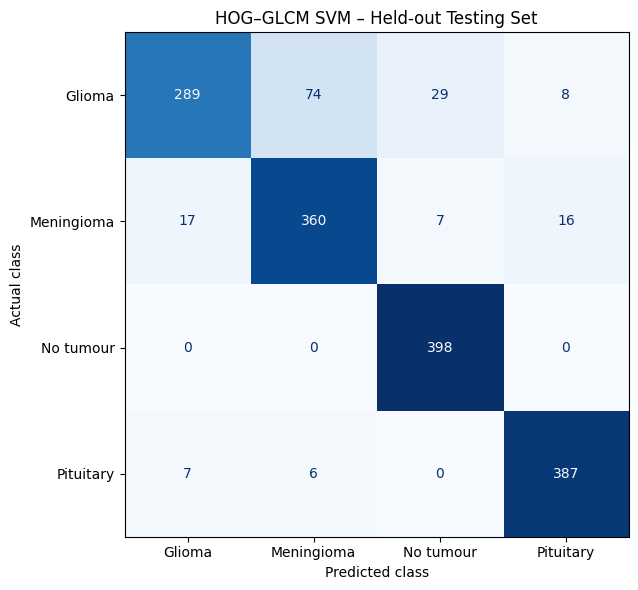

In [1]:
# Create a confusion matrix plot for the final Testing set of the HOG + GLCM + SVM model.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Final held-out Testing confusion matrix for HOG + GLCM + SVM
cm_svm = np.array([
    [289, 74, 29, 8],
    [17, 360, 7, 16],
    [0, 0, 398, 0],
    [7, 6, 0, 387]
])

class_names = [
    "Glioma",
    "Meningioma",
    "No tumour",
    "Pituitary"
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("HOG–GLCM SVM – Held-out Testing Set")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

plt.tight_layout()

plt.savefig(
    "svm_testing_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

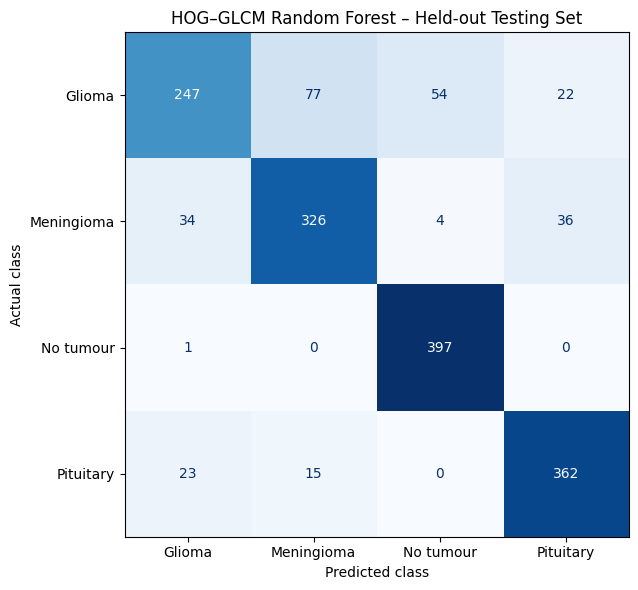

In [ ]:
# Create a confusion matrix plot for the final Testing set of the HOG + GLCM + Random Forest model.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Final held-out Testing confusion matrix for HOG + GLCM + Random Forest
cm_rf = np.array([
    [247, 77, 54, 22],
    [34, 326, 4, 36],
    [1, 0, 397, 0],
    [23, 15, 0, 362]
])

class_names = [
    "Glioma",
    "Meningioma",
    "No tumour",
    "Pituitary"
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("HOG–GLCM Random Forest – Held-out Testing Set")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Actual class")

plt.tight_layout()

plt.savefig(
    "rf_testing_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [2]:
# ============================================================
# HOG+GLCM + SVM: REPEATED-CV TIMING SUMMARY
# ============================================================

from pathlib import Path
import json
import pandas as pd


# ------------------------------------------------------------
# Find the project automatically
# ------------------------------------------------------------

current_directory = Path.cwd()

possible_project_roots = [
    current_directory,
    current_directory.parent,
]

PROJECT_ROOT = next(
    (
        path
        for path in possible_project_roots
        if (
            path
            / "repeated_cv"
            / "classical_svm"
        ).exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project folder containing "
        "'repeated_cv/classical_svm'."
    )


SVM_RESULTS_ROOT = (
    PROJECT_ROOT
    / "repeated_cv"
    / "classical_svm"
)

print("Project root:", PROJECT_ROOT)
print("SVM results:", SVM_RESULTS_ROOT)


# ------------------------------------------------------------
# Read the 50 saved timing files
# ------------------------------------------------------------

timing_rows = []

for repeat_number in range(1, 11):

    for fold_number in range(1, 6):

        metrics_path = (
            SVM_RESULTS_ROOT
            / f"repeat_{repeat_number:02d}"
            / f"fold_{fold_number:02d}"
            / "metrics.json"
        )

        if not metrics_path.exists():
            raise FileNotFoundError(
                f"Missing file: {metrics_path}"
            )

        with metrics_path.open(
            "r",
            encoding="utf-8",
        ) as file:
            metrics = json.load(file)

        search_seconds = metrics[
            "tuning_search_seconds"
        ]

        refit_seconds = metrics[
            "final_refit_seconds"
        ]

        timing_rows.append({
            "repeat": repeat_number,
            "fold": fold_number,
            "search_seconds": search_seconds,
            "refit_seconds": refit_seconds,
            "search_plus_refit_seconds":
                search_seconds + refit_seconds,
        })


timings = pd.DataFrame(timing_rows)


# ------------------------------------------------------------
# Total each five-fold repeat
# ------------------------------------------------------------

repeat_timings = (
    timings
    .groupby(
        "repeat",
        as_index=False,
    )["search_plus_refit_seconds"]
    .sum()
)

repeat_timings["runtime_minutes"] = (
    repeat_timings[
        "search_plus_refit_seconds"
    ] / 60
)

repeat_timings["runtime_hours"] = (
    repeat_timings[
        "search_plus_refit_seconds"
    ] / 3600
)


# ------------------------------------------------------------
# Save and display
# ------------------------------------------------------------

output_path = (
    SVM_RESULTS_ROOT
    / "repeated_cv_timing_summary.csv"
)

repeat_timings.to_csv(
    output_path,
    index=False,
)

display(repeat_timings)

print(
    "\nMean runtime per 5-fold repeat:",
    round(
        repeat_timings[
            "runtime_hours"
        ].mean(),
        3,
    ),
    "hours",
)

print(
    "SD across 10 repeats:",
    round(
        repeat_timings[
            "runtime_hours"
        ].std(ddof=1),
        3,
    ),
    "hours",
)

print(
    "Total runtime across all 50 folds:",
    round(
        timings[
            "search_plus_refit_seconds"
        ].sum() / 3600,
        3,
    ),
    "hours",
)

print("\nSaved to:")
print(output_path)

Project root: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification
SVM results: c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\classical_svm


,repeat,search_plus_refit_seconds,runtime_minutes,runtime_hours
0,1,12702.680208,211.711337,3.528522
1,2,12235.892765,203.931546,3.398859
2,3,12002.369836,200.039497,3.333992
3,4,12670.933930,211.182232,3.519704
4,5,12205.883184,203.431386,3.390523
5,6,12435.748005,207.262467,3.454374
6,7,13059.255962,217.654266,3.627571
7,8,12356.921544,205.948692,3.432478
8,9,11793.850443,196.564174,3.276070
9,10,11775.354070,196.255901,3.270932



Mean runtime per 5-fold repeat: 3.423 hours
SD across 10 repeats: 0.114 hours
Total runtime across all 50 folds: 34.233 hours

Saved to:
c:\Users\kwsta\OneDrive\Desktop\Desetation project\brain-tumour-mri-classification\repeated_cv\classical_svm\repeated_cv_timing_summary.csv
